# Turn Analysis: Left / Right in Maze Traversal

Classifies each node visit in `traversal_df` as **LEFT**, **RIGHT**, **STRAIGHT**, or **UTURN**  
based on the cross product of the incoming and outgoing direction vectors at that node.

**Coordinate convention (y increases downward in screen/image coords):**
- `cross_z > 0` → **RIGHT** turn from the mouse's perspective  
- `cross_z < 0` → **LEFT** turn from the mouse's perspective  

This automatically handles the "upside-down" bottom half of the maze: direction of travel
is captured by `v1 = curr_pos − prev_pos`, so left/right are always relative to the mouse's heading.

In [56]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import pickle
import glob
import re
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from scipy.signal import savgol_filter, medfilt, find_peaks

In [57]:
# ── Cell 2: Session Configuration ────────────────────────────────────────────
#
# DATES options:
#   str  → single session, e.g. "09_09_2025"
#   list → multiple sessions, e.g. ["09_09_2025", "10_09_2025"]
#   None → auto-discover all sessions under OUTPUTS_DIR

DATES = "10_09_2025"

OUTPUTS_DIR = Path("/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs")
GRAPH_PKL   = Path("/var/home/almogmeir/Documents/GitHub/NaviGraph/FullMazeGrid.pkl")

# Resolve date list
_DATE_RE = re.compile(r'^\d{2}_\d{2}_\d{4}$')
if DATES is None:
    date_list = sorted(d.name for d in OUTPUTS_DIR.iterdir() if d.is_dir() and _DATE_RE.match(d.name))
elif isinstance(DATES, str):
    date_list = [DATES]
else:
    date_list = list(DATES)

print(f"Sessions to analyse: {date_list}")

Sessions to analyse: ['10_09_2025']


In [58]:
# ── Cell 3: Load Graph G and node_positions ───────────────────────────────────
with open(GRAPH_PKL, 'rb') as f:
    mapping_data = pickle.load(f)

nodes_dict = mapping_data['mappings']['nodes']
edges_dict = mapping_data['mappings']['edges']

node_positions = {}
for node_id, polygon_list in nodes_dict.items():
    polygon = polygon_list[0] if polygon_list else []
    if polygon and len(polygon) >= 2:
        xs = [p[0] for p in polygon]
        ys = [p[1] for p in polygon]
        node_positions[node_id] = (sum(xs) / len(xs), sum(ys) / len(ys))

G = nx.DiGraph()
G.add_nodes_from(node_positions.keys())
for edge_key in edges_dict:
    parts = edge_key.split('_')
    if len(parts) == 2:
        a, b = parts
        if a in node_positions and b in node_positions:
            G.add_edge(a, b)
            G.add_edge(b, a)

print(f"Graph: {len(G.nodes)} nodes, {len(G.edges)} directed edges")
print(f"Node positions computed for {len(node_positions)} nodes")

Graph: 126 nodes, 250 directed edges
Node positions computed for 126 nodes


In [59]:
# ── Cell 4: Load traversal_df(s) ─────────────────────────────────────────────
dfs = []
for date in date_list:
    path = OUTPUTS_DIR / date / "traversal_df.csv"
    if not path.exists():
        print(f"WARNING: {path} not found, skipping.")
        continue
    df = pd.read_csv(path)
    df["session_date"] = date
    dfs.append(df)
    print(f"  {date}: {len(df)} rows loaded")

traversal_df = pd.concat(dfs, ignore_index=True)

node_visits = (
    traversal_df[traversal_df["location_type"] == "node"]
    .copy()
    .reset_index(drop=True)
)

print(f"\nTotal rows: {len(traversal_df)}  |  Node visits: {len(node_visits)}")

  10_09_2025: 10451 rows loaded

Total rows: 10451  |  Node visits: 6309


In [60]:
# ── Cell 5: Turn Classification ───────────────────────────────────────────────
#
# For each consecutive triple (prev_node → curr_node → next_node) within a trial,
# compute the signed angle between the incoming and outgoing direction vectors
# from the FIXED GRAPH NODE POSITIONS.
#
# This graph_angle_deg is a structural property of the maze (always the same for
# a given triplet).  The actual per-traversal turn angle is computed later in
# Cell 10 from the x/y trajectory in summary_df.
#
# y increases DOWNWARD (screen / image coordinates), so:
#   cross_z > 0  →  RIGHT  (clockwise when viewed from above)
#   cross_z < 0  →  LEFT   (counter-clockwise when viewed from above)
#
# Triples where either hop is not a real graph edge are dropped as
# traversal violations before any classification is done.
#
# prev_end_frame_global / next_start_frame_global are stored here while the
# consecutive indices are available; Cell 10 uses them to bound the trajectory
# window so it never bleeds into an adjacent turn.

def classify_turn(prev_id, curr_id, next_id, node_pos):
    """Return (turn_type, graph_angle_degrees) from fixed node positions."""
    px, py = node_pos[prev_id]
    cx, cy = node_pos[curr_id]
    nx_, ny = node_pos[next_id]

    v1 = np.array([cx - px, cy - py], dtype=float)
    v2 = np.array([nx_ - cx, ny - cy], dtype=float)

    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 < 1e-6 or n2 < 1e-6:
        return "STRAIGHT", 0.0

    v1n, v2n = v1 / n1, v2 / n2
    cross_z         = v1n[0] * v2n[1] - v1n[1] * v2n[0]
    dot             = np.clip(np.dot(v1n, v2n), -1.0, 1.0)
    graph_angle_deg = np.degrees(np.arctan2(cross_z, dot))

    if abs(graph_angle_deg) < 20:
        return "STRAIGHT", graph_angle_deg
    if abs(graph_angle_deg) > 160:
        return "UTURN", graph_angle_deg
    return ("RIGHT" if cross_z > 0 else "LEFT"), graph_angle_deg


turn_records = []
n_violations = 0
group_cols = ["session_date", "trial_idx"]

for (session_date, trial_idx), grp in node_visits.groupby(group_cols, sort=False):
    nodes    = grp["headstage_graph_node"].tolist()
    starts   = grp["start_frame_global"].tolist()
    ends     = grp["end_frame_global"].tolist()
    inferred = grp["is_inferred"].tolist() if "is_inferred" in grp.columns else [False] * len(grp)

    for i in range(1, len(nodes) - 1):
        prev_n, curr_n, next_n = nodes[i - 1], nodes[i], nodes[i + 1]
        if not all(n in node_positions for n in (prev_n, curr_n, next_n)):
            continue
        # Drop traversal violations: skip triples where either hop is not a graph edge
        if not (G.has_edge(prev_n, curr_n) and G.has_edge(curr_n, next_n)):
            n_violations += 1
            continue
        turn_type, graph_angle_deg = classify_turn(prev_n, curr_n, next_n, node_positions)
        turn_records.append({
            "session_date"           : session_date,
            "trial_idx"              : trial_idx,
            "prev_node"              : prev_n,
            "curr_node"              : curr_n,
            "next_node"              : next_n,
            "turn_type"              : turn_type,
            "graph_angle_deg"        : graph_angle_deg,
            "start_frame_global"     : starts[i],
            "end_frame_global"       : ends[i],
            "prev_end_frame_global"  : ends[i - 1],    # end of the previous node visit
            "next_start_frame_global": starts[i + 1],  # start of the next node visit
            "is_inferred"            : inferred[i],
        })

turn_df = pd.DataFrame(turn_records)
print(f"Traversal violations removed : {n_violations}")
print(f"Turn events classified       : {len(turn_df)}")
print(turn_df["turn_type"].value_counts())

Traversal violations removed : 570
Turn events classified       : 4334
turn_type
LEFT        1438
RIGHT       1409
UTURN       1136
STRAIGHT     351
Name: count, dtype: int64


In [61]:
# ── Cell 5b: Add Maze Level to turn_df ───────────────────────────────────────
#
# Node naming convention: first digit after L/R = depth from the root.
#
#   depth 0 → L0 / R0          (root, 2 nodes)
#   depth 1 → L1X              (4 nodes)
#   depth 2 → L2X              (8 nodes)
#   depth 3 → L3X              (16 nodes)
#   depth 4 → L4X / L4XX       (32 nodes — parents of reward-port leaves)
#   depth 5 → L5X / L5XX       (64 nodes — reward ports, out_degree=1)
#
# User-facing maze_level inverts this so level 1 is closest to the leaves:
#   level = MAX_INNER_DEPTH − depth + 1
#   → level 1 = depth 4 (L4X nodes)
#   → level 5 = depth 0 (L0 / R0)
#
# Leaf nodes (depth 5 / out_degree=1) get level=None; PSTH cells ignore them.

_DEPTH_RE    = re.compile(r'^[LR](\d)')

def _node_first_digit(node_id):
    m = _DEPTH_RE.match(str(node_id))
    return int(m.group(1)) if m else None

_leaf_set       = {n for n in G.nodes if G.out_degree(n) == 1}
_inner_depths   = [d for n in G.nodes
                   if n not in _leaf_set and (d := _node_first_digit(n)) is not None]
MAX_INNER_DEPTH = max(_inner_depths)   # 4 for the current maze

def node_maze_level(node_id):
    """Level 1 = parent of reward-port leaves; higher = closer to root."""
    if node_id in _leaf_set:
        return None
    d = _node_first_digit(node_id)
    return (MAX_INNER_DEPTH - d + 1) if d is not None else None

turn_df["curr_node_level"] = turn_df["curr_node"].map(node_maze_level)

print(f"MAX_INNER_DEPTH = {MAX_INNER_DEPTH}  "
      f"(first digit {MAX_INNER_DEPTH} → level 1;  first digit 0 → level {MAX_INNER_DEPTH + 1})")
print()
counts = (turn_df.groupby(["curr_node_level", "turn_type"])
          .size().unstack(fill_value=0))
print("Event counts by level × turn_type:")
print(counts)

MAX_INNER_DEPTH = 4  (first digit 4 → level 1;  first digit 0 → level 5)

Event counts by level × turn_type:
turn_type        LEFT  RIGHT  STRAIGHT  UTURN
curr_node_level                              
1.0               476    462        41    360
2.0               468    476         3      4
3.0               398    408        14      0
4.0                70     53       272      0
5.0                26     10        21      0


In [62]:
# ── Cell 6: Summary Statistics ────────────────────────────────────────────────
print("=== Turn counts by type ===")
counts = turn_df["turn_type"].value_counts()
for t, c in counts.items():
    print(f"  {t:8s}: {c:5d}  ({100*c/len(turn_df):.1f}%)")

if len(date_list) > 1:
    print("\n=== By session ===")
    print(turn_df.groupby(["session_date", "turn_type"]).size().unstack(fill_value=0))

print("\n=== Graph angle distribution (structural, fixed per triplet) ===")
for t in ["LEFT", "RIGHT", "STRAIGHT", "UTURN"]:
    sub = turn_df[turn_df["turn_type"] == t]["graph_angle_deg"]
    if len(sub):
        print(f"  {t:8s}: mean={sub.mean():+.1f}  std={sub.std():.1f}  "
              f"[{sub.min():+.1f}, {sub.max():+.1f}]")

# trajectory_angle_deg is added after Cell 10 runs
if "trajectory_angle_deg" in turn_df.columns:
    print("\n=== Trajectory angle distribution (actual per-traversal movement) ===")
    for t in ["LEFT", "RIGHT", "STRAIGHT", "UTURN"]:
        sub = turn_df[turn_df["turn_type"] == t]["trajectory_angle_deg"].dropna()
        if len(sub):
            print(f"  {t:8s}: mean={sub.mean():+.1f}  std={sub.std():.1f}  "
                  f"[{sub.min():+.1f}, {sub.max():+.1f}]")

=== Turn counts by type ===
  LEFT    :  1438  (33.2%)
  RIGHT   :  1409  (32.5%)
  UTURN   :  1136  (26.2%)
  STRAIGHT:   351  (8.1%)

=== Graph angle distribution (structural, fixed per triplet) ===
  LEFT    : mean=-90.0  std=0.0  [-90.0, -90.0]
  RIGHT   : mean=+90.0  std=0.0  [+90.0, +90.0]
  STRAIGHT: mean=+0.0  std=0.0  [+0.0, +0.0]
  UTURN   : mean=+4.8  std=180.0  [-180.0, +180.0]


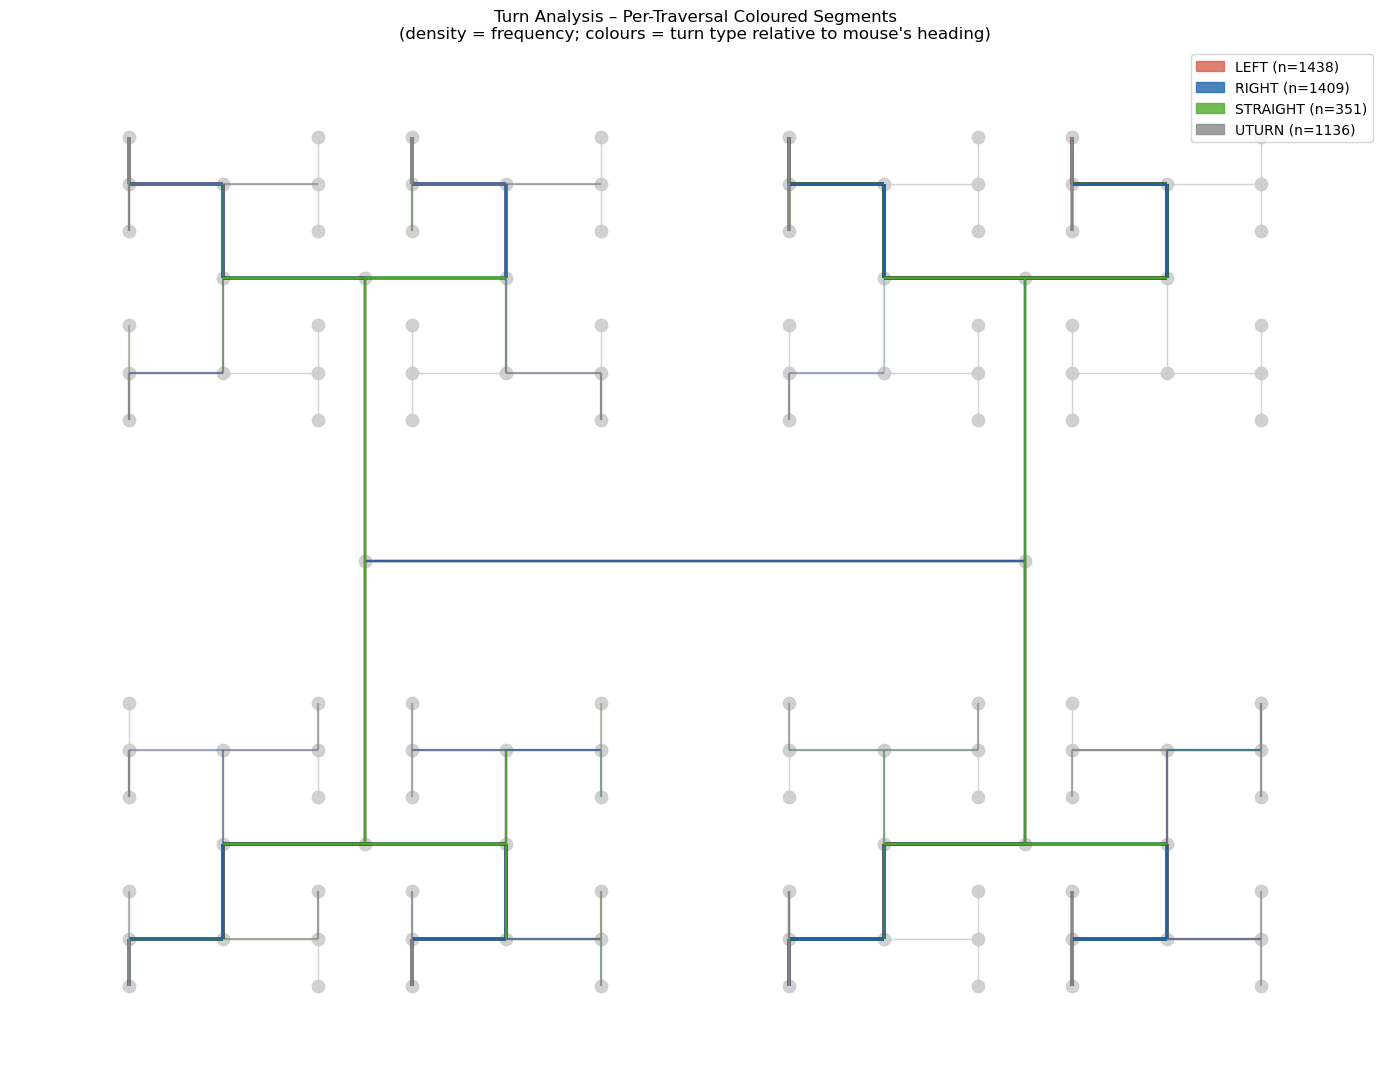

In [63]:
# ── Cell 7: Graph Visualisation – Per-Traversal Coloured Segments ─────────────
#
# For every turn event, two segments are drawn:
#   • incoming edge:  prev_node → curr_node
#   • outgoing edge:  curr_node → next_node
# Both coloured by turn type.  Low alpha (0.20) lets overlapping traversals
# accumulate into a density heat-map.

TURN_COLORS = {
    "LEFT"    : "#d6604d",   # red
    "RIGHT"   : "#2166ac",   # blue
    "STRAIGHT": "#4dac26",   # green
    "UTURN"   : "#888888",   # gray
}
ALPHA = 0.20
LW    = 1.5

fig, ax = plt.subplots(figsize=(14, 14))

# Base skeleton
nx.draw_networkx_edges(G, node_positions, ax=ax,
                       alpha=0.12, edge_color="#444444",
                       arrows=False, width=1.0)
nx.draw_networkx_nodes(G, node_positions, ax=ax,
                       node_size=80, node_color="#cccccc", alpha=0.9)

# Per-traversal segments, grouped by turn type for efficient rendering
for turn_type, color in TURN_COLORS.items():
    sub = turn_df[turn_df["turn_type"] == turn_type]
    if sub.empty:
        continue

    segs = []
    for _, row in sub.iterrows():
        p_prev = node_positions.get(row["prev_node"])
        p_curr = node_positions.get(row["curr_node"])
        p_next = node_positions.get(row["next_node"])
        if p_prev and p_curr:
            segs.append([p_prev, p_curr])
        if p_curr and p_next:
            segs.append([p_curr, p_next])

    lc = LineCollection(segs, colors=color, alpha=ALPHA, linewidths=LW, label=turn_type)
    ax.add_collection(lc)

# Node labels (only reward-port leaf nodes)
leaf_nodes = [n for n in G.nodes if G.degree(n) == 1]
leaf_labels = {n: n for n in leaf_nodes}
nx.draw_networkx_labels(G, node_positions, labels=leaf_labels,
                        ax=ax, font_size=7, font_color="black")

legend_patches = [
    mpatches.Patch(color=c, label=f"{t} (n={len(turn_df[turn_df['turn_type']==t])})",
                   alpha=min(ALPHA * 4, 1.0))
    for t, c in TURN_COLORS.items()
]
ax.legend(handles=legend_patches, loc="upper right", fontsize=10)

ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Turn Analysis – Per-Traversal Coloured Segments\n"
             "(density = frequency; colours = turn type relative to mouse's heading)",
             fontsize=12)
plt.tight_layout()
plt.show()

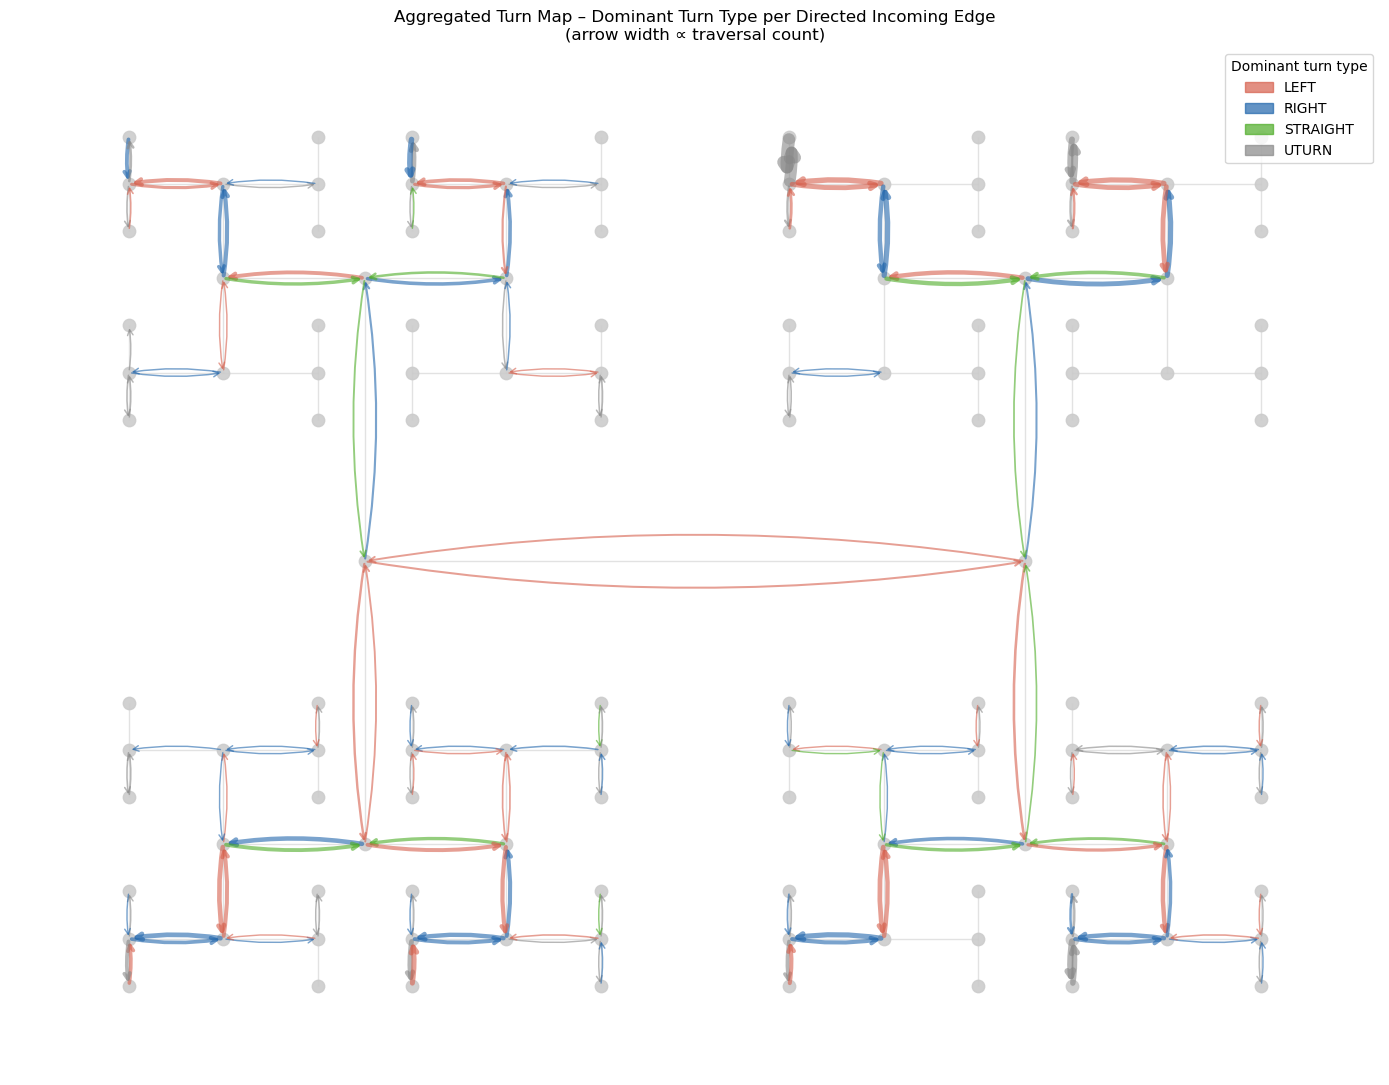

In [64]:
# ── Cell 8: Aggregated Edge Coloring ─────────────────────────────────────────
#
# For each directed edge (prev_node → curr_node), colour it by the dominant
# turn type and scale line width by total traversal count.

from collections import Counter

edge_turn_counts = {}  # (prev, curr) → Counter({turn_type: count})
for _, row in turn_df.iterrows():
    key = (row["prev_node"], row["curr_node"])
    if key not in edge_turn_counts:
        edge_turn_counts[key] = Counter()
    edge_turn_counts[key][row["turn_type"]] += 1

max_count = max(sum(c.values()) for c in edge_turn_counts.values()) if edge_turn_counts else 1

fig, ax = plt.subplots(figsize=(14, 14))

# Base skeleton
nx.draw_networkx_edges(G, node_positions, ax=ax,
                       alpha=0.08, edge_color="#444444",
                       arrows=False, width=1.0)
nx.draw_networkx_nodes(G, node_positions, ax=ax,
                       node_size=80, node_color="#cccccc", alpha=0.9)

# Draw each edge coloured by dominant turn type, width ∝ count
for (prev_n, curr_n), counter in edge_turn_counts.items():
    if prev_n not in node_positions or curr_n not in node_positions:
        continue
    dominant = counter.most_common(1)[0][0]
    total    = sum(counter.values())
    color    = TURN_COLORS[dominant]
    lw       = 1.0 + 8.0 * (total / max_count)
    p1, p2   = node_positions[prev_n], node_positions[curr_n]
    ax.annotate("", xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle="->", color=color,
                                lw=lw, alpha=0.6,
                                connectionstyle="arc3,rad=0.08"))

leaf_labels = {n: n for n in G.nodes if G.degree(n) == 1}
nx.draw_networkx_labels(G, node_positions, labels=leaf_labels,
                        ax=ax, font_size=7)

legend_patches = [mpatches.Patch(color=c, label=t, alpha=0.7)
                  for t, c in TURN_COLORS.items()]
ax.legend(handles=legend_patches, loc="upper right", fontsize=10,
          title="Dominant turn type")

ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Aggregated Turn Map – Dominant Turn Type per Directed Incoming Edge\n"
             "(arrow width ∝ traversal count)", fontsize=12)
plt.tight_layout()
plt.show()

In [65]:
# ── Cell 9: Load summary_df (frame-by-frame trajectory) ──────────────────────
#
# summary_df is a MultiIndex DataFrame.  Position columns:
#   ('headstage', 'x')  and  ('headstage', 'y')
# Frame index column:
#   ('frame_idx_global', '')

summary_dfs = []
for date in date_list:
    pkl_path = OUTPUTS_DIR / date / "summary_df.pkl"
    if not pkl_path.exists():
        print(f"WARNING: {pkl_path} not found, skipping.")
        continue
    df = pd.read_pickle(pkl_path)
    df["_session_date"] = date
    summary_dfs.append(df)
    print(f"  {date}: summary_df shape {df.shape}")

summary_df = pd.concat(summary_dfs, ignore_index=True)

# Normalise column access regardless of MultiIndex depth
X_COL     = ("headstage", "x")
Y_COL     = ("headstage", "y")
FRAME_COL = ("frame_idx_global", "")
DATE_COL  = "_session_date"

# Verify columns exist
for col in [X_COL, Y_COL, FRAME_COL]:
    if col not in summary_df.columns:
        raise KeyError(f"Expected column {col!r} not found.  "
                       f"Available: {summary_df.columns[:10].tolist()}")

print(f"\nsummary_df loaded: {len(summary_df)} rows")

  10_09_2025: summary_df shape (144686, 32)

summary_df loaded: 144686 rows


In [66]:
# ── Cell 10: Refined Turn Timing + Angular Velocity Analysis ─────────────────
#
# Stage A — Denoise (unchanged)
#   Median filter → Savitzky-Golay.
#
# Stage B — Angular velocity  |ω(t)| = |dθ/dt|  (replaces curvature κ)
#   Using the 1st derivative of the unwrapped heading angle rather than the
#   2nd derivative of position avoids the SG edge-distortion artifacts that
#   caused false curvature peaks at the start/end of the window.
#
# Stage C — 50% cumulative heading-change midpoint (unchanged)
#   Robust for both shallow and sharp turns; used as refined_turn_frame_global.
#
# Stage D — Turn concentration  (NEW — primary quality signal)
#   What fraction of the total |ω| in the *safe zone* (window excluding the
#   first/last EDGE_GUARD frames) falls within ±CONC_WIN frames of the
#   refined frame?
#     • High concentration → angular activity is peaked near the turn frame
#       → timing estimate is trustworthy.
#     • Low concentration → angular activity is spread or mostly outside
#       the turn region → noisy or ill-defined turn.
#
#   ω peak count near the refined frame is also stored but used only for
#   diagnostics, not in the confidence formula.
#
# Stage E — Trajectory angle at midpoint (unchanged)
#
# New columns added to turn_df:
#   n_omega_peaks      — |ω| peaks in safe-zone near refined frame (diagnostic)
#   turn_concentration — fraction of safe-zone |ω| within ±CONC_WIN of frame
#   delta_theta_deg    — total heading change in node-visit window (magnitude)
#   tracking_noise_px  — RMS(raw − smooth) in pixels

BUFFER          = 30     # max buffer beyond node-visit window
SG_WINDOW       = 7
SG_POLY         = 3
MED_WINDOW      = 5
ANGLE_WIN       = 5      # frames each side of midpoint for traj-angle vectors
EDGE_GUARD      = 5      # exclude first/last N frames of buffer (SG edge artefacts)
CONC_WIN        = 8      # ±frames around refined frame for concentration
OMEGA_MIN_PROM  = 0.20   # min prominence fraction for |ω| peak detection
OMEGA_MIN_DIST  = 3      # min frame gap between |ω| peaks


def refine_turn(frame_start, frame_end, lo, hi, sub_summary,
                x_col, y_col, frame_col, angle_win=ANGLE_WIN):
    """
    Returns (refined_frame, traj_angle_deg,
             n_omega_peaks, turn_concentration, delta_theta_deg, tracking_noise_px)
    or (None,)*6 when insufficient data.
    """
    seg = sub_summary[
        (sub_summary[frame_col] >= lo) & (sub_summary[frame_col] <= hi)
    ].sort_values(frame_col)

    x      = seg[x_col].values.astype(float)
    y      = seg[y_col].values.astype(float)
    frames = seg[frame_col].values

    if len(x) < SG_WINDOW or np.any(np.isnan(x)) or np.any(np.isnan(y)):
        return (None,) * 6

    # ── Stage A: denoise ─────────────────────────────────────────────────────
    med_win = min(MED_WINDOW, len(x))
    if med_win % 2 == 0:
        med_win -= 1
    med_win = max(med_win, 3)
    x_s = savgol_filter(medfilt(x, kernel_size=med_win), SG_WINDOW, SG_POLY)
    y_s = savgol_filter(medfilt(y, kernel_size=med_win), SG_WINDOW, SG_POLY)

    tracking_noise_px = float(np.mean(np.sqrt((x - x_s)**2 + (y - y_s)**2)))

    # ── Stage B: angular velocity |ω| ────────────────────────────────────────
    dx              = np.gradient(x_s)
    dy              = np.gradient(y_s)
    theta_unwrapped = np.unwrap(np.arctan2(dy, dx))
    omega_abs       = np.abs(np.gradient(theta_unwrapped))   # rad / frame, always ≥ 0

    # ── Inner window ─────────────────────────────────────────────────────────
    inner = (frames >= frame_start) & (frames <= frame_end)
    if not inner.any():
        inner = np.ones(len(frames), dtype=bool)
    inner_idx = np.where(inner)[0]
    if len(inner_idx) < 2:
        return (None,) * 6

    # ── Stage C: 50% heading-change midpoint ─────────────────────────────────
    delta_theta     = theta_unwrapped[inner_idx[-1]] - theta_unwrapped[inner_idx[0]]
    delta_theta_deg = float(np.degrees(np.abs(delta_theta)))

    if abs(delta_theta) < np.deg2rad(5):
        peak_idx = inner_idx[len(inner_idx) // 2]
    else:
        target   = theta_unwrapped[inner_idx[0]] + 0.5 * delta_theta
        diffs    = np.abs(theta_unwrapped[inner_idx] - target)
        peak_idx = inner_idx[int(np.argmin(diffs))]

    # ── Stage D: concentration of |ω| near the refined frame ─────────────────
    # Safe zone: exclude first/last EDGE_GUARD frames to avoid SG artifacts.
    eg = min(EDGE_GUARD, len(frames) // 5)
    safe = np.zeros(len(frames), dtype=bool)
    safe[eg: len(frames) - eg] = True

    # Near zone: ±CONC_WIN frames around refined frame.
    near = np.zeros(len(frames), dtype=bool)
    near[max(0, peak_idx - CONC_WIN): min(len(frames), peak_idx + CONC_WIN + 1)] = True

    total_omega = omega_abs[safe].sum() + 1e-8
    concentration = float(omega_abs[safe & near].sum() / total_omega)

    # |ω| peaks in the safe & near zone (diagnostic only)
    ns_idx = np.where(safe & near)[0]
    n_omega_peaks = 0
    if len(ns_idx) >= 3:
        om_ns = omega_abs[ns_idx]
        rng   = om_ns.max() - om_ns.min()
        if rng > 1e-8:
            pks, _ = find_peaks(om_ns,
                                prominence=OMEGA_MIN_PROM * rng,
                                distance=OMEGA_MIN_DIST)
            n_omega_peaks = int(len(pks))

    # ── Stage E: trajectory angle at midpoint ─────────────────────────────────
    before_idx = max(0, peak_idx - angle_win)
    after_idx  = min(len(x_s) - 1, peak_idx + angle_win)
    v1 = np.array([x_s[peak_idx] - x_s[before_idx],
                   y_s[peak_idx] - y_s[before_idx]], dtype=float)
    v2 = np.array([x_s[after_idx] - x_s[peak_idx],
                   y_s[after_idx] - y_s[peak_idx]], dtype=float)
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 > 1e-6 and n2 > 1e-6:
        v1n, v2n = v1 / n1, v2 / n2
        cross_z    = v1n[0] * v2n[1] - v1n[1] * v2n[0]
        dot        = np.clip(np.dot(v1n, v2n), -1.0, 1.0)
        traj_angle = float(np.degrees(np.arctan2(cross_z, dot)))
    else:
        traj_angle = None

    return (int(frames[peak_idx]), traj_angle,
            n_omega_peaks, concentration, delta_theta_deg, tracking_noise_px)


# ── Calling loop ─────────────────────────────────────────────────────────────
_summary_by_date = {
    date: summary_df[summary_df[DATE_COL] == date]
    for date in date_list
}

refined_frames = []
traj_angles    = []
n_omega_list   = []
conc_list      = []
delta_list     = []
noise_list     = []

for _, row in turn_df.iterrows():
    if row.get("is_inferred", False):
        refined_frames.append(None); traj_angles.append(None)
        n_omega_list.append(None);   conc_list.append(None)
        delta_list.append(None);     noise_list.append(None)
        continue
    sub = _summary_by_date.get(row["session_date"], pd.DataFrame())
    if sub.empty:
        refined_frames.append(None); traj_angles.append(None)
        n_omega_list.append(None);   conc_list.append(None)
        delta_list.append(None);     noise_list.append(None)
        continue

    frame_start = int(row["start_frame_global"])
    frame_end   = int(row["end_frame_global"])
    lo = max(frame_start - BUFFER, int(row["prev_end_frame_global"]))
    hi = min(frame_end   + BUFFER, int(row["next_start_frame_global"]))

    rf, ta, nop, conc, delta, noise = refine_turn(
        frame_start, frame_end, lo, hi,
        sub, X_COL, Y_COL, FRAME_COL,
    )
    refined_frames.append(rf);  traj_angles.append(ta)
    n_omega_list.append(nop);   conc_list.append(conc)
    delta_list.append(delta);   noise_list.append(noise)

turn_df["refined_turn_frame_global"] = refined_frames
turn_df["trajectory_angle_deg"]      = traj_angles
turn_df["n_omega_peaks"]             = n_omega_list
turn_df["turn_concentration"]        = conc_list
turn_df["delta_theta_deg"]           = delta_list
turn_df["tracking_noise_px"]         = noise_list

n_refined = turn_df["refined_turn_frame_global"].notna().sum()
print(f"Refined timing: {n_refined} / {len(turn_df)} turns")

v = turn_df[turn_df["turn_concentration"].notna()]
print(f"\nConcentration stats (n={len(v)}):")
for tt in ["LEFT", "RIGHT", "STRAIGHT", "UTURN"]:
    s = v[v["turn_type"] == tt]["turn_concentration"]
    if len(s):
        print(f"  {tt:8s}: mean={s.mean():.3f}  std={s.std():.3f}  "
              f"median={s.median():.3f}")

Refined timing: 2706 / 4334 turns

Concentration stats (n=2706):
  LEFT    : mean=0.847  std=0.208  median=0.939
  RIGHT   : mean=0.870  std=0.207  median=0.974
  STRAIGHT: mean=0.743  std=0.289  median=0.847
  UTURN   : mean=0.695  std=0.314  median=0.778


In [67]:
# ── Cell 10b: Turn Confidence Score ──────────────────────────────────────────
#
# Confidence = magnitude_score × concentration_score × noise_score
#
#   magnitude_score = min(delta_theta_deg / 45°, 1.0)
#     The larger the actual heading change, the more trustworthy the timing
#     estimate.  Turns < 5° are already excluded by the 50%-midpoint logic;
#     at 45° the score saturates at 1.
#
#   concentration_score = turn_concentration
#     Fraction of total |ω| in the safe zone that falls within ±CONC_WIN
#     frames of the refined turn frame.
#     • Clean turn (mouse straight → corner → straight):
#       all angular activity is near the turn frame  → score close to 1
#     • Noisy tracking (ω oscillating throughout the buffer):
#       activity spread across the window → score ≈ (2·CONC_WIN) / safe_width
#       e.g.  16 / 50 ≈ 0.32  for a 60-frame buffer
#     This single metric captures both "edge-noise peaks" (activity outside
#     the near zone) and "multiple adjacent peaks" (activity spread, not
#     concentrated) without relying on brittle peak counting.
#
#   noise_score = 1 / (1 + tracking_noise_px / NOISE_SCALE_PX)
#     Penalises raw DLC jitter vs the smoothed path.
#
# n_omega_peaks is stored in turn_df for diagnostic use (Cell 12b) but is
# NOT included in the confidence formula.

MIN_CONFIDENCE  = 0.15    # tune after inspecting Cell 12b distributions
NOISE_SCALE_PX  = 10.0    # px: noise at this level → noise_score = 0.5

def _compute_confidence(row):
    if pd.isna(row.get("refined_turn_frame_global")):
        return 0.0
    conc  = row.get("turn_concentration")
    delta = row.get("delta_theta_deg")
    noise = row.get("tracking_noise_px")
    if any(pd.isna(v) for v in [conc, delta, noise]):
        return 0.0
    magnitude_score    = min(float(delta) / 45.0, 1.0)
    concentration_score = float(conc)
    noise_score         = 1.0 / (1.0 + float(noise) / NOISE_SCALE_PX)
    return round(magnitude_score * concentration_score * noise_score, 4)

turn_df["turn_confidence"] = turn_df.apply(_compute_confidence, axis=1)

print(f"=== Confidence distribution (MIN_CONFIDENCE = {MIN_CONFIDENCE}) ===")
for tt in ["LEFT", "RIGHT", "STRAIGHT", "UTURN"]:
    sub = turn_df[turn_df["turn_type"] == tt]
    if sub.empty:
        continue
    n_pass = (sub["turn_confidence"] >= MIN_CONFIDENCE).sum()
    print(f"  {tt:8s}: {len(sub):4d} total → {n_pass:4d} pass  "
          f"({100*n_pass/len(sub):.0f}%)")

lr     = turn_df[turn_df["turn_type"].isin(["LEFT", "RIGHT"])]
n_pass = (lr["turn_confidence"] >= MIN_CONFIDENCE).sum()
print(f"\nLEFT+RIGHT passing: {n_pass} / {len(lr)}  "
      f"({100*n_pass/len(lr):.1f}%)")

=== Confidence distribution (MIN_CONFIDENCE = 0.15) ===
  LEFT    : 1438 total →  726 pass  (50%)
  RIGHT   : 1409 total →  792 pass  (56%)
  STRAIGHT:  351 total →  149 pass  (42%)
  UTURN   : 1136 total →  551 pass  (49%)

LEFT+RIGHT passing: 1518 / 2847  (53.3%)


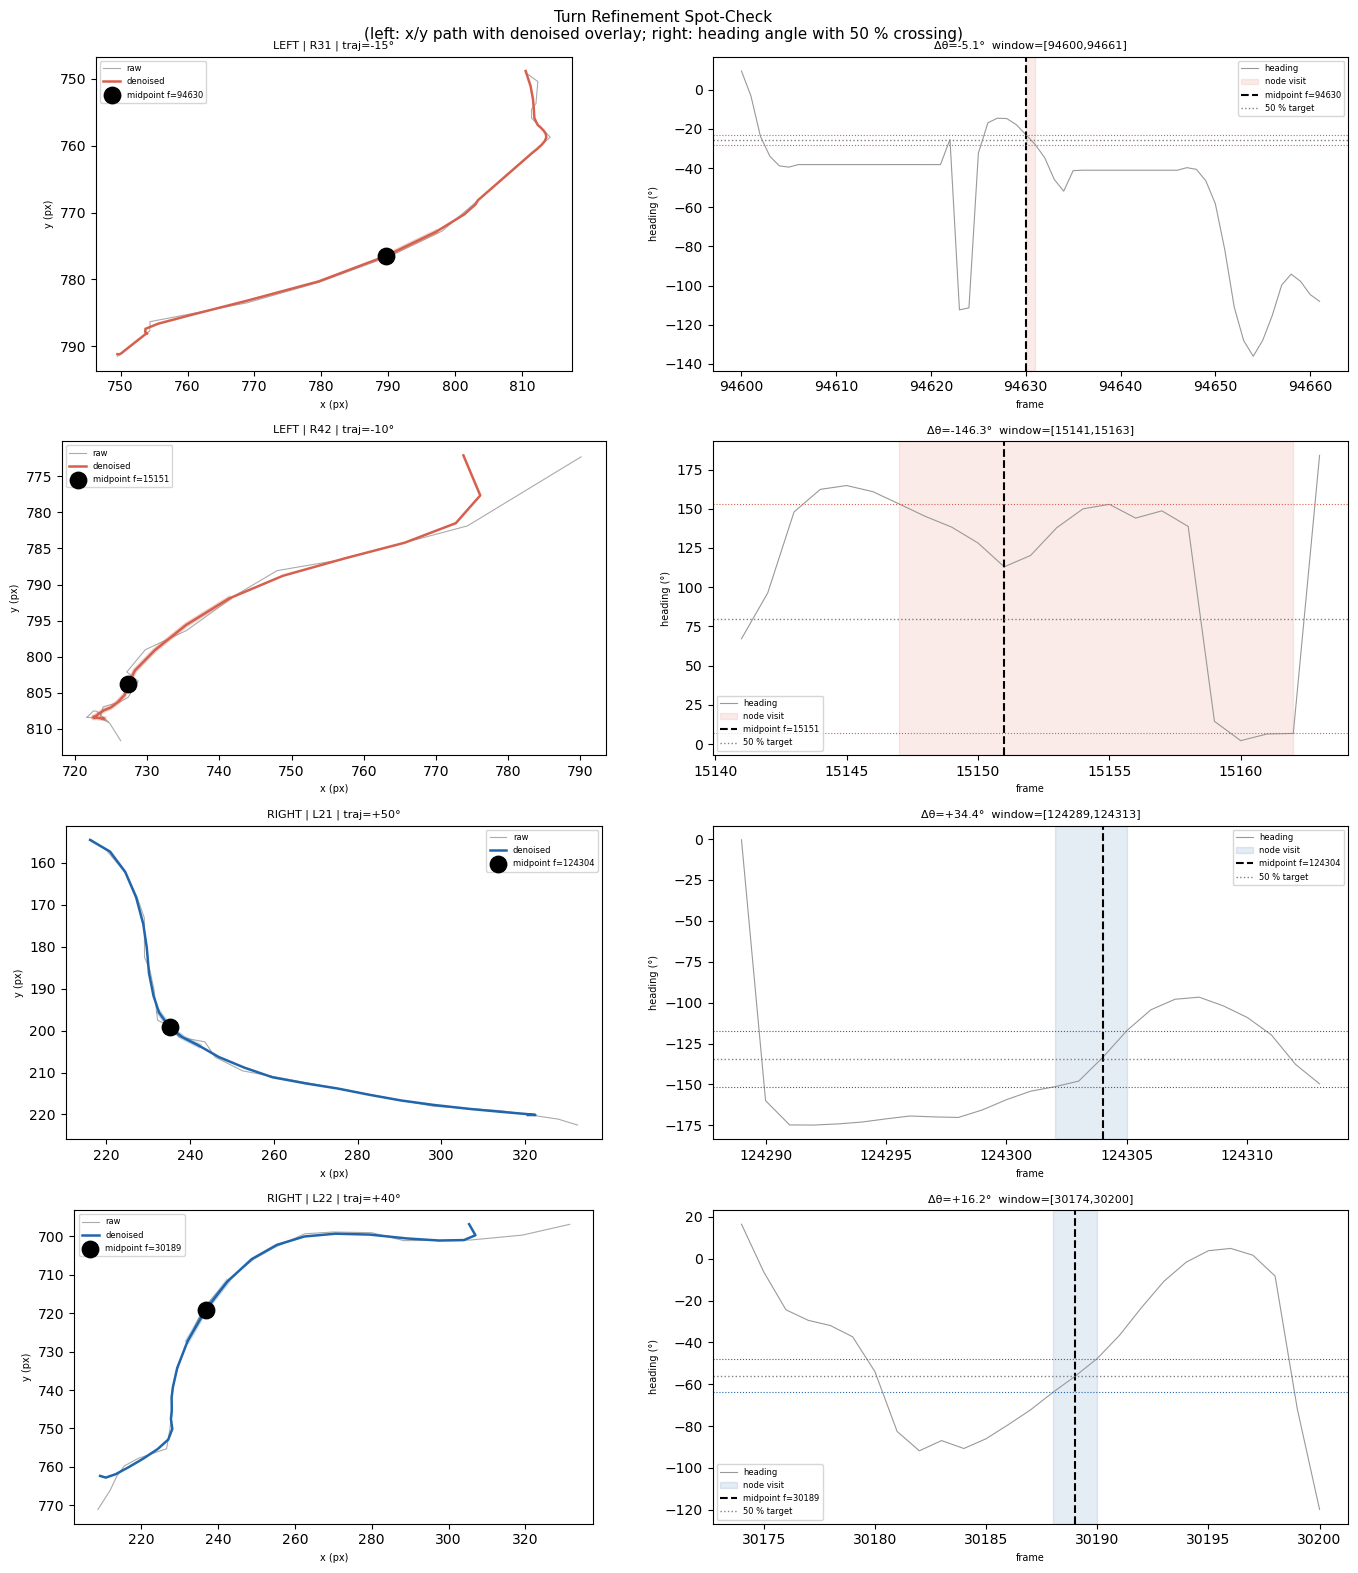

In [68]:
# ── Cell 11: Verification – Spot-Check Turn Refinement ───────────────────────
#
# For each sampled turn, two panels are shown side by side:
#   LEFT  — x/y trajectory with refined turn frame marked
#   RIGHT — unwrapped heading angle over time, showing the 50 % crossing

N_CHECKS   = 4
CHECK_TYPES = ["LEFT", "RIGHT"]

sample = (
    turn_df[
        turn_df["turn_type"].isin(CHECK_TYPES) &
        turn_df["refined_turn_frame_global"].notna()
    ]
    .sample(min(N_CHECKS, len(turn_df)), random_state=42)
)

fig, axes = plt.subplots(N_CHECKS, 2, figsize=(14, 4 * N_CHECKS))

for row_i, (_, row) in enumerate(sample.iterrows()):
    ax_xy = axes[row_i, 0]
    ax_hd = axes[row_i, 1]

    sub = _summary_by_date.get(row["session_date"], pd.DataFrame())
    frame_start = int(row["start_frame_global"])
    frame_end   = int(row["end_frame_global"])
    lo = max(frame_start - BUFFER, int(row["prev_end_frame_global"]))
    hi = min(frame_end   + BUFFER, int(row["next_start_frame_global"]))

    seg = sub[(sub[FRAME_COL] >= lo) & (sub[FRAME_COL] <= hi)].sort_values(FRAME_COL)
    x_raw  = seg[X_COL].values.astype(float)
    y_raw  = seg[Y_COL].values.astype(float)
    frames = seg[FRAME_COL].values

    if len(x_raw) < SG_WINDOW:
        ax_xy.set_title("Too few points")
        ax_hd.axis("off")
        continue

    med_win = min(MED_WINDOW, len(x_raw))
    if med_win % 2 == 0:
        med_win -= 1
    med_win = max(med_win, 3)

    x_s = savgol_filter(medfilt(x_raw, med_win), SG_WINDOW, SG_POLY)
    y_s = savgol_filter(medfilt(y_raw, med_win), SG_WINDOW, SG_POLY)
    dx  = np.gradient(x_s)
    dy  = np.gradient(y_s)
    theta_u = np.unwrap(np.arctan2(dy, dx))

    inner     = (frames >= frame_start) & (frames <= frame_end)
    inner_idx = np.where(inner)[0]
    delta_theta  = theta_u[inner_idx[-1]] - theta_u[inner_idx[0]] if len(inner_idx) >= 2 else 0
    target_theta = theta_u[inner_idx[0]] + 0.5 * delta_theta if abs(delta_theta) >= np.deg2rad(5) else None

    rf      = int(row["refined_turn_frame_global"])
    rf_mask = frames == rf
    color   = TURN_COLORS[row["turn_type"]]

    # ── x/y panel ────────────────────────────────────────────────────────────
    visit_mask = (frames >= frame_start) & (frames <= frame_end)

    ax_xy.plot(x_raw, y_raw, color="#aaaaaa", lw=0.8, label="raw")
    ax_xy.plot(x_s, y_s, color=color, lw=1.8, label="denoised")
    if visit_mask.any():
        ax_xy.plot(x_s[visit_mask], y_s[visit_mask], color=color, lw=3.5, alpha=0.3)
    if rf_mask.any():
        ax_xy.scatter(x_s[rf_mask], y_s[rf_mask], s=140, zorder=5, color="black",
                      label=f"midpoint f={rf}")
    traj_str = f"{row['trajectory_angle_deg']:+.0f}°" if pd.notna(row.get("trajectory_angle_deg")) else "N/A"
    ax_xy.set_title(f"{row['turn_type']} | {row['curr_node']} | traj={traj_str}", fontsize=8)
    ax_xy.set_xlabel("x (px)", fontsize=7)
    ax_xy.set_ylabel("y (px)", fontsize=7)
    ax_xy.legend(fontsize=6)
    ax_xy.set_aspect("equal")
    ax_xy.invert_yaxis()

    # ── heading-angle panel ───────────────────────────────────────────────────
    ax_hd.plot(frames, np.degrees(theta_u), color="#999999", lw=0.8, label="heading")
    ax_hd.axvspan(frame_start, frame_end, alpha=0.12, color=color, label="node visit")
    ax_hd.axvline(rf, color="black", lw=1.5, ls="--", label=f"midpoint f={rf}")
    if target_theta is not None:
        ax_hd.axhline(np.degrees(target_theta), color="gray", lw=1, ls=":", label="50 % target")
        ax_hd.axhline(np.degrees(theta_u[inner_idx[0]]),  color=color, lw=0.8, ls=":")
        ax_hd.axhline(np.degrees(theta_u[inner_idx[-1]]), color=color, lw=0.8, ls=":")
    ax_hd.set_xlabel("frame", fontsize=7)
    ax_hd.set_ylabel("heading (°)", fontsize=7)
    ax_hd.set_title(f"Δθ={np.degrees(delta_theta):+.1f}°  window=[{lo},{hi}]", fontsize=8)
    ax_hd.legend(fontsize=6)

fig.suptitle("Turn Refinement Spot-Check\n"
             "(left: x/y path with denoised overlay; right: heading angle with 50 % crossing)",
             fontsize=11)
plt.tight_layout()
plt.show()

In [69]:
# ── Cell 12: Export turn_df ───────────────────────────────────────────────────
#
# turn_df is ready for downstream PSTH analysis.
# Key columns:
#   turn_type               — LEFT / RIGHT / STRAIGHT / UTURN
#   angle_deg               — signed angle (deg) between incoming & outgoing vectors
#   start/end_frame_global  — coarse node-visit window
#   refined_turn_frame_global — peak-curvature frame for precise event alignment

if len(date_list) == 1:
    out_dir  = OUTPUTS_DIR / date_list[0]
    out_path = out_dir / "turn_df.csv"
else:
    out_dir  = OUTPUTS_DIR
    out_path = out_dir / "turn_df_all_sessions.csv"

turn_df.to_csv(out_path, index=False)
print(f"Saved turn_df ({len(turn_df)} rows) → {out_path}")
turn_df.head()

Saved turn_df (4334 rows) → /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/turn_df.csv


,session_date,trial_idx,prev_node,curr_node,next_node,turn_type,graph_angle_deg,start_frame_global,end_frame_global,prev_end_frame_global,next_start_frame_global,is_inferred,curr_node_level,refined_turn_frame_global,trajectory_angle_deg,n_omega_peaks,turn_concentration,delta_theta_deg,tracking_noise_px,turn_confidence
0,10_09_2025,0,L31,L20,L30,STRAIGHT,0.0,14,14,12,16,True,3.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,10_09_2025,0,L20,L30,L40,RIGHT,90.0,16,16,14,18,True,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,10_09_2025,0,L30,L40,L50,RIGHT,90.0,18,18,16,19,True,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,10_09_2025,0,L40,L50,L40,UTURN,180.0,19,20,18,21,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,10_09_2025,0,L50,L40,L30,LEFT,-90.0,21,21,20,23,False,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0


## Turn Timing Quality Analysis

Distribution of curvature-peak counts and tracking noise across all classified turns.
Turns with exactly **1 curvature peak** have the cleanest, most unambiguous timing estimate.
Multiple peaks indicate noise or a composite trajectory; 0 peaks indicate no detectable inflection.

=== n_omega_peaks near refined frame (diagnostic) ===
 n_ω_peaks   total    %all    LEFT   RIGHT
         0     252    9.3%      73      97
         1    1486   54.9%     551     554
         2     752   27.8%     219     233
         3     203    7.5%      36      27
        ≥4      13    0.5%       2       2

Mean concentration : 0.859  (std 0.208)
Mean delta_theta   : 47.3°  (std 59.9°)
Mean tracking noise: 2.04 px  (std 2.49 px)


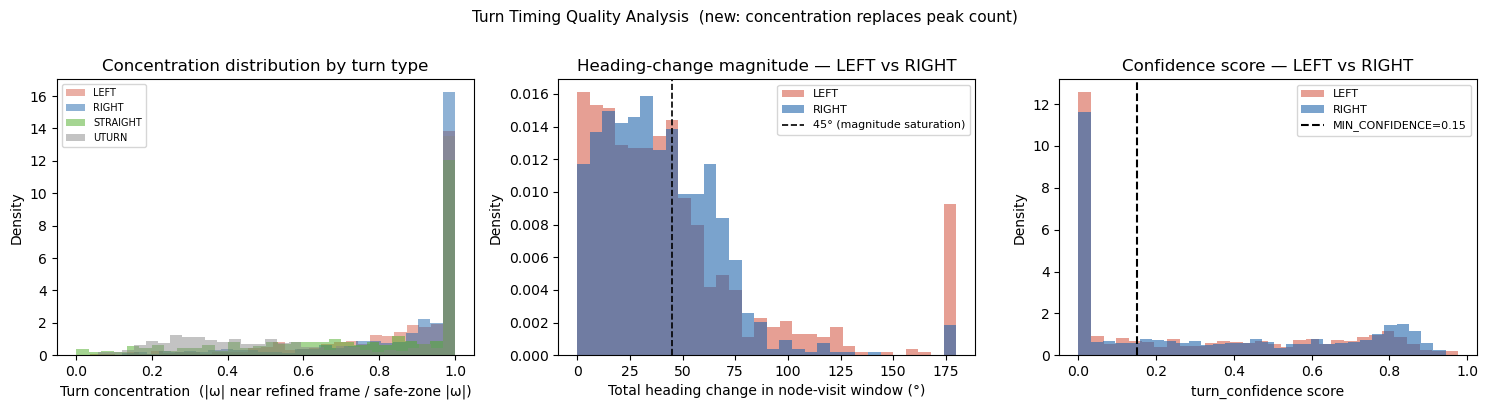


=== Per maze level (LEFT + RIGHT only) ===
 Level       n    conc    Δθ(°)   noise(px)    conf   pass%
     1     826   0.836     55.5        2.49   0.488   84.3%
     2     265   0.870     30.8        1.47   0.381   72.8%
     3     582   0.912     38.3        1.82   0.548   89.3%
     4      88   0.721     73.9        1.20   0.479   89.8%
     5      33   0.747     60.0        1.51   0.531   90.9%


In [70]:
# ── Cell 12b: Turn Timing Quality Analysis ───────────────────────────────────
#
# Three panels:
#   1. Turn concentration distribution (LEFT vs RIGHT) — primary quality signal
#   2. Total heading change delta_theta_deg (LEFT vs RIGHT)
#   3. turn_confidence score with MIN_CONFIDENCE threshold line
#
# Followed by a per-maze-level summary table.

MAX_OMEGA_DISPLAY = 4   # clip n_omega_peaks ≥ this for bar chart

valid = turn_df[turn_df["turn_concentration"].notna()].copy()

print("=== n_omega_peaks near refined frame (diagnostic) ===")
valid["nop_clip"] = valid["n_omega_peaks"].clip(upper=MAX_OMEGA_DISPLAY).astype(int)
print(f"{'n_ω_peaks':>10}  {'total':>6}  {'%all':>6}  {'LEFT':>6}  {'RIGHT':>6}")
for k in range(MAX_OMEGA_DISPLAY + 1):
    sub = valid[valid["nop_clip"] == k]
    tot = len(sub)
    pct = 100 * tot / len(valid) if len(valid) else 0
    lbl = f"≥{MAX_OMEGA_DISPLAY}" if k == MAX_OMEGA_DISPLAY else str(k)
    n_l = (sub["turn_type"] == "LEFT").sum()
    n_r = (sub["turn_type"] == "RIGHT").sum()
    print(f"  {lbl:>8}  {tot:>6}  {pct:>5.1f}%  {n_l:>6}  {n_r:>6}")

print()
lr_v = valid[valid["turn_type"].isin(["LEFT", "RIGHT"])]
print(f"Mean concentration : {lr_v['turn_concentration'].mean():.3f}  "
      f"(std {lr_v['turn_concentration'].std():.3f})")
print(f"Mean delta_theta   : {lr_v['delta_theta_deg'].mean():.1f}°  "
      f"(std {lr_v['delta_theta_deg'].std():.1f}°)")
print(f"Mean tracking noise: {lr_v['tracking_noise_px'].mean():.2f} px  "
      f"(std {lr_v['tracking_noise_px'].std():.2f} px)")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
TURN_COLORS = {"LEFT": "#d6604d", "RIGHT": "#2166ac",
               "STRAIGHT": "#4dac26", "UTURN": "#888888"}

# Panel 1: concentration distribution
ax = axes[0]
for tt in ["LEFT", "RIGHT", "STRAIGHT", "UTURN"]:
    sub = valid[valid["turn_type"] == tt]["turn_concentration"]
    ax.hist(sub, bins=30, color=TURN_COLORS[tt], alpha=0.5, label=tt, density=True)
ax.set_xlabel("Turn concentration  (|ω| near refined frame / safe-zone |ω|)")
ax.set_ylabel("Density")
ax.set_title("Concentration distribution by turn type")
ax.legend(fontsize=7)

# Panel 2: total heading change
ax = axes[1]
for tt in ["LEFT", "RIGHT"]:
    sub = valid[valid["turn_type"] == tt]["delta_theta_deg"].clip(upper=180)
    ax.hist(sub, bins=30, color=TURN_COLORS[tt], alpha=0.6, label=tt, density=True)
ax.axvline(45, color="black", lw=1.2, ls="--", label="45° (magnitude saturation)")
ax.set_xlabel("Total heading change in node-visit window (°)")
ax.set_ylabel("Density")
ax.set_title("Heading-change magnitude — LEFT vs RIGHT")
ax.legend(fontsize=8)

# Panel 3: confidence score
ax = axes[2]
for tt in ["LEFT", "RIGHT"]:
    sub = turn_df[turn_df["turn_type"] == tt]["turn_confidence"]
    ax.hist(sub, bins=30, color=TURN_COLORS[tt], alpha=0.6, label=tt, density=True)
ax.axvline(MIN_CONFIDENCE, color="black", lw=1.5, ls="--",
           label=f"MIN_CONFIDENCE={MIN_CONFIDENCE}")
ax.set_xlabel("turn_confidence score")
ax.set_ylabel("Density")
ax.set_title("Confidence score — LEFT vs RIGHT")
ax.legend(fontsize=8)

plt.suptitle("Turn Timing Quality Analysis  (new: concentration replaces peak count)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# ── Per maze-level breakdown ──────────────────────────────────────────────────
if "curr_node_level" in valid.columns:
    print("\n=== Per maze level (LEFT + RIGHT only) ===")
    lr_valid = valid[valid["turn_type"].isin(["LEFT", "RIGHT"])]
    print(f"{'Level':>6}  {'n':>6}  {'conc':>6}  {'Δθ(°)':>7}  "
          f"{'noise(px)':>10}  {'conf':>6}  {'pass%':>6}")
    for lv, grp in sorted(lr_valid.groupby("curr_node_level")):
        n   = len(grp)
        c   = grp["turn_concentration"].mean()
        d   = grp["delta_theta_deg"].mean()
        ns  = grp["tracking_noise_px"].mean()
        mc  = grp["turn_confidence"].mean()
        pct = 100 * (grp["turn_confidence"] >= MIN_CONFIDENCE).mean()
        print(f"  {int(lv):>4}  {n:>6}  {c:>6.3f}  {d:>7.1f}  "
              f"{ns:>10.2f}  {mc:>6.3f}  {pct:>5.1f}%")

LEFT + RIGHT turns:  2847
  >= 0.15 (pass) : 1518  (53.3%)
   < 0.15 (fail) : 1329  (46.7%)

  Low     [0.00, 0.20): 1428
  Medium  [0.20, 0.50): 523
  High    [0.50, 1.01): 896


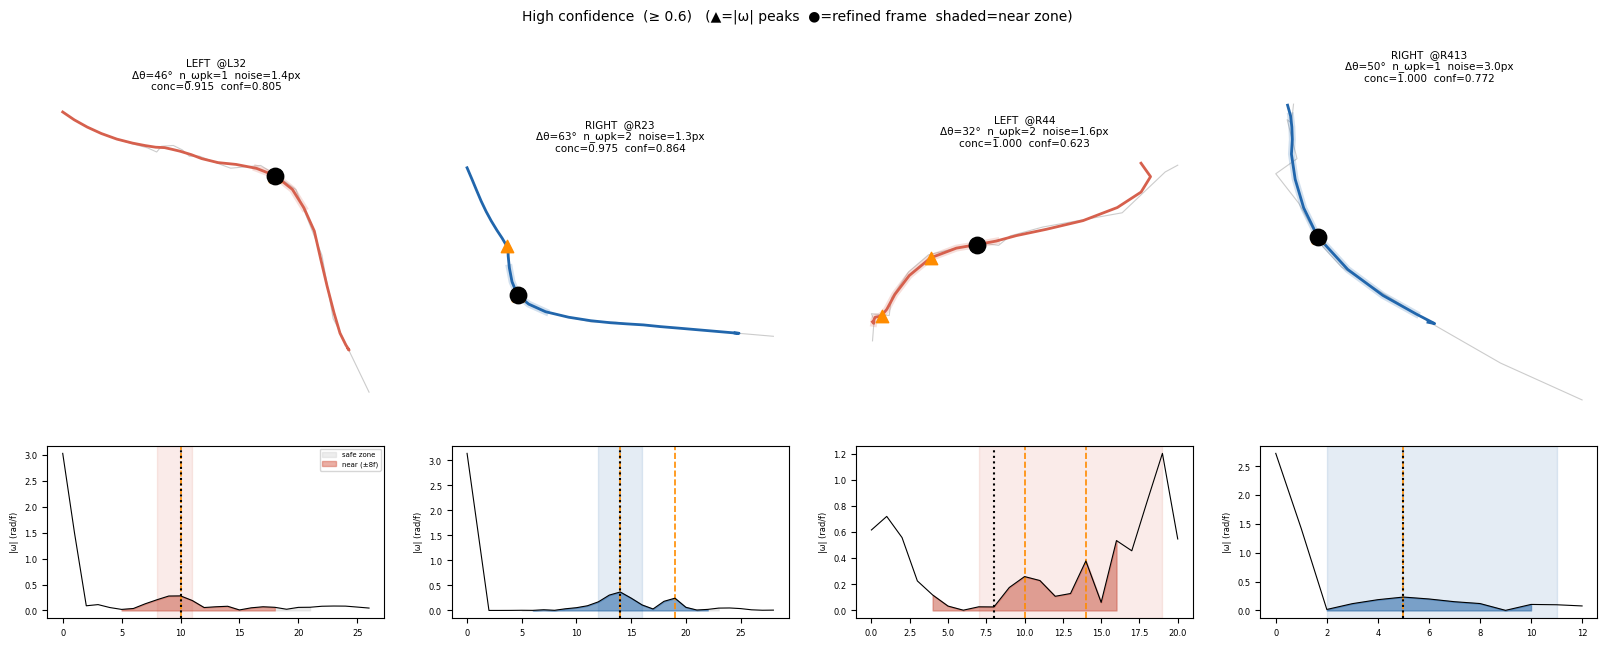

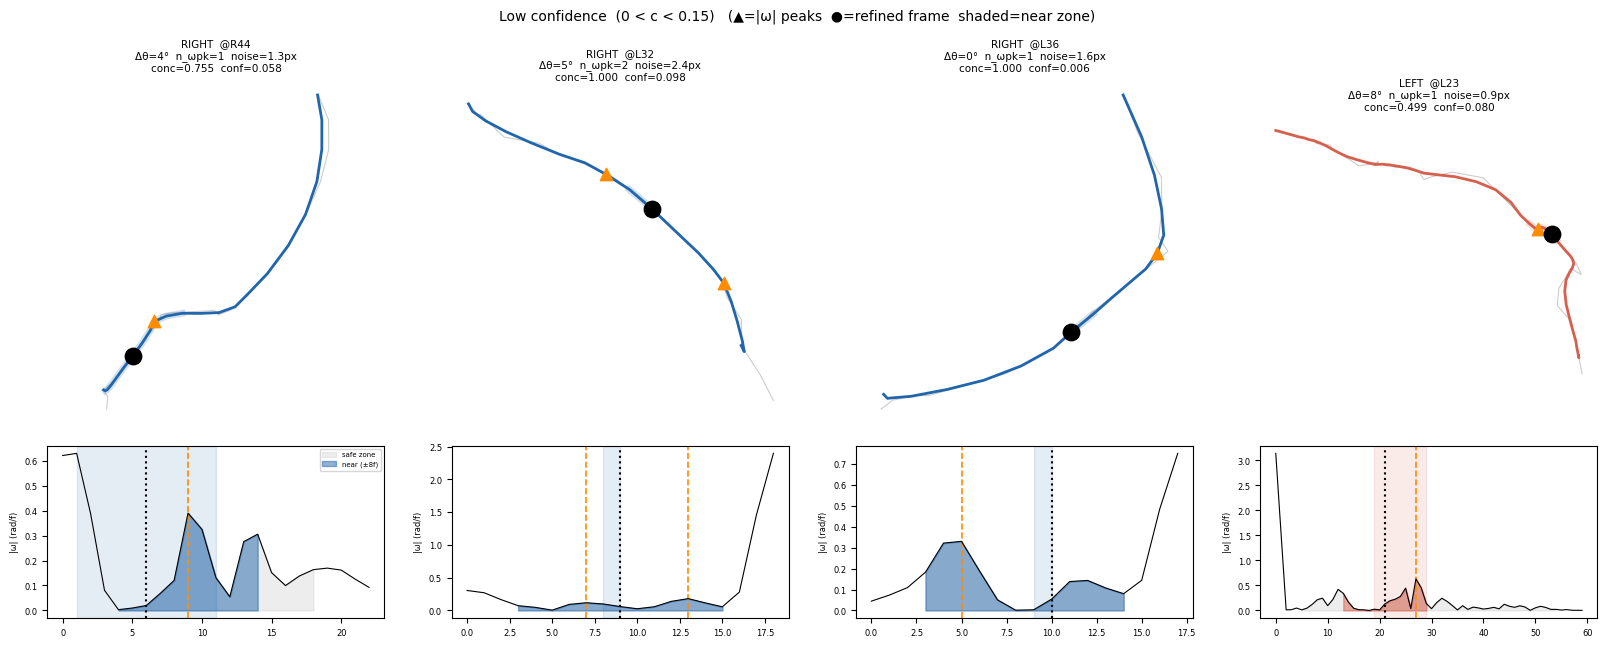

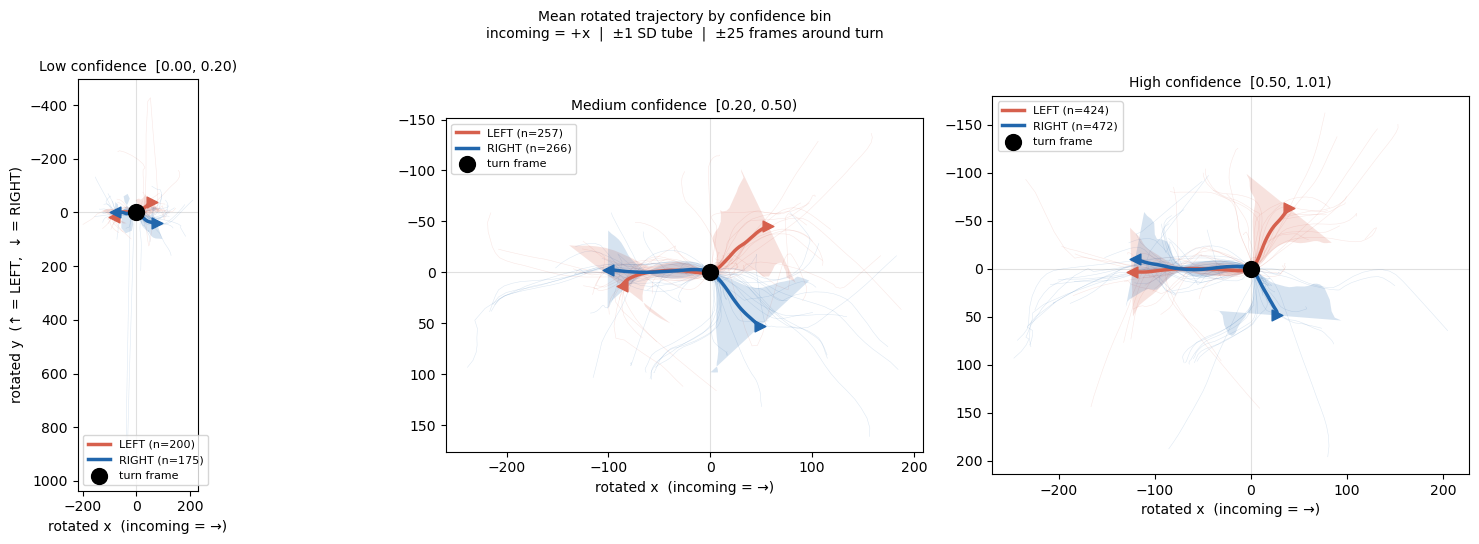

In [71]:
# ── Cell 12c: Confidence Examples + Mean Rotated Trajectory ──────────────────
#
# Part 1 — Above / below threshold counts.
#
# Part 2 — Example trajectories: N_EXAMPLES turns from the high-confidence pool
#   and N_EXAMPLES from the low-confidence pool.  Each panel shows the raw (gray)
#   and smoothed (coloured) path.  The |ω|(t) signal is plotted in a secondary
#   axis below each trajectory, with the safe zone shaded and the near zone
#   (±CONC_WIN around the refined frame) highlighted so it is easy to see why a
#   turn received its confidence score.
#
# Part 3 — Mean rotated trajectory per confidence bin (Low / Medium / High).
#   Trajectories are rotated so incoming direction = +x, centred at turn frame.
#   Spaghetti traces + bold mean + perpendicular-SD tube.

from matplotlib.patches import Polygon as _MplPolygon
from matplotlib.gridspec import GridSpec

CONF_BINS   = [("Low",    0.00, 0.20),
               ("Medium", 0.20, 0.50),
               ("High",   0.50, 1.01)]
N_EXAMPLES  = 4
TRAJ_HALF   = 25
N_SPAGHETTI = 25

# ── Part 1: above / below threshold ──────────────────────────────────────────
lr_df   = turn_df[turn_df["turn_type"].isin(["LEFT", "RIGHT"])]
n_above = (lr_df["turn_confidence"] >= MIN_CONFIDENCE).sum()
n_below = len(lr_df) - n_above
print(f"LEFT + RIGHT turns:  {len(lr_df)}")
print(f"  >= {MIN_CONFIDENCE} (pass) : {n_above:4d}  ({100*n_above/len(lr_df):.1f}%)")
print(f"   < {MIN_CONFIDENCE} (fail) : {n_below:4d}  ({100*n_below/len(lr_df):.1f}%)")
print()
for lbl, lo_, hi_ in CONF_BINS:
    n = ((lr_df["turn_confidence"] >= lo_) & (lr_df["turn_confidence"] < hi_)).sum()
    print(f"  {lbl:7s} [{lo_:.2f}, {hi_:.2f}): {n}")


# ── Helpers ───────────────────────────────────────────────────────────────────
def _get_smoothed(row, sub_date):
    lo_ = max(int(row["start_frame_global"]) - BUFFER, int(row["prev_end_frame_global"]))
    hi_ = min(int(row["end_frame_global"])   + BUFFER, int(row["next_start_frame_global"]))
    seg = sub_date[(sub_date[FRAME_COL] >= lo_) &
                   (sub_date[FRAME_COL] <= hi_)].sort_values(FRAME_COL)
    if len(seg) < SG_WINDOW:
        return None
    x_r = seg[X_COL].values.astype(float)
    y_r = seg[Y_COL].values.astype(float)
    frs = seg[FRAME_COL].values
    if np.any(np.isnan(x_r)) or np.any(np.isnan(y_r)):
        return None
    mw = min(MED_WINDOW, len(x_r))
    if mw % 2 == 0: mw -= 1
    mw = max(mw, 3)
    xs = savgol_filter(medfilt(x_r, mw), SG_WINDOW, SG_POLY)
    ys = savgol_filter(medfilt(y_r, mw), SG_WINDOW, SG_POLY)
    inner_ = (frs >= int(row["start_frame_global"])) & (frs <= int(row["end_frame_global"]))
    rf     = row.get("refined_turn_frame_global")
    rf_ix  = int(np.argmin(np.abs(frs - int(rf)))) if pd.notna(rf) else None
    return x_r, y_r, xs, ys, frs, inner_, rf_ix


def _rotated_traj(row, sub_date, half_win=TRAJ_HALF):
    rf = row.get("refined_turn_frame_global")
    if pd.isna(rf):
        return None
    rf = int(rf)
    seg = sub_date[(sub_date[FRAME_COL] >= rf - half_win - 10) &
                   (sub_date[FRAME_COL] <= rf + half_win + 10)].sort_values(FRAME_COL)
    if len(seg) < 2 * half_win + 1:
        return None
    x_r = seg[X_COL].values.astype(float)
    y_r = seg[Y_COL].values.astype(float)
    frs = seg[FRAME_COL].values
    if np.any(np.isnan(x_r)) or np.any(np.isnan(y_r)):
        return None
    mw = min(MED_WINDOW, len(x_r))
    if mw % 2 == 0: mw -= 1
    mw = max(mw, 3)
    xs = savgol_filter(medfilt(x_r, mw), SG_WINDOW, SG_POLY)
    ys = savgol_filter(medfilt(y_r, mw), SG_WINDOW, SG_POLY)
    pidx = int(np.argmin(np.abs(frs - rf)))
    if pidx < half_win or pidx + half_win + 1 > len(xs):
        return None
    xc = xs[pidx - half_win: pidx + half_win + 1] - xs[pidx]
    yc = ys[pidx - half_win: pidx + half_win + 1] - ys[pidx]
    q     = max(1, half_win // 2)
    dx_in = float(np.mean(np.diff(xc[q: half_win + 1])))
    dy_in = float(np.mean(np.diff(yc[q: half_win + 1])))
    if np.hypot(dx_in, dy_in) < 1e-6:
        return None
    theta = np.arctan2(dy_in, dx_in)
    ct, st = np.cos(-theta), np.sin(-theta)
    return ct * xc - st * yc, st * xc + ct * yc


# ── Part 2: Example trajectory + |ω|(t) panels ───────────────────────────────
example_groups = [
    ("High confidence  (≥ 0.6)",
     turn_df[turn_df["turn_type"].isin(["LEFT","RIGHT"]) &
             (turn_df["turn_confidence"] >= 0.6) &
             turn_df["refined_turn_frame_global"].notna()]),
    ("Low confidence  (0 < c < 0.15)",
     turn_df[turn_df["turn_type"].isin(["LEFT","RIGHT"]) &
             (turn_df["turn_confidence"] > 0) &
             (turn_df["turn_confidence"] < 0.15) &
             turn_df["refined_turn_frame_global"].notna()]),
]

for group_label, pool in example_groups:
    if pool.empty:
        print(f"No turns in pool: {group_label}")
        continue
    sample = pool.sample(min(N_EXAMPLES, len(pool)), random_state=42)
    n_cols = len(sample)

    # 2 rows per example (trajectory + |ω| panel)
    fig = plt.figure(figsize=(5 * n_cols, 7))
    gs  = GridSpec(2, n_cols, height_ratios=[3, 1.5], hspace=0.08, figure=fig)

    for col_i, (_, row) in enumerate(sample.iterrows()):
        ax_xy  = fig.add_subplot(gs[0, col_i])
        ax_om  = fig.add_subplot(gs[1, col_i])

        sub = _summary_by_date.get(row["session_date"], pd.DataFrame())
        if sub.empty:
            ax_xy.axis("off"); ax_om.axis("off"); continue
        res = _get_smoothed(row, sub)
        if res is None:
            ax_xy.axis("off"); ax_om.axis("off"); continue
        x_r, y_r, xs, ys, frs, inner_, rf_ix = res

        # Recompute |ω| and safe/near masks (same logic as refine_turn)
        dxs = np.gradient(xs); dys = np.gradient(ys)
        om  = np.abs(np.gradient(np.unwrap(np.arctan2(dys, dxs))))
        eg  = min(EDGE_GUARD, len(frs) // 5)
        safe_viz = np.zeros(len(frs), dtype=bool)
        safe_viz[eg: len(frs) - eg] = True
        near_viz = np.zeros(len(frs), dtype=bool)
        if rf_ix is not None:
            near_viz[max(0, rf_ix - CONC_WIN): min(len(frs), rf_ix + CONC_WIN + 1)] = True

        # ω peaks in safe & near zone
        ns_idx = np.where(safe_viz & near_viz)[0]
        om_peaks = np.array([], dtype=int)
        if len(ns_idx) >= 3:
            om_ns = om[ns_idx]
            rng   = om_ns.max() - om_ns.min()
            if rng > 1e-8:
                pks, _ = find_peaks(om_ns,
                                    prominence=OMEGA_MIN_PROM * rng,
                                    distance=OMEGA_MIN_DIST)
                om_peaks = ns_idx[pks]

        color = TURN_COLORS.get(row["turn_type"], "#888888")

        # ── Trajectory panel ─────────────────────────────────────────────────
        ax_xy.plot(x_r, y_r, color="#cccccc", lw=0.8, zorder=1)
        ax_xy.plot(xs, ys, color=color, lw=2.0, zorder=2)
        ax_xy.plot(xs[inner_], ys[inner_], color=color, lw=5.0, alpha=0.20, zorder=1)
        for pk in om_peaks:
            ax_xy.scatter(xs[pk], ys[pk], s=80, color="darkorange",
                          marker="^", zorder=5)
        if rf_ix is not None:
            ax_xy.scatter(xs[rf_ix], ys[rf_ix], s=140, color="black",
                          marker="o", zorder=6)
        ax_xy.set_aspect("equal")
        ax_xy.invert_yaxis()
        ax_xy.axis("off")

        conc  = row.get("turn_concentration", float("nan"))
        delta = row.get("delta_theta_deg", float("nan"))
        n_pk  = int(row["n_omega_peaks"]) if pd.notna(row.get("n_omega_peaks")) else "?"
        ax_xy.set_title(
            f"{row['turn_type']}  @{row['curr_node']}\n"
            f"Δθ={delta:.0f}°  n_ωpk={n_pk}  noise={row['tracking_noise_px']:.1f}px\n"
            f"conc={conc:.3f}  conf={row['turn_confidence']:.3f}",
            fontsize=7.5,
        )

        # ── |ω|(t) panel ─────────────────────────────────────────────────────
        t_axis = np.arange(len(frs))
        ax_om.fill_between(t_axis, 0, om,
                           where=safe_viz, color="#cccccc", alpha=0.35,
                           label="safe zone")
        ax_om.fill_between(t_axis, 0, om,
                           where=safe_viz & near_viz, color=color, alpha=0.50,
                           label=f"near (±{CONC_WIN}f)")
        ax_om.plot(t_axis, om, color="black", lw=0.8, zorder=3)
        for pk in om_peaks:
            ax_om.axvline(pk, color="darkorange", lw=1.2, ls="--")
        if rf_ix is not None:
            ax_om.axvline(rf_ix, color="black", lw=1.5, ls=":")
        # Mark inner window
        inner_idx_viz = np.where(inner_)[0]
        if len(inner_idx_viz):
            ax_om.axvspan(inner_idx_viz[0], inner_idx_viz[-1],
                          alpha=0.12, color=color)
        ax_om.set_ylabel("|ω| (rad/f)", fontsize=6)
        ax_om.tick_params(labelsize=6)
        if col_i == 0:
            ax_om.legend(fontsize=5, loc="upper right")

    fig.suptitle(f"{group_label}   (▲=|ω| peaks  ●=refined frame  shaded=near zone)",
                 fontsize=10)
    plt.show()


# ── Part 3: Mean rotated trajectory per confidence bin ────────────────────────
rng_seed = np.random.default_rng(seed=42)
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

for ax, (lbl, lo_, hi_) in zip(axes, CONF_BINS):
    ax.axhline(0, color="#e0e0e0", lw=0.8, zorder=0)
    ax.axvline(0, color="#e0e0e0", lw=0.8, zorder=0)

    for tt, color in [("LEFT", "#d6604d"), ("RIGHT", "#2166ac")]:
        pool = turn_df[
            (turn_df["turn_type"] == tt) &
            (turn_df["turn_confidence"] >= lo_) &
            (turn_df["turn_confidence"] < hi_) &
            turn_df["refined_turn_frame_global"].notna()
        ]
        trajs = []
        for _, row in pool.iterrows():
            sub = _summary_by_date.get(row["session_date"], pd.DataFrame())
            if sub.empty:
                continue
            res = _rotated_traj(row, sub, half_win=TRAJ_HALF)
            if res is not None:
                trajs.append(np.stack(res, axis=1))

        if len(trajs) < 3:
            continue

        arr     = np.array(trajs)
        mean_xy = arr.mean(axis=0)

        # Spaghetti
        sidx = rng_seed.choice(len(trajs), min(N_SPAGHETTI, len(trajs)), replace=False)
        for si in sidx:
            ax.plot(arr[si, :, 0], arr[si, :, 1],
                    color=color, lw=0.4, alpha=0.15, zorder=1)

        # Perpendicular-SD tube
        dxm   = np.gradient(mean_xy[:, 0])
        dym   = np.gradient(mean_xy[:, 1])
        mag_m = np.hypot(dxm, dym) + 1e-8
        px = -dym / mag_m
        py =  dxm / mag_m
        resid = arr - mean_xy[None]
        std_p = (resid[:, :, 0] * px[None] + resid[:, :, 1] * py[None]).std(axis=0)
        upper = mean_xy + np.stack([px * std_p, py * std_p], axis=1)
        lower = mean_xy - np.stack([px * std_p, py * std_p], axis=1)
        verts = np.vstack([upper, lower[::-1]])
        ax.add_patch(_MplPolygon(verts, closed=True,
                                 facecolor=color, alpha=0.18, edgecolor="none", zorder=2))
        ax.plot(mean_xy[:, 0], mean_xy[:, 1], color=color, lw=2.5, zorder=3,
                label=f"{tt} (n={len(trajs)})")
        ax.scatter(*mean_xy[0],  s=60, color=color, marker="<", zorder=4)
        ax.scatter(*mean_xy[-1], s=60, color=color, marker=">", zorder=4)

    scale = TRAJ_HALF * 0.35
    ax.scatter([0], [0], s=130, color="black", marker="o", zorder=5, label="turn frame")
    ax.annotate("", xy=(scale, 0), xytext=(-scale, 0),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.3))
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_title(f"{lbl} confidence  [{lo_:.2f}, {hi_:.2f})", fontsize=10)
    ax.set_xlabel("rotated x  (incoming = →)")
    if ax is axes[0]:
        ax.set_ylabel("rotated y  (↑ = LEFT,  ↓ = RIGHT)")
    ax.legend(fontsize=8)

fig.suptitle(
    "Mean rotated trajectory by confidence bin\n"
    f"incoming = +x  |  ±1 SD tube  |  ±{TRAJ_HALF} frames around turn",
    fontsize=10,
)
plt.tight_layout()
plt.show()

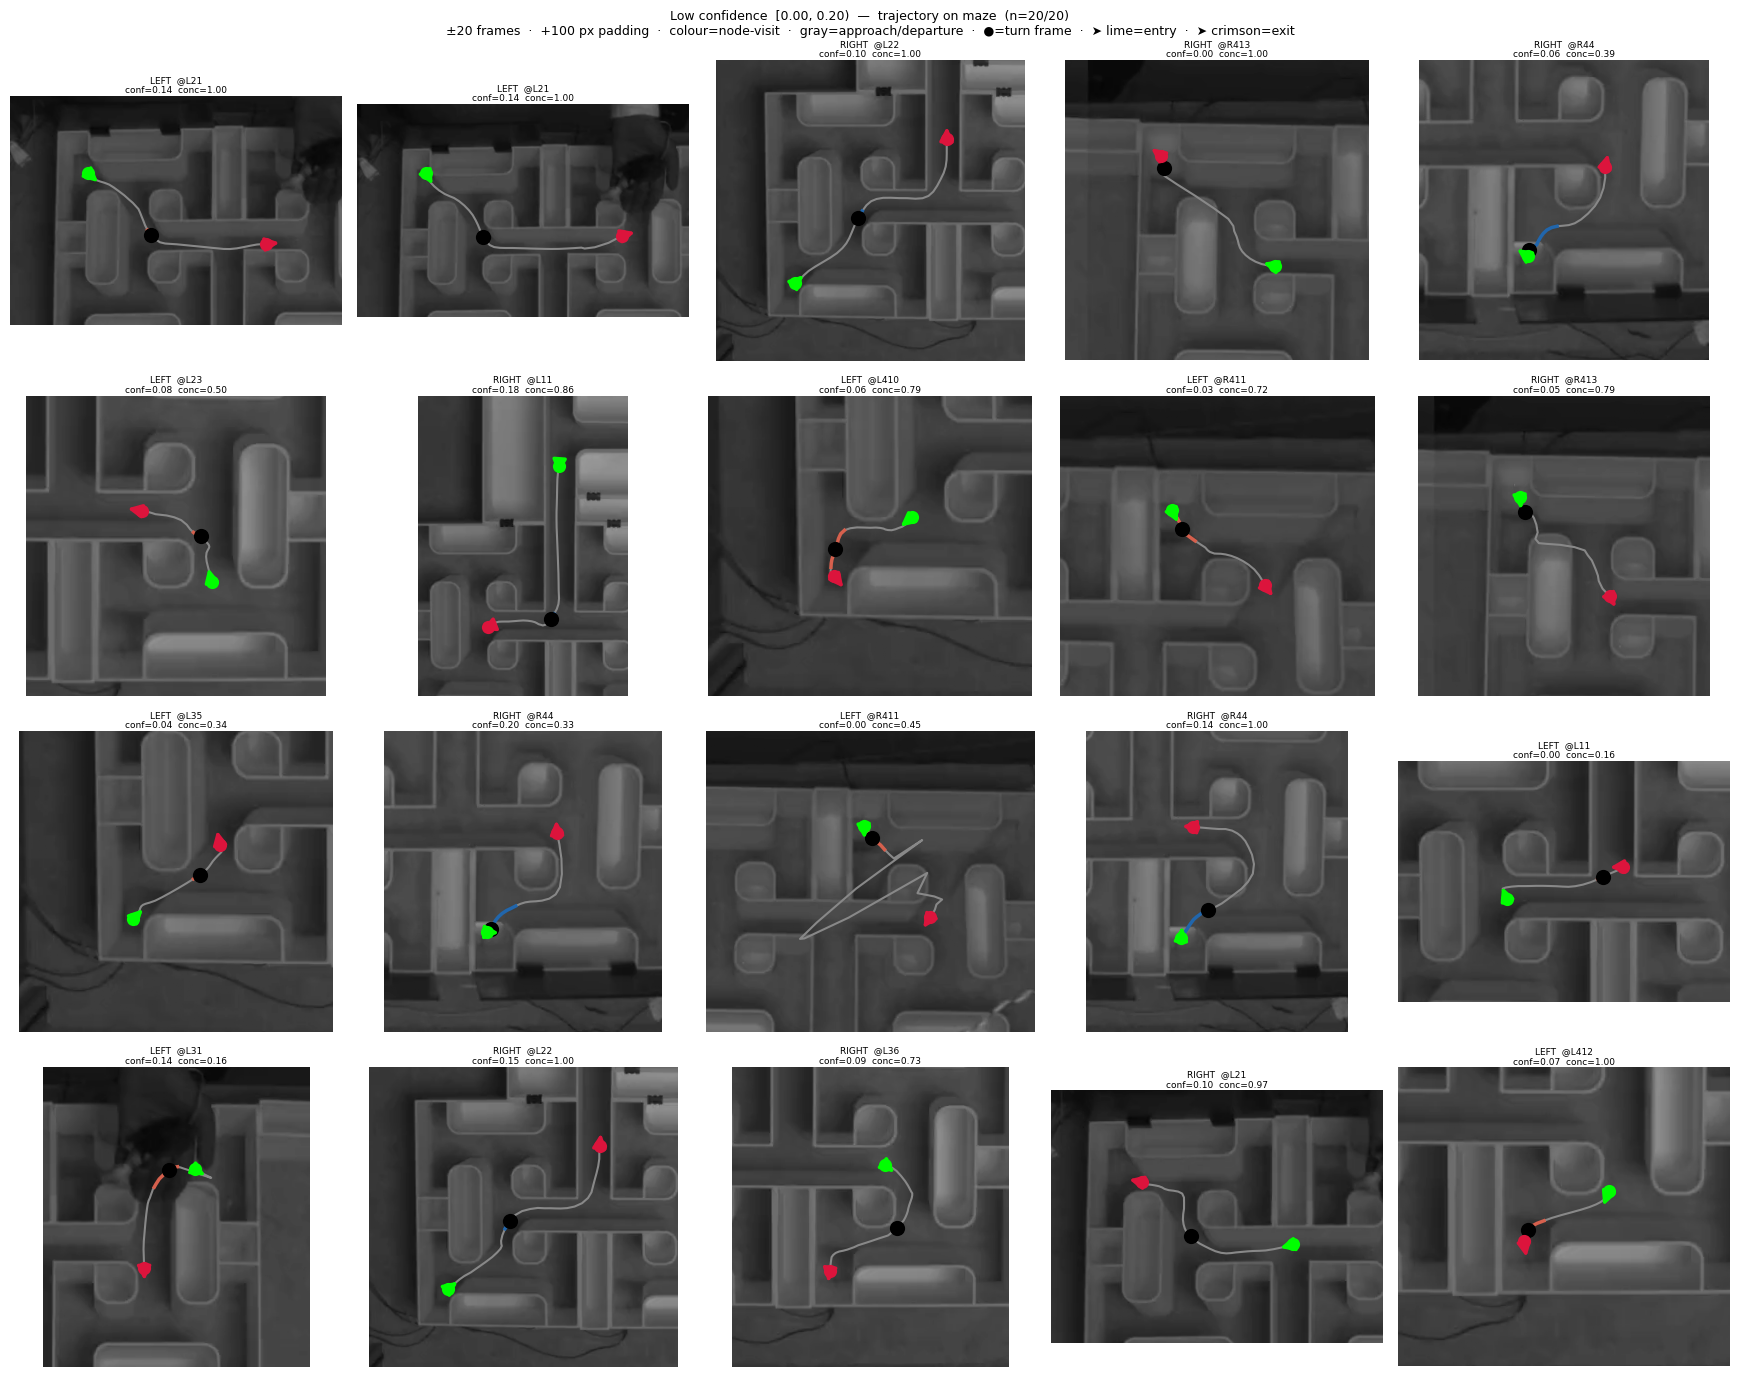

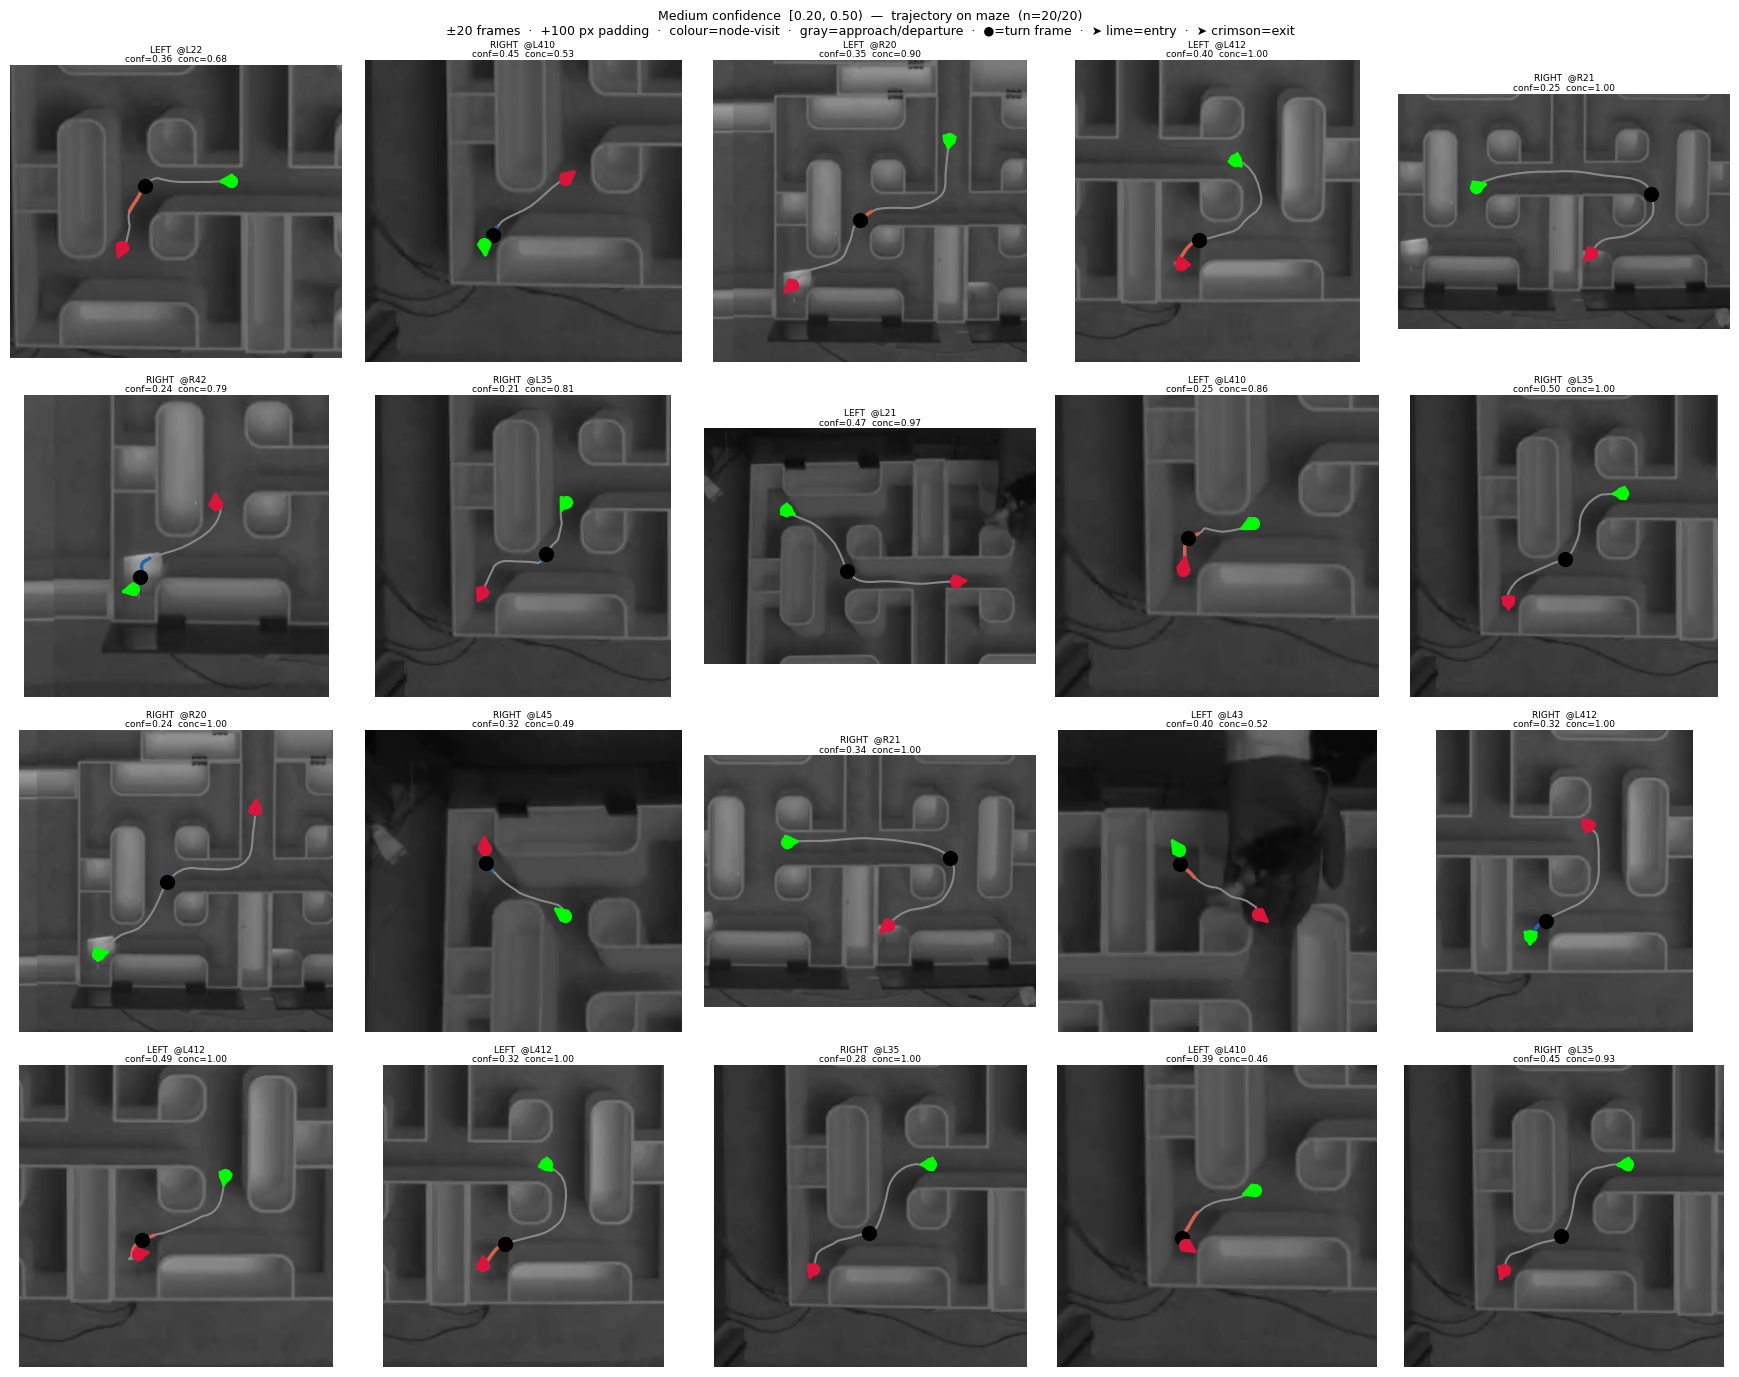

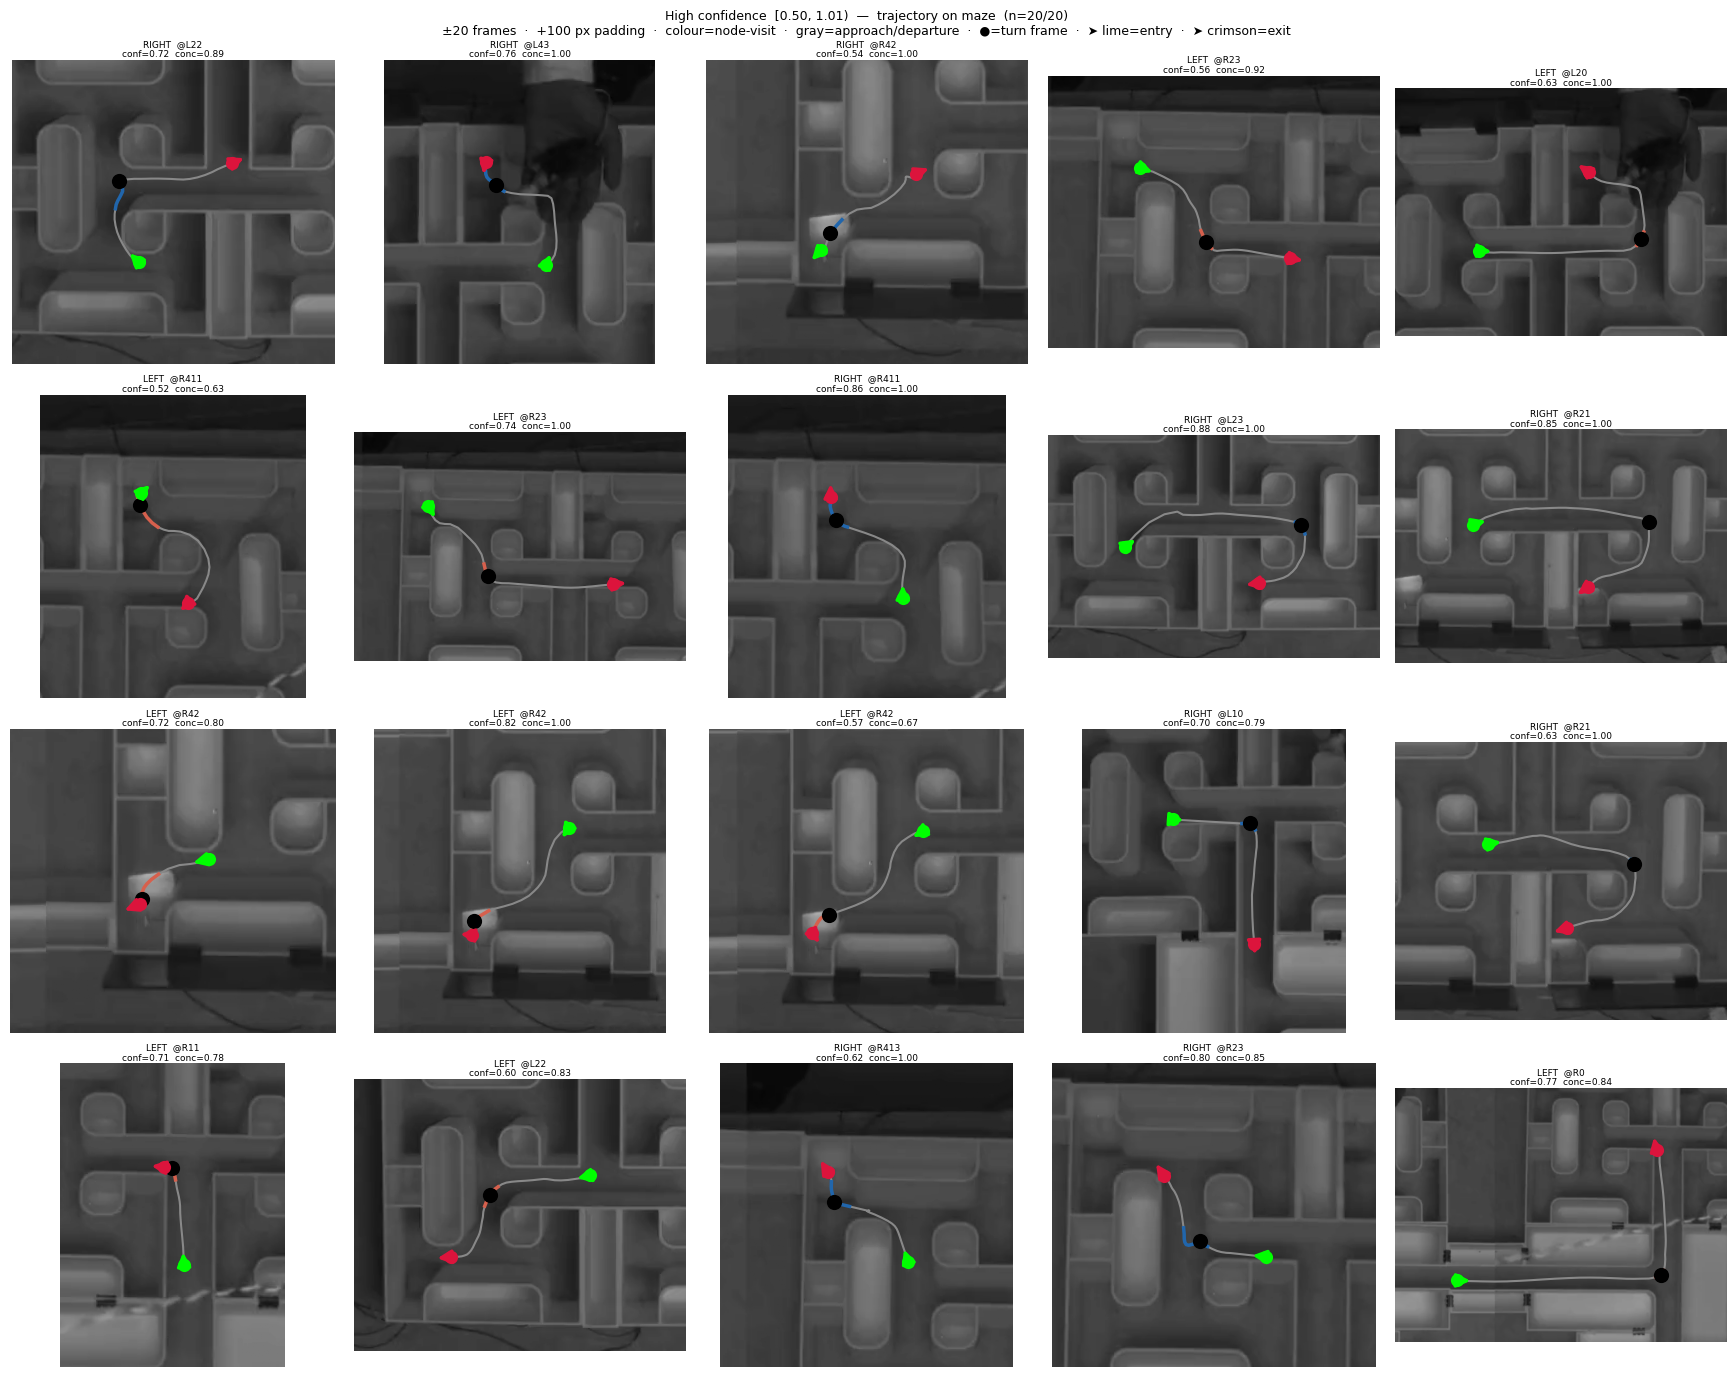

In [72]:
# ── Cell 12d: Turn Trajectories Overlaid on Maze Image ───────────────────────
#
# For each confidence bin (Low / Medium / High) show N_OVERLAY_EXAMPLES turns
# from LEFT + RIGHT plotted directly on the cropped maze background image.
#
# Trajectory colouring:
#   • Approach & departure (±window around turn, outside node-visit) — gray
#   • Node-visit window                                              — turn-type colour (red/blue)
#   • Refined turn frame                                             — ● black
#   • Entry direction arrow  ➤                                      — lime-green
#   • Exit  direction arrow  ➤                                      — crimson
#
# Window: refined_turn_frame ± OVERLAY_HALF_WIN frames (= 0.5 s at 40 FPS).
# Image naming:  session_date "DD_MM_YYYY"  →  NPC1_YYYY_MM_DD.png

import math
import matplotlib.image as mpimg

MAZE_IMAGES_DIR    = OUTPUTS_DIR.parent / "maze_images"
OVERLAY_HALF_WIN   = 20    # ±frames around refined turn frame
OVERLAY_PADDING    = 100   # px padding around trajectory bounding box
N_OVERLAY_EXAMPLES = 20    # per confidence bin
N_OVERLAY_COLS     = 5
_DIR_LOOK          = 4     # frames ahead/back used to compute motion direction

_maze_image_cache: dict = {}


def _load_maze_image(session_date: str):
    """Load (and cache) the maze PNG for a session_date in DD_MM_YYYY format."""
    if session_date in _maze_image_cache:
        return _maze_image_cache[session_date]
    dd, mm, yyyy = session_date.split("_")
    img_path = MAZE_IMAGES_DIR / f"NPC1_{yyyy}_{mm}_{dd}.png"
    if not img_path.exists():
        print(f"WARNING: maze image not found: {img_path}")
        _maze_image_cache[session_date] = None
        return None
    img = mpimg.imread(str(img_path))
    _maze_image_cache[session_date] = img
    return img


def _get_traj_for_overlay(row, sub_date, half_win=OVERLAY_HALF_WIN):
    """
    Return (x_raw, y_raw, x_smooth, y_smooth, frames, rf_local_ix)
    for ±half_win frames around the refined turn frame, or None on failure.
    """
    rf = row.get("refined_turn_frame_global")
    if pd.isna(rf):
        return None
    rf = int(rf)

    margin = max(SG_WINDOW, 5)
    seg = sub_date[
        (sub_date[FRAME_COL] >= rf - half_win - margin) &
        (sub_date[FRAME_COL] <= rf + half_win + margin)
    ].sort_values(FRAME_COL)

    if len(seg) < SG_WINDOW:
        return None

    x_r = seg[X_COL].values.astype(float)
    y_r = seg[Y_COL].values.astype(float)
    frs = seg[FRAME_COL].values

    valid = np.isfinite(x_r) & np.isfinite(y_r)
    if valid.sum() < SG_WINDOW:
        return None

    tidx = np.arange(len(x_r))
    x_f  = np.interp(tidx, tidx[valid], x_r[valid])
    y_f  = np.interp(tidx, tidx[valid], y_r[valid])

    mw = min(MED_WINDOW, len(x_f))
    if mw % 2 == 0:
        mw -= 1
    mw = max(mw, 3)
    xs = savgol_filter(medfilt(x_f, mw), SG_WINDOW, SG_POLY)
    ys = savgol_filter(medfilt(y_f, mw), SG_WINDOW, SG_POLY)

    rf_ix = int(np.argmin(np.abs(frs - rf)))
    lo_ix = max(0, rf_ix - half_win)
    hi_ix = min(len(frs) - 1, rf_ix + half_win)

    return (
        x_r[lo_ix: hi_ix + 1],
        y_r[lo_ix: hi_ix + 1],
        xs [lo_ix: hi_ix + 1],
        ys [lo_ix: hi_ix + 1],
        frs[lo_ix: hi_ix + 1],
        rf_ix - lo_ix,
    )


def _dir_arrow(ax, xs_c, ys_c, pt_idx, arrow_len, clr):
    """
    Draw a filled directional arrow at xs_c[pt_idx], ys_c[pt_idx] pointing
    in the local direction of motion, plus a coloured dot at the base.
    pt_idx = 0 for entry, -1 for exit.
    """
    n = len(xs_c)
    if pt_idx >= 0:
        fwd  = min(pt_idx + _DIR_LOOK, n - 1)
        dx, dy = xs_c[fwd] - xs_c[pt_idx], ys_c[fwd] - ys_c[pt_idx]
    else:
        bwd  = max(0, n + pt_idx - _DIR_LOOK)
        dx, dy = xs_c[n + pt_idx] - xs_c[bwd], ys_c[n + pt_idx] - ys_c[bwd]

    mag = np.hypot(dx, dy)
    if mag > 1e-3:
        ux, uy = dx / mag, dy / mag
        bx, by = xs_c[pt_idx], ys_c[pt_idx]
        ax.annotate(
            "",
            xy     = (bx + arrow_len * ux, by + arrow_len * uy),
            xytext = (bx, by),
            arrowprops=dict(arrowstyle="-|>", color=clr, lw=2.5, mutation_scale=20),
            zorder=8,
        )
    ax.scatter([xs_c[pt_idx]], [ys_c[pt_idx]],
               s=90, color=clr, marker="o", zorder=9, linewidths=0)


def _plot_turn_on_maze(ax, row, sub_date, color, padding=OVERLAY_PADDING):
    """
    Draw one turn on a cropped maze image inside `ax`.
    Returns True on success, False when data or image is missing.
    """
    img = _load_maze_image(row["session_date"])
    if img is None:
        return False

    res = _get_traj_for_overlay(row, sub_date)
    if res is None:
        return False
    x_r, y_r, xs, ys, frs, rf_local = res

    h, w = img.shape[:2]
    x0 = max(0,  int(np.nanmin(xs)) - padding)
    x1 = min(w,  int(np.nanmax(xs)) + padding)
    y0 = max(0,  int(np.nanmin(ys)) - padding)
    y1 = min(h,  int(np.nanmax(ys)) + padding)

    if x1 <= x0 or y1 <= y0:
        return False

    ax.imshow(img[y0:y1, x0:x1], origin="upper", aspect="equal")

    xs_c = xs  - x0;  ys_c = ys  - y0

    # ── Three-segment trajectory: approach (gray) | node-visit (colour) | departure (gray)
    inner = (frs >= int(row["start_frame_global"])) & (frs <= int(row["end_frame_global"]))

    if inner.any():
        i_s = int(np.argmax(inner))                            # first inner frame index
        i_e = int(len(inner) - 1 - np.argmax(inner[::-1]))    # last  inner frame index
    else:
        i_s = i_e = rf_local   # fallback: single-frame window centred on turn

    # Approach (gray) — connect cleanly to the coloured segment at i_s
    if i_s > 0:
        ax.plot(xs_c[:i_s + 1], ys_c[:i_s + 1],
                color="#888888", lw=1.5, zorder=2)
    # Node-visit window (turn-type colour)
    ax.plot(xs_c[i_s:i_e + 1], ys_c[i_s:i_e + 1],
            color=color, lw=2.5, zorder=3)
    # Departure (gray) — connect from i_e
    if i_e < len(xs_c) - 1:
        ax.plot(xs_c[i_e:], ys_c[i_e:],
                color="#888888", lw=1.5, zorder=2)

    # Refined turn frame marker
    ax.scatter([xs_c[rf_local]], [ys_c[rf_local]],
               s=120, color="black", marker="o", zorder=6, linewidths=0)

    # Arrow length = 5 % of crop width, clamped to [15, 40] px
    alen = int(np.clip(0.05 * (x1 - x0), 15, 40))

    _dir_arrow(ax, xs_c, ys_c,  0, alen, "lime")     # entry  ➤ lime-green
    _dir_arrow(ax, xs_c, ys_c, -1, alen, "crimson")  # exit   ➤ crimson

    ax.set_aspect("equal")
    ax.axis("off")
    return True


# ── One figure per confidence bin ─────────────────────────────────────────────
for bin_lbl, lo_, hi_ in CONF_BINS:
    pool = turn_df[
        turn_df["turn_type"].isin(["LEFT", "RIGHT"]) &
        (turn_df["turn_confidence"] >= lo_) &
        (turn_df["turn_confidence"] <  hi_) &
        turn_df["refined_turn_frame_global"].notna()
    ]

    if pool.empty:
        print(f"No turns in {bin_lbl} [{lo_:.2f}, {hi_:.2f}), skipping.")
        continue

    sample  = pool.sample(min(N_OVERLAY_EXAMPLES, len(pool)), random_state=42)
    n_rows_ = math.ceil(len(sample) / N_OVERLAY_COLS)

    fig, axes = plt.subplots(
        n_rows_, N_OVERLAY_COLS,
        figsize=(3.5 * N_OVERLAY_COLS, 3.5 * n_rows_),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    plotted = 0
    for ax_i, (_, row) in enumerate(sample.iterrows()):
        ax    = axes_flat[ax_i]
        color = TURN_COLORS.get(row["turn_type"], "#888888")
        sub   = _summary_by_date.get(row["session_date"], pd.DataFrame())

        if not sub.empty and _plot_turn_on_maze(ax, row, sub, color):
            conc = row.get("turn_concentration", float("nan"))
            ax.set_title(
                f"{row['turn_type']}  @{row['curr_node']}\n"
                f"conf={row['turn_confidence']:.2f}  conc={conc:.2f}",
                fontsize=6.5, pad=2,
            )
            plotted += 1
        else:
            ax.axis("off")

    for ax in axes_flat[plotted:]:
        ax.axis("off")

    fig.suptitle(
        f"{bin_lbl} confidence  [{lo_:.2f}, {hi_:.2f})  —  trajectory on maze  "
        f"(n={plotted}/{len(sample)})\n"
        f"±{OVERLAY_HALF_WIN} frames  ·  +{OVERLAY_PADDING} px padding  ·  "
        f"colour=node-visit  ·  gray=approach/departure  ·  "
        f"●=turn frame  ·  ➤ lime=entry  ·  ➤ crimson=exit",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()

=== Three-Way Turn Timing Comparison ===
Valid rows: 2706   Good (conf >= 0.15): 2218

Method        mean offset   median     std   |mean|
------------------------------------------------------
  naive              +3.7     +2.0     4.4      3.7  frames
  midpoint           -0.2     +0.0     2.6      1.5  frames

Normalised position of refined frame within node visit
  (0 = entry, 0.5 = midpoint heuristic, 1 = naive/exit)
  LEFT  : mean=0.42  median=0.40
  RIGHT : mean=0.35  median=0.33


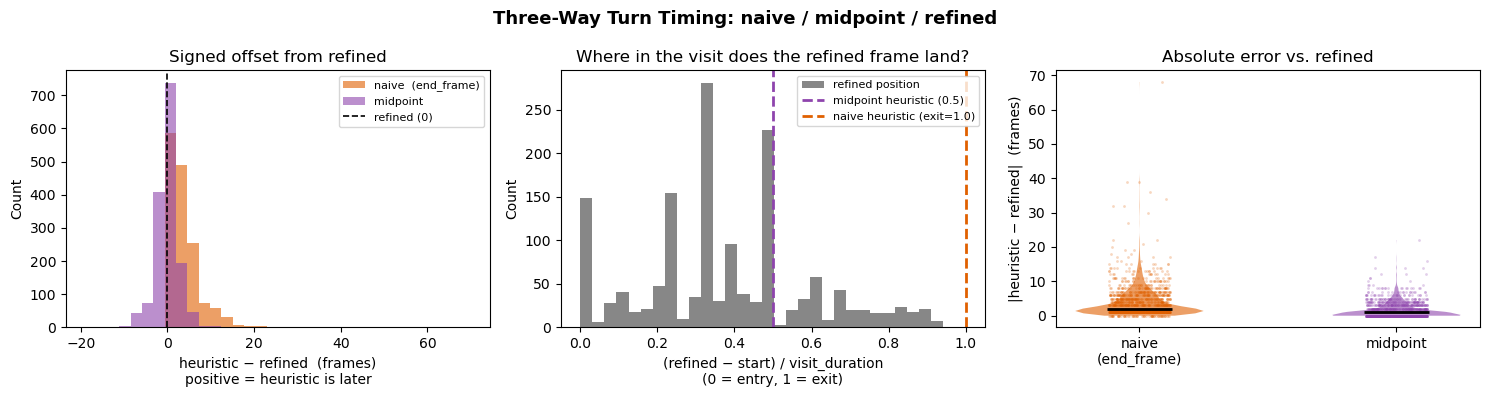

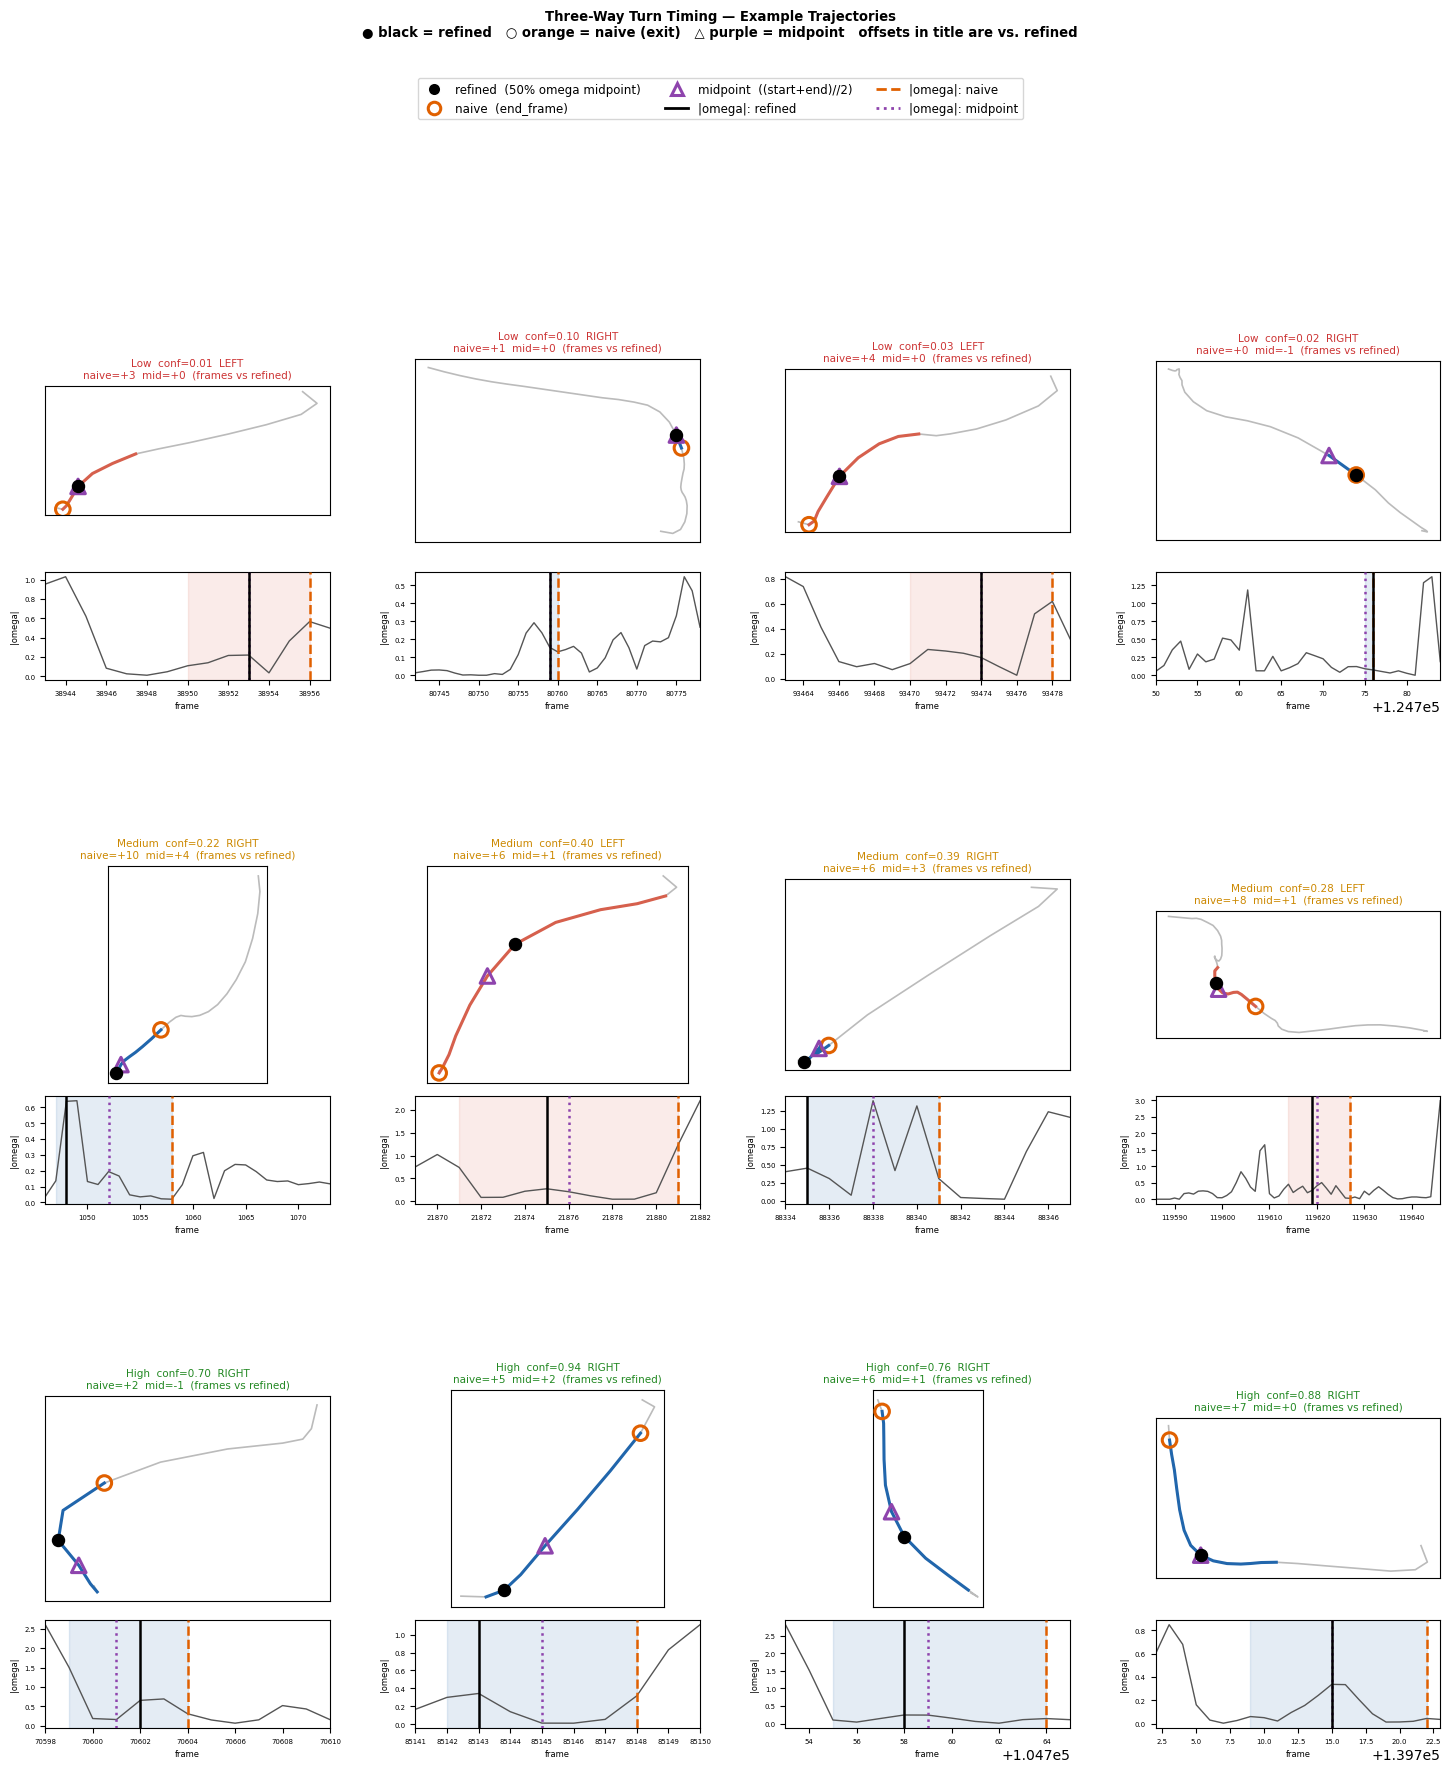

In [73]:
# ── Cell 12e: Three-Way Turn Timing Comparison ──────────────────────────────
#
# Method 1 — refined   : refined_turn_frame_global
#   50% cumulative heading-change midpoint computed from |ω(t)| (Cell 10).
#   Uses the actual trajectory; trajectory data required.
#
# Method 2 — naive     : end_frame_global
#   Last frame of the node visit.  No trajectory needed.
#
# Method 3 — midpoint  : (start_frame_global + end_frame_global) // 2
#   Temporal centre of the node-visit dwell.  No trajectory needed.
#
# Distribution plots compare how far each heuristic is from the refined
# estimate (positive offset = heuristic is later in time than refined).
# Example panels overlay all three markers on the trajectory + |ω|(t).

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# Colour / marker scheme (consistent across all panels)
C_REFINED  = "black"
C_NAIVE    = "#e06000"   # orange
C_MID      = "#8E44AD"   # purple

# ── 1. Compute offset metrics ──────────────────────────────────────────────
has_refined = turn_df["refined_turn_frame_global"].notna()
has_bounds  = turn_df["end_frame_global"].notna() & turn_df["start_frame_global"].notna()
valid_cmp   = turn_df[has_refined & has_bounds].copy()

valid_cmp["naive_turn_frame"]    = valid_cmp["end_frame_global"].astype(int)
valid_cmp["midpoint_turn_frame"] = (
    (valid_cmp["start_frame_global"].astype(int)
     + valid_cmp["end_frame_global"].astype(int)) // 2
)
valid_cmp["visit_duration_frames"] = (
    valid_cmp["end_frame_global"].astype(int)
    - valid_cmp["start_frame_global"].astype(int) + 1
).clip(lower=1)

# Offsets from refined (positive = heuristic is later than refined)
valid_cmp["offset_naive"] = (
    valid_cmp["naive_turn_frame"]
    - valid_cmp["refined_turn_frame_global"].astype(int)
)
valid_cmp["offset_mid"] = (
    valid_cmp["midpoint_turn_frame"]
    - valid_cmp["refined_turn_frame_global"].astype(int)
)
# Normalised: where does the refined frame sit within the visit?
# 0 = at entry, 1 = at exit  (midpoint heuristic assumes 0.5)
valid_cmp["refined_pos_in_visit"] = (
    (valid_cmp["refined_turn_frame_global"].astype(int)
     - valid_cmp["start_frame_global"].astype(int))
    / valid_cmp["visit_duration_frames"]
).clip(0.0, 1.0)

good_cmp = valid_cmp[valid_cmp["turn_confidence"] >= MIN_CONFIDENCE]
lr_cmp   = good_cmp[good_cmp["turn_type"].isin(["LEFT", "RIGHT"])]

print("=== Three-Way Turn Timing Comparison ===")
print(f"Valid rows: {len(valid_cmp)}   Good (conf >= {MIN_CONFIDENCE}): {len(good_cmp)}")
print()
print(f"{'Method':<12} {'mean offset':>12} {'median':>8} {'std':>7} {'|mean|':>8}")
print("-" * 54)
for label, col in [("naive",    "offset_naive"),
                   ("midpoint", "offset_mid")]:
    s = lr_cmp[col]
    print(f"  {label:<10} {s.mean():>+12.1f} {s.median():>+8.1f} "
          f"{s.std():>7.1f} {s.abs().mean():>8.1f}  frames")
print()
print("Normalised position of refined frame within node visit")
print("  (0 = entry, 0.5 = midpoint heuristic, 1 = naive/exit)")
for tt in ["LEFT", "RIGHT"]:
    s = lr_cmp[lr_cmp["turn_type"] == tt]["refined_pos_in_visit"]
    print(f"  {tt:6s}: mean={s.mean():.2f}  median={s.median():.2f}")

# ── 2. Distribution plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel A — signed offsets of both heuristics from refined
ax = axes[0]
bins_off = np.linspace(
    min(lr_cmp["offset_naive"].min(), lr_cmp["offset_mid"].min()) - 2,
    max(lr_cmp["offset_naive"].max(), lr_cmp["offset_mid"].max()) + 2,
    35,
)
ax.hist(lr_cmp["offset_naive"], bins=bins_off, alpha=0.6,
        color=C_NAIVE, label="naive  (end_frame)")
ax.hist(lr_cmp["offset_mid"],   bins=bins_off, alpha=0.6,
        color=C_MID,   label="midpoint")
ax.axvline(0, color="black", lw=1.2, ls="--", label="refined (0)")
ax.set_xlabel("heuristic − refined  (frames)\npositive = heuristic is later")
ax.set_ylabel("Count")
ax.set_title("Signed offset from refined")
ax.legend(fontsize=8)

# Panel B — normalised position of refined within the visit
ax = axes[1]
ax.hist(lr_cmp["refined_pos_in_visit"], bins=30, color="#555555", alpha=0.7,
        label="refined position")
ax.axvline(0.5, color=C_MID,   lw=2, ls="--", label="midpoint heuristic (0.5)")
ax.axvline(1.0, color=C_NAIVE, lw=2, ls="--", label="naive heuristic (exit=1.0)")
ax.set_xlabel("(refined − start) / visit_duration\n(0 = entry, 1 = exit)")
ax.set_ylabel("Count")
ax.set_title("Where in the visit does the refined frame land?")
ax.legend(fontsize=8)

# Panel C — absolute error |heuristic - refined| per method as violin
ax = axes[2]
data_abs = [
    lr_cmp["offset_naive"].abs().values,
    lr_cmp["offset_mid"].abs().values,
]
parts = ax.violinplot(data_abs, positions=[1, 2], showmedians=True,
                      showextrema=False)
for i, (pc, col) in enumerate(zip(parts["bodies"], [C_NAIVE, C_MID])):
    pc.set_facecolor(col); pc.set_alpha(0.6)
parts["cmedians"].set_color("black"); parts["cmedians"].set_lw(2)
for pos, dat, col in [(1, data_abs[0], C_NAIVE), (2, data_abs[1], C_MID)]:
    ax.scatter(np.full(len(dat), pos) + np.random.default_rng(1).uniform(-0.12, 0.12, len(dat)),
               dat, s=4, alpha=0.25, color=col, linewidths=0)
ax.set_xticks([1, 2])
ax.set_xticklabels(["naive\n(end_frame)", "midpoint"])
ax.set_ylabel("|heuristic − refined|  (frames)")
ax.set_title("Absolute error vs. refined")

fig.suptitle("Three-Way Turn Timing: naive / midpoint / refined",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 3. Example trajectories: all three markers overlaid ───────────────────
# 4 examples per confidence bin, 4 cols x 3 rows.
# Each panel = trajectory (top) + |omega|(t) (bottom).
#   ● black   = refined_turn_frame_global
#   ○ orange  = naive    (end_frame_global)
#   △ purple  = midpoint ((start + end) // 2)

N_EX_COMP = 4
_rng_comp  = np.random.default_rng(0)

CONF_BINS_COMP = [
    ("Low",    0.00,          MIN_CONFIDENCE, "#cc3333"),
    ("Medium", MIN_CONFIDENCE, 0.50,          "#cc8800"),
    ("High",   0.50,           1.01,          "#228822"),
]

def _sample_bin_comp(df, lo, hi, n, rng):
    sub = df[(df["turn_confidence"] >= lo) & (df["turn_confidence"] < hi)
             & df["turn_type"].isin(["LEFT", "RIGHT"])]
    if len(sub) == 0:
        return sub
    idx = rng.choice(sub.index, size=min(n, len(sub)), replace=False)
    return sub.loc[sorted(idx)]

fig = plt.figure(figsize=(4.5 * N_EX_COMP, 6 * len(CONF_BINS_COMP)))
outer = gridspec.GridSpec(len(CONF_BINS_COMP), N_EX_COMP, figure=fig,
                          hspace=0.55, wspace=0.30)

for row_i, (bin_label, lo, hi, bin_col) in enumerate(CONF_BINS_COMP):
    sample = _sample_bin_comp(valid_cmp, lo, hi, N_EX_COMP, _rng_comp)
    for col_j, (_, turn_row) in enumerate(sample.iterrows()):
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[row_i, col_j],
            hspace=0.08, height_ratios=[2, 1],
        )
        ax_traj = fig.add_subplot(inner[0])
        ax_om   = fig.add_subplot(inner[1])

        sub_s = _summary_by_date.get(turn_row["session_date"], pd.DataFrame())
        if sub_s.empty:
            ax_traj.axis("off"); ax_om.axis("off")
            continue

        frame_start = int(turn_row["start_frame_global"])
        frame_end   = int(turn_row["end_frame_global"])
        lo_w = max(frame_start - BUFFER, int(turn_row["prev_end_frame_global"]))
        hi_w = min(frame_end   + BUFFER, int(turn_row["next_start_frame_global"]))

        seg = sub_s[
            (sub_s[FRAME_COL] >= lo_w) & (sub_s[FRAME_COL] <= hi_w)
        ].sort_values(FRAME_COL)

        if len(seg) < SG_WINDOW:
            ax_traj.axis("off"); ax_om.axis("off")
            continue

        x_r = seg[X_COL].values.astype(float)
        y_r = seg[Y_COL].values.astype(float)
        frs = seg[FRAME_COL].values

        valid_m = np.isfinite(x_r) & np.isfinite(y_r)
        if valid_m.sum() < SG_WINDOW:
            ax_traj.axis("off"); ax_om.axis("off")
            continue
        tidx = np.arange(len(x_r))
        x_f  = np.interp(tidx, tidx[valid_m], x_r[valid_m])
        y_f  = np.interp(tidx, tidx[valid_m], y_r[valid_m])

        mw = min(MED_WINDOW, len(x_f))
        if mw % 2 == 0: mw -= 1
        mw = max(mw, 3)
        xs = savgol_filter(medfilt(x_f, mw), SG_WINDOW, SG_POLY)
        ys = savgol_filter(medfilt(y_f, mw), SG_WINDOW, SG_POLY)

        dxs = np.gradient(xs); dys = np.gradient(ys)
        theta_u   = np.unwrap(np.arctan2(dys, dxs))
        omega_abs = np.abs(np.gradient(theta_u))

        refined_frame  = int(turn_row["refined_turn_frame_global"])
        naive_frame    = int(turn_row["end_frame_global"])
        mid_frame      = int(turn_row["midpoint_turn_frame"])
        off_naive      = naive_frame  - refined_frame
        off_mid        = mid_frame    - refined_frame

        rf_idx = int(np.argmin(np.abs(frs - refined_frame)))
        nf_idx = int(np.argmin(np.abs(frs - naive_frame)))
        mf_idx = int(np.argmin(np.abs(frs - mid_frame)))

        turn_col = TURN_COLORS.get(turn_row["turn_type"], "#888888")
        conf     = float(turn_row["turn_confidence"])

        # ── Trajectory ────────────────────────────────────────────────────
        inner_mask = (frs >= frame_start) & (frs <= frame_end)
        ax_traj.plot(xs, ys, color="#bbbbbb", lw=1.2, zorder=1)
        if inner_mask.any():
            ax_traj.plot(xs[inner_mask], ys[inner_mask],
                         color=turn_col, lw=2.2, zorder=2)
        # Naive (orange open circle)
        ax_traj.scatter([xs[nf_idx]], [ys[nf_idx]],
                        s=110, facecolors="none", edgecolors=C_NAIVE,
                        linewidths=2.2, zorder=5, marker="o")
        # Midpoint (purple open triangle)
        ax_traj.scatter([xs[mf_idx]], [ys[mf_idx]],
                        s=110, facecolors="none", edgecolors=C_MID,
                        linewidths=2.2, zorder=6, marker="^")
        # Refined (black filled circle) — on top
        ax_traj.scatter([xs[rf_idx]], [ys[rf_idx]],
                        s=75, color=C_REFINED, zorder=7, marker="o")
        ax_traj.set_aspect("equal")
        ax_traj.set_xticks([]); ax_traj.set_yticks([])
        ax_traj.invert_yaxis()
        ax_traj.set_title(
            f"{bin_label}  conf={conf:.2f}  {turn_row['turn_type']}\n"
            f"naive={off_naive:+d}  mid={off_mid:+d}  (frames vs refined)",
            fontsize=7.5, color=bin_col,
        )

        # ── |omega|(t) ────────────────────────────────────────────────────
        ax_om.plot(frs, omega_abs, color="#555555", lw=1.0, zorder=2)
        ax_om.axvspan(frame_start, frame_end,
                      alpha=0.12, color=turn_col, zorder=0)
        # Draw in back-to-front order so refined is on top
        ax_om.axvline(naive_frame,   color=C_NAIVE,    lw=1.8, ls="--", zorder=3)
        ax_om.axvline(mid_frame,     color=C_MID,      lw=1.8, ls=":",  zorder=4)
        ax_om.axvline(refined_frame, color=C_REFINED,  lw=1.8, ls="-",  zorder=5)
        ax_om.set_xlim(frs[0], frs[-1])
        ax_om.set_xlabel("frame", fontsize=6)
        ax_om.set_ylabel("|omega|", fontsize=6)
        ax_om.tick_params(labelsize=5)

legend_handles = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=C_REFINED,
           markersize=9, label="refined  (50% omega midpoint)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="none",
           markeredgecolor=C_NAIVE, markeredgewidth=2.2, markersize=9,
           label="naive  (end_frame)"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="none",
           markeredgecolor=C_MID, markeredgewidth=2.2, markersize=9,
           label="midpoint  ((start+end)//2)"),
    Line2D([0],[0], color=C_REFINED, lw=2, ls="-",  label="|omega|: refined"),
    Line2D([0],[0], color=C_NAIVE,   lw=2, ls="--", label="|omega|: naive"),
    Line2D([0],[0], color=C_MID,     lw=2, ls=":",  label="|omega|: midpoint"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, fontsize=8.5,
           bbox_to_anchor=(0.5, 1.03))
fig.suptitle(
    "Three-Way Turn Timing — Example Trajectories\n"
    "● black = refined   ○ orange = naive (exit)   △ purple = midpoint   "
    "offsets in title are vs. refined",
    fontsize=9.5, fontweight="bold", y=1.065,
)
plt.show()


## PSTH Analysis – LEFT vs RIGHT Turns

Peri-Stimulus Time Histogram aligned to the refined turn frame for each good unit.  
Only turns passing `MIN_CONFIDENCE` are included.

In [74]:
# ── Cell 13: Load Spike Data ──────────────────────────────────────────────────
#
# Requires a single-session run (DATES = "DD_MM_YYYY").
# Spike times are stored per-trial in samples (30 kHz) relative to each
# trial's own start.  cluster_info provides the good/mua grouping.

import scipy.io

if len(date_list) != 1:
    raise RuntimeError(
        "PSTH analysis requires a single session.  "
        "Set DATES to one date string, e.g. DATES = '09_09_2025'."
    )

_date  = date_list[0]           # e.g. "09_09_2025"
_dd, _mm, _yyyy = _date.split("_")

SPIKES_DIR = Path(
    f"/var/home/almogmeir/Documents/M.Sc/Project/SpikesData/{_dd}_{_mm}_{_yyyy}"
)

spike_clusters_raw = scipy.io.loadmat(SPIKES_DIR / "aligned_spike_clusters.mat")
spike_times_raw    = scipy.io.loadmat(SPIKES_DIR / "aligned_spike_times.mat")
cluster_info       = pd.read_csv(SPIKES_DIR / "cluster_info.tsv", sep='\t')

good_units = cluster_info[cluster_info['group'] == 'good'].copy().reset_index(drop=True)
mua_units  = cluster_info[cluster_info['group'] == 'mua'].copy().reset_index(drop=True)

FS  = 30_000   # Neuropixels sampling rate (Hz)
FPS = 40       # Video frame rate — matches align_frames_trials.ipynb

def _unwrap_mat(d):
    keys = [k for k in d if not k.startswith('__')]
    return d[keys[0]].flatten()

spike_times_all    = _unwrap_mat(spike_times_raw)
spike_clusters_all = _unwrap_mat(spike_clusters_raw)

MAZE_START = 30    # first maze trial index in the full recording
MAZE_END   = 767
maze_spike_times    = spike_times_all[MAZE_START:MAZE_END]
maze_spike_clusters = spike_clusters_all[MAZE_START:MAZE_END]

print(f"Spike data loaded from {SPIKES_DIR}")
print(f"  Good units  : {len(good_units)}")
print(f"  MUA units   : {len(mua_units)}")
print(f"  Maze trials : {len(maze_spike_times)}")

Spike data loaded from /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/10_09_2025
  Good units  : 34
  MUA units   : 137
  Maze trials : 737


In [75]:
# ── Cell 14: Build trial_meta (video frame → absolute time) ──────────────────
#
# Places each trial's start on a shared absolute time axis (seconds) using the
# global frame counter in summary_df:
#   trial_meta['start_abs'] = min(frame_idx_global in trial) / FPS
#
# Spike times for trial t placed on the same clock:
#   abs_t = trial_meta.loc[t, 'start_abs'] + spike_samples / FS
#
# Turn events placed on the same clock:
#   turn_abs = refined_turn_frame_global / FPS

# Flatten MultiIndex columns so groupby works cleanly
_sdf = summary_df.copy()
_sdf.columns = [
    '_'.join([c for c in col if c]) if isinstance(col, tuple) else col
    for col in _sdf.columns
]

trial_meta = _sdf.groupby('trial_idx').agg(
    start_frame=('frame_idx_global', 'min'),
)
trial_meta['start_abs'] = trial_meta['start_frame'] / FPS

print(f"trial_meta built: {len(trial_meta)} trials")
print(f"  Absolute time range: "
      f"{trial_meta['start_abs'].min():.1f}s – {trial_meta['start_abs'].max():.1f}s")

trial_meta built: 737 trials
  Absolute time range: 0.0s – 3592.6s


In [76]:
# -- Cell 14b: PSTH Setup -- Timing Parameter, Patch Assignment, Event Table
#
# PSTH_TIMING controls which frame is used as t=0 for spike alignment:
#   "midpoint" -> (start_frame_global + end_frame_global) // 2   (default)
#   "refined"  -> refined_turn_frame_global  (50% heading-change midpoint)
#
# Patches are defined by the four depth-1 sub-roots R11 / R10 / L10 / L11.
# A node belongs to a patch if it is a descendant of that sub-root.
# R0 / L0 (the maze roots) are excluded -- they are not part of any patch.
#
# No confidence filter is applied: all LEFT / RIGHT turns in a patch are used.

from collections import deque
from scipy.ndimage import gaussian_filter1d

# -- Tunable parameters --------------------------------------------------
PSTH_TIMING   = "midpoint"   # "midpoint" | "refined"
PSTH_HALF_WIN = 0.5          # seconds either side of turn event
BIN_SIZE      = 0.05         # histogram bin width  (s)
SMOOTH_SIGMA  = 0.05         # Gaussian smoothing sigma (s)

sigma_bins  = SMOOTH_SIGMA / BIN_SIZE
bin_edges   = np.arange(-PSTH_HALF_WIN, PSTH_HALF_WIN + BIN_SIZE, BIN_SIZE)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# -- Patch assignment ----------------------------------------------------
PATCH_SUBROOTS = ["L11", "R10", "L10", "R11"]

def _is_maze_root(node):
    """True for R0 / L0 (depth 0 = the two top-level maze roots)."""
    m = _DEPTH_RE.match(str(node))
    return bool(m and int(m.group(1)) == 0)

def _patch_descendants(graph, subroot):
    """All nodes reachable from subroot WITHOUT crossing through R0/L0.
    
    The maze graph is bidirectional for inner nodes (edges exist in both
    directions), so a plain BFS from e.g. R11 would also reach R0 and
    then spread to L11/L10 etc.  Blocking depth-0 nodes confines the
    traversal to the sub-tree below the chosen sub-root.
    """
    visited, queue = {subroot}, deque([subroot])
    while queue:
        for s in graph.successors(queue.popleft()):
            if s not in visited and not _is_maze_root(s):
                visited.add(s)
                queue.append(s)
    return visited

_patch_sets = {sr: _patch_descendants(G, sr) for sr in PATCH_SUBROOTS if sr in G.nodes}
missing = [sr for sr in PATCH_SUBROOTS if sr not in G.nodes]
if missing:
    print(f"WARNING: sub-roots not found in graph: {missing}")

def _assign_patch(node):
    for sr, nodes in _patch_sets.items():
        if node in nodes:
            return sr
    return None   # R0 / L0 or unknown

turn_df["patch"] = turn_df["curr_node"].map(_assign_patch)

print("Patch sizes (number of distinct nodes):")
for sr, ns in _patch_sets.items():
    print(f"  {sr}: {len(ns)} nodes")

# -- Ensure midpoint_turn_frame exists -----------------------------------
if "midpoint_turn_frame" not in turn_df.columns:
    turn_df["midpoint_turn_frame"] = (
        (turn_df["start_frame_global"].astype(int)
         + turn_df["end_frame_global"].astype(int)) // 2
    )

# -- Build PSTH event table (no confidence filter) -----------------------
# All LEFT / RIGHT events inside a patch.
# L0/R0 (maze roots) have patch=NaN but are included here so general and
# per-level plots see all turns.  Patch-based cells filter on patch == sr
# which naturally excludes NaN rows.
psth_df = turn_df[
    turn_df["turn_type"].isin(["LEFT", "RIGHT"])
].copy()

if PSTH_TIMING == "midpoint":
    psth_df = psth_df[psth_df["midpoint_turn_frame"].notna()].copy()
    psth_df["turn_align_frame"] = psth_df["midpoint_turn_frame"].astype(int)
else:
    psth_df = psth_df[psth_df["refined_turn_frame_global"].notna()].copy()
    psth_df["turn_align_frame"] = psth_df["refined_turn_frame_global"].astype(int)

psth_df["turn_abs"] = psth_df["turn_align_frame"] / FPS

print(f"\nPSTH timing: {PSTH_TIMING!r}   half-window: {PSTH_HALF_WIN} s")
print(f"{'Patch':<8} {'LEFT':>6} {'RIGHT':>6}  (sub-root turns INCLUDED)")
print("-" * 30)
for sr in PATCH_SUBROOTS:
    sub = psth_df[psth_df["patch"] == sr]
    print(f"  {sr:<6}  {(sub['turn_type']=='LEFT').sum():>6}  {(sub['turn_type']=='RIGHT').sum():>6}")
_roots = psth_df[psth_df["patch"].isna()]
print(f"  {'L0/R0':<6}  {(_roots['turn_type']=='LEFT').sum():>6}  {(_roots['turn_type']=='RIGHT').sum():>6}  (maze roots, no patch)")
print(f"  {'TOTAL':<6}  {(psth_df['turn_type']=='LEFT').sum():>6}  {(psth_df['turn_type']=='RIGHT').sum():>6}")

# -- Spike / rate helpers ------------------------------------------------
def _get_turn_spikes(turn_abs, trial_idx, cluster_id):
    if trial_idx not in trial_meta.index:
        return np.array([])
    spike_t = np.asarray(maze_spike_times[trial_idx]).flatten() / FS
    spike_c = np.asarray(maze_spike_clusters[trial_idx]).flatten()
    abs_t   = trial_meta.loc[trial_idx, "start_abs"] + spike_t
    return abs_t[spike_c == cluster_id] - turn_abs

def _rate_matrix(events, cluster_id):
    rows = []
    for _, ev in events.iterrows():
        rel_t = _get_turn_spikes(ev["turn_abs"], int(ev["trial_idx"]), cluster_id)
        counts, _ = np.histogram(rel_t, bins=bin_edges)
        rows.append(counts.astype(float) / BIN_SIZE)
    return np.vstack(rows) if rows else np.zeros((0, len(bin_centers)))

def _plot_psth_condition(ax, mat, label, color):
    """Solid mean+SEM fill + dashed odd/even split for odd/even reliability check."""
    if mat.shape[0] == 0:
        return False
    mean_r = mat.mean(axis=0)
    sem_r  = mat.std(axis=0) / np.sqrt(mat.shape[0])
    smooth = gaussian_filter1d(mean_r, sigma=sigma_bins, mode='nearest')
    ax.plot(bin_centers, smooth, color=color, lw=2, label=label)
    ax.fill_between(bin_centers, smooth - sem_r, smooth + sem_r, color=color, alpha=0.20)
    for slc, ls in [(slice(0, None, 2), '--'), (slice(1, None, 2), '-.')]:
        sub = mat[slc]
        if sub.shape[0] == 0:
            continue
        ax.plot(bin_centers,
                gaussian_filter1d(sub.mean(axis=0), sigma=sigma_bins, mode='nearest'),
                color=color, lw=1, ls=ls, alpha=0.55)
    return True


def _annotate_counts(ax, entries, fontsize=13):
    """entries: list of (color, n) in plotting order.
    Draws stacked 'n=X' labels in each condition's color, bottom-right corner.
    """
    step = 0.065
    for i, (color, n) in enumerate(reversed(entries)):
        ax.text(0.97, 0.03 + i * step, f'n={n}',
                transform=ax.transAxes, fontsize=fontsize,
                ha='right', va='bottom', color=color, fontweight='bold')

def _psth_patch_figure(events_df, cid, title_suffix=''):
    """2x2 figure with one subplot per patch (L11 / R10 / L10 / R11).
    Returns (fig, any_data).
    """
    fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharex=True)
    patch_order = ["L11", "R10", "L10", "R11"]
    any_data = False
    for ax, patch in zip(axes.flat, patch_order):
        sub = events_df[events_df["patch"] == patch]
        entries = []
        for turn_type, color in [("LEFT", "#d6604d"), ("RIGHT", "#2166ac")]:
            ev  = sub[sub["turn_type"] == turn_type]
            mat = _rate_matrix(ev, cid)
            entries.append((color, mat.shape[0]))
            if _plot_psth_condition(ax, mat, turn_type, color):
                any_data = True
        _annotate_counts(ax, entries)
        ax.axvline(0, color='black', lw=1.0, ls='--', alpha=0.6)
        ax.set_title(f"Patch {patch}", fontsize=18)
        ax.set_ylabel('Rate (Hz)', fontsize=18)
        ax.tick_params(labelsize=18)
    for ax in axes[1]:
        ax.set_xlabel('Time relative to turn (s)', fontsize=18)
    suffix = f'  [{title_suffix}]' if title_suffix else ''
    fig.suptitle(
        f"Unit {cid} -- LEFT vs RIGHT PSTH by patch  "
        f"({PSTH_TIMING} timing){suffix}  |  {_date}",
        fontsize=18,
    )
    handles, labels = [], []
    seen = set()
    for _a in fig.axes:
        for _h, _l in zip(*_a.get_legend_handles_labels()):
            if _l not in seen:
                handles.append(_h); labels.append(_l); seen.add(_l)
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.77, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.76, top=0.92)
    return fig, any_data

psth_out_dir = OUTPUTS_DIR / _date / 'psth_turns'
psth_out_dir.mkdir(parents=True, exist_ok=True)

# -- Leaf-parent-excluded event table -----------------------------------
# Level 1 = depth 4 = parents of reward-port leaves (the deepest inner nodes).
psth_df_no_leaf_parents = psth_df[
    psth_df["curr_node_level"] != 1
].copy()

print(f'\nLeaf-parent-excluded events (curr_node_level != 1):')
print(f"{'Patch':<6} {'LEFT':>6} {'RIGHT':>6}")
print("-" * 28)
for sr in PATCH_SUBROOTS:
    sub = psth_df_no_leaf_parents[psth_df_no_leaf_parents["patch"] == sr]
    print(f"  {sr:<4}  {(sub['turn_type']=='LEFT').sum():>6}  {(sub['turn_type']=='RIGHT').sum():>6}")


Patch sizes (number of distinct nodes):
  L11: 31 nodes
  R10: 31 nodes
  L10: 31 nodes
  R11: 31 nodes

PSTH timing: 'midpoint'   half-window: 0.5 s
Patch      LEFT  RIGHT  (sub-root turns INCLUDED)
------------------------------
  L11        250     277
  R10        473     383
  L10        340     363
  R11        349     376
  L0/R0       26      10  (maze roots, no patch)
  TOTAL     1438    1409

Leaf-parent-excluded events (curr_node_level != 1):
Patch    LEFT  RIGHT
----------------------------
  L11      151     202
  R10      272     299
  L10      257     227
  R11      256     209


In [77]:
# -- Cell 15a: PSTH -- General LEFT vs RIGHT per Good Unit -----------------

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])

    left_events  = psth_df[psth_df['turn_type'] == 'LEFT']
    right_events = psth_df[psth_df['turn_type'] == 'RIGHT']

    left_mat  = _rate_matrix(left_events,  cid)
    right_mat = _rate_matrix(right_events, cid)

    if left_mat.shape[0] == 0 and right_mat.shape[0] == 0:
        continue

    fig, ax = plt.subplots(figsize=(15, 6))
    entries = []
    for mat, label, color in [
        (left_mat,  'LEFT',  '#d6604d'),
        (right_mat, 'RIGHT', '#2166ac'),
    ]:
        entries.append((color, mat.shape[0]))
        _plot_psth_condition(ax, mat, label, color)
    _annotate_counts(ax, entries)
    ax.axvline(0, color='black', lw=1.2, ls='--')
    ax.set_xlim(-PSTH_HALF_WIN, PSTH_HALF_WIN)
    ax.set_xlabel('Time relative to turn (s)', fontsize=18)
    ax.set_ylabel('Firing rate (Hz)', fontsize=18)
    ax.tick_params(labelsize=18)
    ax.set_title(
        f'Unit {cid}  |  LEFT vs RIGHT PSTH  |  {PSTH_TIMING} timing  |  {_date}',
        fontsize=18,
    )
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.71, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.70, top=0.88)
    fig.savefig(psth_out_dir / f'unit_{cid}.png', dpi=150)
    plt.close(fig)
    n_saved += 1

print(f'Saved {n_saved} general PSTH plots  -> {psth_out_dir}')

Saved 34 general PSTH plots  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns


In [78]:
# -- Cell 15a2: PSTH -- General LEFT vs RIGHT, Leaf-Parent Turns Excluded --

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])

    left_events  = psth_df_no_leaf_parents[psth_df_no_leaf_parents['turn_type'] == 'LEFT']
    right_events = psth_df_no_leaf_parents[psth_df_no_leaf_parents['turn_type'] == 'RIGHT']

    left_mat  = _rate_matrix(left_events,  cid)
    right_mat = _rate_matrix(right_events, cid)

    if left_mat.shape[0] == 0 and right_mat.shape[0] == 0:
        continue

    fig, ax = plt.subplots(figsize=(15, 6))
    entries = []
    for mat, label, color in [
        (left_mat,  'LEFT',  '#d6604d'),
        (right_mat, 'RIGHT', '#2166ac'),
    ]:
        entries.append((color, mat.shape[0]))
        _plot_psth_condition(ax, mat, label, color)
    _annotate_counts(ax, entries)
    ax.axvline(0, color='black', lw=1.2, ls='--')
    ax.set_xlim(-PSTH_HALF_WIN, PSTH_HALF_WIN)
    ax.set_xlabel('Time relative to turn (s)', fontsize=18)
    ax.set_ylabel('Firing rate (Hz)', fontsize=18)
    ax.tick_params(labelsize=18)
    ax.set_title(
        f'Unit {cid}  |  LEFT vs RIGHT PSTH  [leaf-parents excl.]  |  '
        f'{PSTH_TIMING} timing  |  {_date}',
        fontsize=18,
    )
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.71, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.70, top=0.88)
    fig.savefig(psth_out_dir / f'unit_{cid}_no_leaf_parents.png', dpi=150)
    plt.close(fig)
    n_saved += 1

print(f'Saved {n_saved} general PSTH plots (leaf-parents excl.)  -> {psth_out_dir}')

Saved 34 general PSTH plots (leaf-parents excl.)  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns


In [79]:
# -- Cell 15a3: PSTH -- Level 4 & 5 Only (R0, L0, L1X, R1X) ---------------
#
# Restricts events to curr_node_level in {4, 5}:
#   Level 5  ->  depth 0  ->  R0, L0          (2 nodes)
#   Level 4  ->  depth 1  ->  L10, L11, R10, R11  (4 nodes)
# Total: 6 nodes.
# Output saved to:  psth_out_dir / 'lvl4_5'

TOP_LEVELS = {4, 5}

psth_df_lvl4_5 = psth_df[psth_df['curr_node_level'].isin(TOP_LEVELS)].copy()

print("Events filtered to levels 4 & 5:")
for lv in sorted(TOP_LEVELS, reverse=True):
    sub = psth_df_lvl4_5[psth_df_lvl4_5['curr_node_level'] == lv]
    nodes = sorted(sub['curr_node'].unique())
    print(f"  Level {lv}: {nodes}  |  "
          f"LEFT={(sub['turn_type']=='LEFT').sum()}  "
          f"RIGHT={(sub['turn_type']=='RIGHT').sum()}")
print(f"  TOTAL  |  LEFT={(psth_df_lvl4_5['turn_type']=='LEFT').sum()}  "
      f"RIGHT={(psth_df_lvl4_5['turn_type']=='RIGHT').sum()}")

lvl4_5_dir = psth_out_dir / 'lvl4_5'
lvl4_5_dir.mkdir(parents=True, exist_ok=True)

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])

    left_events  = psth_df_lvl4_5[psth_df_lvl4_5['turn_type'] == 'LEFT']
    right_events = psth_df_lvl4_5[psth_df_lvl4_5['turn_type'] == 'RIGHT']

    left_mat  = _rate_matrix(left_events,  cid)
    right_mat = _rate_matrix(right_events, cid)

    if left_mat.shape[0] == 0 and right_mat.shape[0] == 0:
        continue

    fig, ax = plt.subplots(figsize=(15, 6))
    entries = []
    for mat, label, color in [
        (left_mat,  'LEFT',  '#d6604d'),
        (right_mat, 'RIGHT', '#2166ac'),
    ]:
        entries.append((color, mat.shape[0]))
        _plot_psth_condition(ax, mat, label, color)
    _annotate_counts(ax, entries)
    ax.axvline(0, color='black', lw=1.2, ls='--')
    ax.set_xlim(-PSTH_HALF_WIN, PSTH_HALF_WIN)
    ax.set_xlabel('Time relative to turn (s)', fontsize=18)
    ax.set_ylabel('Firing rate (Hz)', fontsize=18)
    ax.tick_params(labelsize=18)
    ax.set_title(
        f'Unit {cid}  |  LEFT vs RIGHT PSTH  [levels 4 & 5: R0, L0, L1X, R1X]  |  '
        f'{PSTH_TIMING} timing  |  {_date}',
        fontsize=18,
    )
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.71, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.70, top=0.88)
    fig.savefig(lvl4_5_dir / f'unit_{cid}.png', dpi=150)
    plt.close(fig)
    n_saved += 1

print(f'Saved {n_saved} PSTH plots (levels 4 & 5 only)  ->  {lvl4_5_dir}')


Events filtered to levels 4 & 5:
  Level 5: ['L0', 'R0']  |  LEFT=26  RIGHT=10
  Level 4: ['L10', 'L11', 'R10', 'R11']  |  LEFT=70  RIGHT=53
  TOTAL  |  LEFT=96  RIGHT=63
Saved 34 PSTH plots (levels 4 & 5 only)  ->  /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns/lvl4_5


In [80]:
# -- Cell 15b: PSTH by Maze Level -- LEFT vs RIGHT per Good Unit -----------

def _depth_label(lv):
    d = MAX_INNER_DEPTH - lv + 1
    return f'L{d}X / R{d}X' if d > 0 else 'L0 / R0'

levels   = sorted(psth_df['curr_node_level'].dropna().unique().astype(int))
N_LEVELS = len(levels)
print(f'Maze levels in PSTH events: {levels}')
for lv in levels:
    sub = psth_df[psth_df['curr_node_level'] == lv]
    print(f'  Level {lv}  ({_depth_label(lv):<12}):  '
          f"{(sub['turn_type']=='LEFT').sum()} LEFT  "
          f"{(sub['turn_type']=='RIGHT').sum()} RIGHT")

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])

    fig, axes = plt.subplots(N_LEVELS, 1, figsize=(15, 5 * N_LEVELS), sharex=True)
    if N_LEVELS == 1:
        axes = [axes]

    any_data = False
    for ax, lv in zip(axes, levels):
        sub = psth_df[psth_df['curr_node_level'] == lv]
        entries = []
        for turn_type, color in [('LEFT', '#d6604d'), ('RIGHT', '#2166ac')]:
            events = sub[sub['turn_type'] == turn_type]
            mat    = _rate_matrix(events, cid)
            entries.append((color, mat.shape[0]))
            if _plot_psth_condition(ax, mat, turn_type, color):
                any_data = True
        _annotate_counts(ax, entries)
        ax.axvline(0, color='black', lw=1.0, ls='--', alpha=0.6)
        ax.set_ylabel('Rate (Hz)', fontsize=18)
        ax.set_title(f'Level {lv}  ({_depth_label(lv)})', fontsize=18, loc='left', pad=3)
        ax.tick_params(labelsize=18)

    if not any_data:
        plt.close(fig)
        continue

    axes[-1].set_xlabel('Time relative to turn (s)', fontsize=18)
    fig.suptitle(
        f'Unit {cid}  |  LEFT vs RIGHT PSTH by maze level  |  '
        f'{PSTH_TIMING} timing  |  {_date}',
        fontsize=18,
    )
    handles, labels = [], []
    seen = set()
    for _a in fig.axes:
        for _h, _l in zip(*_a.get_legend_handles_labels()):
            if _l not in seen:
                handles.append(_h); labels.append(_l); seen.add(_l)
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.73, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.72, top=0.92)
    fig.savefig(psth_out_dir / f'unit_{cid}_by_level.png', dpi=150)
    plt.close(fig)
    n_saved += 1

print(f'\nSaved {n_saved} level-stratified PSTH plots  -> {psth_out_dir}')

Maze levels in PSTH events: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Level 1  (L4X / R4X   ):  476 LEFT  462 RIGHT
  Level 2  (L3X / R3X   ):  468 LEFT  476 RIGHT
  Level 3  (L2X / R2X   ):  398 LEFT  408 RIGHT
  Level 4  (L1X / R1X   ):  70 LEFT  53 RIGHT
  Level 5  (L0 / R0     ):  26 LEFT  10 RIGHT

Saved 34 level-stratified PSTH plots  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns


In [81]:
# -- Cell 15: PSTH by Patch -- All Turns (sub-root INCLUDED) ---------------
#
# For each good unit: 2x2 figure, one subplot per patch (R11/R10/L10/L11).
# LEFT (red) vs RIGHT (blue) smoothed firing rate +/- SEM.
# Sub-root turns (curr_node IS R11/R10/L10/L11) are INCLUDED.

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])
    fig, any_data = _psth_patch_figure(psth_df, cid)
    if not any_data:
        plt.close(fig)
        continue
    fig.savefig(psth_out_dir / f'unit_{cid}_by_patch.png', dpi=150)
    plt.close(fig)
    n_saved += 1

print(f"Saved {n_saved} patch PSTH plots  -> {psth_out_dir}")


Saved 34 patch PSTH plots  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns


In [82]:
# -- Cell 16: PSTH by Patch -- Leaf-Parent Turns EXCLUDED ('lowest level') -
#
# Same as Cell 15 but turns where curr_node is at maze level 1 are removed.
# Level 1 = depth 4 = the parents of reward-port leaves (the deepest inner
# nodes in the tree).  Excluding them isolates activity for the higher-level
# spatial decisions, away from the immediate approach to a reward port.

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])
    fig, any_data = _psth_patch_figure(psth_df_no_leaf_parents, cid,
                                        title_suffix='leaf-parents excl.')
    if not any_data:
        plt.close(fig)
        continue
    fig.savefig(psth_out_dir / f'unit_{cid}_by_patch_no_leaf_parents.png', dpi=150)
    plt.close(fig)
    n_saved += 1

print(f"\nSaved {n_saved} plots  -> {psth_out_dir}")



Saved 34 plots  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns


In [83]:
# -- Cell 15c: Inferred Node Visit Statistics ----------------------------------
#
# Shows what fraction of PSTH turn events correspond to inferred node visits
# (trajectory was reconstructed by the decoder, not directly observed).
# Broken down overall, by patch, by maze level, and by turn direction.

print("=== Inferred flag breakdown in PSTH event table ===\n")
n_total = len(psth_df)
n_inf   = int(psth_df['is_inferred'].sum())
print(f"All events:  {n_total:,}  |  "
      f"inferred: {n_inf:,} ({100*n_inf/n_total:.1f}%)  |  "
      f"non-inferred: {n_total - n_inf:,} ({100*(n_total-n_inf)/n_total:.1f}%)")

print("\nBy patch:")
for patch in ['L11', 'R10', 'L10', 'R11']:
    sub = psth_df[psth_df['patch'] == patch]
    ni, nt = int(sub['is_inferred'].sum()), len(sub)
    print(f"  {patch}:  {nt:5,} events  |  {ni:,} inferred ({100*ni/nt:.1f}%)")

print("\nBy maze level:")
for lv in sorted(psth_df['curr_node_level'].dropna().unique().astype(int)):
    sub = psth_df[psth_df['curr_node_level'] == lv]
    ni, nt = int(sub['is_inferred'].sum()), len(sub)
    print(f"  Level {lv}:  {nt:5,} events  |  {ni:,} inferred ({100*ni/nt:.1f}%)")

print("\nBy turn direction:")
for tt in ['LEFT', 'RIGHT']:
    sub = psth_df[psth_df['turn_type'] == tt]
    ni, nt = int(sub['is_inferred'].sum()), len(sub)
    print(f"  {tt}:  {nt:5,} events  |  {ni:,} inferred ({100*ni/nt:.1f}%)")

# Per-node inferred fraction (only nodes with >= 10 visits)
print("\nPer-node inferred fraction (>=10 events in psth_df):")
node_stats = (
    psth_df.groupby('curr_node')['is_inferred']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'n_inf', 'count': 'n_total'})
    .query('n_total >= 10')
    .assign(pct=lambda d: 100 * d['n_inf'] / d['n_total'])
    .sort_values('pct', ascending=False)
)
print(node_stats.to_string())

=== Inferred flag breakdown in PSTH event table ===

All events:  2,847  |  inferred: 835 (29.3%)  |  non-inferred: 2,012 (70.7%)

By patch:
  L11:    527 events  |  41 inferred (7.8%)
  R10:    856 events  |  354 inferred (41.4%)
  L10:    703 events  |  131 inferred (18.6%)
  R11:    725 events  |  308 inferred (42.5%)

By maze level:
  Level 1:    938 events  |  95 inferred (10.1%)
  Level 2:    944 events  |  518 inferred (54.9%)
  Level 3:    806 events  |  209 inferred (25.9%)
  Level 4:    123 events  |  12 inferred (9.8%)
  Level 5:     36 events  |  1 inferred (2.8%)

By turn direction:
  LEFT:  1,438 events  |  455 inferred (31.6%)
  RIGHT:  1,409 events  |  380 inferred (27.0%)

Per-node inferred fraction (>=10 events in psth_df):
           n_inf  n_total        pct
curr_node                           
R32          138      141  97.872340
R35          108      117  92.307692
R22           62       82  75.609756
R36           88      119  73.949580
L31           69      111 

In [84]:
# -- Cell 15d: PSTH split by Inferred vs Non-Inferred -------------------------
#
# One figure per unit, 1×2 subplots:
#   Left panel:  non-inferred visits only (is_inferred == False)
#   Right panel: inferred visits only     (is_inferred == True)
# Both show LEFT (red) vs RIGHT (blue) PSTH.
# Validates that the L/R firing-rate difference is not an artifact of inference.
# Also generates a 2×2 patch version for non-inferred only.

psth_df_real     = psth_df[~psth_df['is_inferred']].copy()
psth_df_inferred = psth_df[ psth_df['is_inferred']].copy()

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])

    # -- Part 1: 1×2 (non-inferred | inferred) ---------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharex=True, sharey=False)
    any_data = False
    for ax, subset, panel_label in [
        (axes[0], psth_df_real,     'Non-inferred visits'),
        (axes[1], psth_df_inferred, 'Inferred visits'),
    ]:
        entries = []
        for turn_type, color in [('LEFT', '#d6604d'), ('RIGHT', '#2166ac')]:
            ev  = subset[subset['turn_type'] == turn_type]
            mat = _rate_matrix(ev, cid)
            entries.append((color, mat.shape[0]))
            if _plot_psth_condition(ax, mat, turn_type, color):
                any_data = True
        _annotate_counts(ax, entries)
        ax.axvline(0, color='black', lw=1.2, ls='--')
        ax.set_xlim(-PSTH_HALF_WIN, PSTH_HALF_WIN)
        ax.set_xlabel('Time relative to turn (s)', fontsize=18)
        ax.set_ylabel('Firing rate (Hz)', fontsize=18)
        ax.set_title(panel_label, fontsize=18)
        ax.tick_params(labelsize=18)
    if not any_data:
        plt.close(fig)
        continue
    fig.suptitle(
        f'Unit {cid}  |  LEFT vs RIGHT PSTH — real vs inferred  |  {PSTH_TIMING} timing  |  {_date}',
        fontsize=18,
    )
    handles, labels = [], []
    seen = set()
    for _a in fig.axes:
        for _h, _l in zip(*_a.get_legend_handles_labels()):
            if _l not in seen:
                handles.append(_h); labels.append(_l); seen.add(_l)
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.77, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.76, top=0.88)
    fig.savefig(psth_out_dir / f'unit_{cid}_inferred_split.png', dpi=150)
    plt.close(fig)
    n_saved += 1

    # -- Part 2: non-inferred by-patch 2×2 ------------------------------------
    fig, any_data = _psth_patch_figure(psth_df_real, cid, title_suffix='non-inferred only')
    if any_data:
        fig.savefig(psth_out_dir / f'unit_{cid}_by_patch_non_inferred.png', dpi=150)
        n_saved += 1
    plt.close(fig)

print(f'Saved {n_saved} inferred-split PSTH figures  -> {psth_out_dir}')

Saved 68 inferred-split PSTH figures  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns


## PSTH Analysis – Toward vs Away from Reward (Sometimes-Important Nodes)

Classify each turn at a **sometimes-important** node as **TOWARD_REWARD** or **AWAY_FROM_REWARD**
based on whether `next_node` is closer (by graph hop count) to the nearest reward port than `prev_node`.

There are **4 sometimes-important nodes per patch** (16 total): internal nodes whose
IMPORTANT/NON-IMPORTANT classification changes depending on the direction of arrival.
Left and right turns are pooled — the direction of interest is toward vs. away from reward.

In [85]:
# -- Cell 17: Toward-Reward vs Away-from-Reward Classification ────────────────
#
# Classify each turn at a 'sometimes-important' node as TOWARD_REWARD or
# AWAY_FROM_REWARD based on whether next_node is closer to the nearest reward
# port (by graph hop count) than prev_node.
#
# 'Sometimes-important' nodes: internal nodes whose IMPORTANT/NON-IMPORTANT
# classification changes depending on the direction of arrival (4 per patch).
#
# Reward port assignment switches after 07/09/2025 (R55 ↔ R59 for Targets 7/8).

from datetime import date as _date_cls

_PORT_MAP_BEFORE = {
    'R522': 'Target1', 'R526': 'Target2',
    'L56':  'Target3', 'L510': 'Target4',
    'L521': 'Target5', 'L525': 'Target6',
    'R55':  'Target7', 'R59':  'Target8',
}
_PORT_MAP_AFTER = {
    'R522': 'Target1', 'R526': 'Target2',
    'L56':  'Target3', 'L510': 'Target4',
    'L521': 'Target5', 'L525': 'Target6',
    'R59':  'Target7', 'R55':  'Target8',
}
_session_dt   = _date_cls(int(_yyyy), int(_mm), int(_dd))
_rwd_port_map = _PORT_MAP_AFTER if _session_dt >= _date_cls(2025, 9, 7) else _PORT_MAP_BEFORE
_reward_nodes = set(_rwd_port_map.keys())

# -- Undirected graph for BFS ------------------------------------------------
_Gu = G.to_undirected()

# -- Leaf / parent-of-leaf identification ------------------------------------
_LEAF_RE_SI  = re.compile(r'^[LR]5\d+$')
_leaf_set_si = {n for n in _Gu.nodes() if _LEAF_RE_SI.match(str(n))}
_pol_set_si  = {
    n for n in _Gu.nodes()
    if n not in _leaf_set_si and any(_LEAF_RE_SI.match(str(nb)) for nb in _Gu.neighbors(n))
}

def _subtree_has_reward(start_child, barrier_node, rwd_set):
    """BFS from start_child away from barrier_node; True if any reward reached."""
    seen, queue = {barrier_node}, [start_child]
    while queue:
        n = queue.pop(0)
        if n in seen:
            continue
        seen.add(n)
        if n in rwd_set:
            return True
        queue.extend(nb for nb in _Gu.neighbors(n) if nb not in seen)
    return False

def _classify_dec_si(node, came_from, rwd_set):
    """Return 'important', 'non_important', or None."""
    if node in _leaf_set_si or node in _pol_set_si:
        return None
    if came_from in _leaf_set_si:
        return None
    fwd = [nb for nb in _Gu.neighbors(node) if nb != came_from]
    if len(fwd) < 2:
        return None
    child_has_rwd = [_subtree_has_reward(c, node, rwd_set) for c in fwd]
    if all(child_has_rwd):
        return 'important'
    if any(child_has_rwd):
        return 'non_important'
    return None

# -- Compute sometimes-important nodes --------------------------------------
_sometimes_imp, _always_imp = set(), set()
for n in _Gu.nodes():
    if n in _leaf_set_si or n in _pol_set_si:
        continue
    classes = {cls for nb in _Gu.neighbors(n)
               if (cls := _classify_dec_si(n, nb, _reward_nodes)) is not None}
    if 'important' in classes and 'non_important' in classes:
        _sometimes_imp.add(n)
    elif classes == {'important'}:
        _always_imp.add(n)

print(f"Always-important   : {len(_always_imp)} nodes: {sorted(_always_imp)}")
print(f"Sometimes-important: {len(_sometimes_imp)} nodes")
print()
print("Sometimes-important nodes by patch:")
for sr in PATCH_SUBROOTS:
    nodes_in = sorted(n for n in _sometimes_imp if n in _patch_sets.get(sr, set()))
    print(f"  {sr}: {nodes_in}  ({len(nodes_in)} nodes)")

# -- Graph distance to nearest reward (hop count, undirected) ---------------
_min_rwd_dist = {n: float('inf') for n in _Gu.nodes()}
for rn in _reward_nodes:
    if rn not in _Gu:
        continue
    for node, d in nx.single_source_shortest_path_length(_Gu, rn).items():
        if d < _min_rwd_dist[node]:
            _min_rwd_dist[node] = d

# -- Add toward_reward column to psth_df ------------------------------------
def _classify_toward_reward(row):
    d_prev = _min_rwd_dist.get(row['prev_node'], float('inf'))
    d_next = _min_rwd_dist.get(row['next_node'], float('inf'))
    if d_next < d_prev:
        return 'toward_reward'
    if d_next > d_prev:
        return 'away_from_reward'
    return 'neutral'

psth_df['toward_reward']    = psth_df.apply(_classify_toward_reward, axis=1)
psth_df['is_sometimes_imp'] = psth_df['curr_node'].isin(_sometimes_imp)

# -- Event table for sometimes-important nodes only -------------------------
psth_df_si = psth_df[
    psth_df['is_sometimes_imp'] &
    psth_df['toward_reward'].isin(['toward_reward', 'away_from_reward'])
].copy()

print(f"\nEvents at sometimes-important nodes (toward / away only):")
print(f"{'Patch':<6} {'TOWARD':>8} {'AWAY':>8}  (LEFT+RIGHT pooled)")
print("-" * 34)
for sr in PATCH_SUBROOTS:
    sub = psth_df_si[psth_df_si['patch'] == sr]
    n_t = (sub['toward_reward'] == 'toward_reward').sum()
    n_a = (sub['toward_reward'] == 'away_from_reward').sum()
    print(f"  {sr:<4}  {n_t:>8}  {n_a:>8}")


Always-important   : 6 nodes: ['L0', 'L10', 'L11', 'R0', 'R10', 'R11']
Sometimes-important: 16 nodes

Sometimes-important nodes by patch:
  L11: ['L22', 'L23', 'L35', 'L36']  (4 nodes)
  R10: ['R20', 'R21', 'R31', 'R32']  (4 nodes)
  L10: ['L20', 'L21', 'L31', 'L32']  (4 nodes)
  R11: ['R22', 'R23', 'R35', 'R36']  (4 nodes)

Events at sometimes-important nodes (toward / away only):
Patch    TOWARD     AWAY  (LEFT+RIGHT pooled)
----------------------------------
  L11        189       124
  R10        280       264
  L10        226       193
  R11        203       204


In [86]:
# -- Cell 17c: Load Reward Outcomes and Add Rewarded Flag to psth_df_si ------
#
# For each SI turn, look up whether the current trial delivered reward by
# joining reward_df_annotated on trial_idx.
#
# is_rewarded_trial (pandas nullable BooleanDtype):
#   True  → reward_size > 0  (rewarded visit to target port this trial)
#   False → reward_size == 0 (unrewarded)
#   pd.NA → reward_size is NaN or trial not found in reward_df

_rwd_df_path = OUTPUTS_DIR / _date / 'reward_df_annotated.csv'

if _rwd_df_path.exists():
    _rwd_df       = pd.read_csv(_rwd_df_path)[['trial_idx', 'reward_size']].drop_duplicates('trial_idx')
    _trial_to_rwd = _rwd_df.set_index('trial_idx')['reward_size']
    psth_df_si['trial_reward_size'] = psth_df_si['trial_idx'].map(_trial_to_rwd)
else:
    psth_df_si['trial_reward_size'] = np.nan
    print(f'WARNING: reward_df_annotated not found at {_rwd_df_path} — is_rewarded_trial will be NA')

# Nullable BooleanDtype supports True / False / pd.NA cleanly
_rs = psth_df_si['trial_reward_size']
psth_df_si['is_rewarded_trial'] = pd.array(
    [
        True  if (pd.notna(x) and x > 0)
        else False if (pd.notna(x) and x == 0)
        else pd.NA
        for x in _rs
    ],
    dtype='boolean',
)

# Pre-filtered view: only events with a known reward outcome
_psth_df_si_rwd = psth_df_si[psth_df_si['is_rewarded_trial'].notna()].copy()

n_rew = (psth_df_si['is_rewarded_trial'] == True).sum()
n_unr = (psth_df_si['is_rewarded_trial'] == False).sum()
n_nan = psth_df_si['is_rewarded_trial'].isna().sum()
print(f'Reward flag added to psth_df_si  (total {len(psth_df_si)} events):')
print(f'  Rewarded  : {n_rew:,}')
print(f'  Unrewarded: {n_unr:,}')
print(f'  Unknown   : {n_nan:,}')
print(f'  Labeled (_psth_df_si_rwd): {len(_psth_df_si_rwd):,}')
print()
print('By direction:')
for d in ['toward_reward', 'away_from_reward']:
    sub  = psth_df_si[psth_df_si['toward_reward'] == d]
    nr   = (sub['is_rewarded_trial'] == True).sum()
    nu   = (sub['is_rewarded_trial'] == False).sum()
    nnan = sub['is_rewarded_trial'].isna().sum()
    print(f'  {d:<20}: rewarded={nr:,}  unrewarded={nu:,}  unknown={nnan:,}')


Reward flag added to psth_df_si  (total 1683 events):
  Rewarded  : 1,114
  Unrewarded: 569
  Unknown   : 0
  Labeled (_psth_df_si_rwd): 1,683

By direction:
  toward_reward       : rewarded=639  unrewarded=259  unknown=0
  away_from_reward    : rewarded=475  unrewarded=310  unknown=0


In [87]:
# -- Cell 17b: Validation -- Unique Triplets at Sometimes-Important Nodes ----
#
# For each of the 16 sometimes-important nodes, list every unique
# (prev_node → curr_node → next_node) triplet that appears in turn_df
# and show whether that direction is toward_reward or away_from_reward.
#
# d_prev / d_next = hop count to nearest reward from prev / next node.
# Toward reward ↔ d_next < d_prev.

_si_turn_df = turn_df[turn_df['curr_node'].isin(_sometimes_imp)].copy()

# Re-compute distances on the triplet level (structural, not per-event)
_si_turn_df['d_prev'] = _si_turn_df['prev_node'].map(_min_rwd_dist)
_si_turn_df['d_next'] = _si_turn_df['next_node'].map(_min_rwd_dist)

def _tr_label(d_prev, d_next):
    if d_next < d_prev:  return 'TOWARD_REWARD'
    if d_next > d_prev:  return 'AWAY_FROM_REWARD'
    return 'NEUTRAL'

_si_turn_df['direction'] = _si_turn_df.apply(
    lambda r: _tr_label(r['d_prev'], r['d_next']), axis=1
)

# Unique triplets per sometimes-important node
_triplet_cols = ['curr_node', 'prev_node', 'next_node', 'd_prev', 'd_next', 'direction']
_unique = (
    _si_turn_df[_triplet_cols + ['turn_type']]
    .drop_duplicates(subset=['curr_node', 'prev_node', 'next_node'])
    .sort_values(['curr_node', 'prev_node', 'next_node'])
)

# Add event count per unique triplet
_counts = (
    _si_turn_df.groupby(['curr_node', 'prev_node', 'next_node'])
    .size()
    .rename('n_events')
    .reset_index()
)
_unique = _unique.merge(_counts, on=['curr_node', 'prev_node', 'next_node'], how='left')

# Pretty-print grouped by curr_node
ARROW = ' \u2192 '
for node in sorted(_sometimes_imp):
    patch = _assign_patch(node)
    sub   = _unique[_unique['curr_node'] == node]
    d_node = _min_rwd_dist.get(node, float('inf'))
    print(f"Node {node}  (patch={patch}, d_to_reward={d_node})")
    if sub.empty:
        print("  <no events in turn_df>")
    else:
        for _, row in sub.iterrows():
            triplet = f"{row['prev_node']}{ARROW}{row['curr_node']}{ARROW}{row['next_node']}"
            print(
                f"  {triplet:<36}  d_prev={int(row['d_prev'])}  d_next={int(row['d_next'])}"
                f"  {row['direction']:<18}  n={int(row['n_events'])}"
            )
    print()


Node L20  (patch=L10, d_to_reward=3)
  L10 → L20 → L31                       d_prev=4  d_next=2  TOWARD_REWARD       n=51
  L30 → L20 → L10                       d_prev=4  d_next=4  NEUTRAL             n=3
  L30 → L20 → L31                       d_prev=4  d_next=2  TOWARD_REWARD       n=3
  L31 → L20 → L10                       d_prev=2  d_next=4  AWAY_FROM_REWARD    n=47
  L31 → L20 → L30                       d_prev=2  d_next=4  AWAY_FROM_REWARD    n=6

Node L21  (patch=L10, d_to_reward=3)
  L10 → L21 → L32                       d_prev=4  d_next=2  TOWARD_REWARD       n=61
  L10 → L21 → L33                       d_prev=4  d_next=4  NEUTRAL             n=1
  L32 → L21 → L10                       d_prev=2  d_next=4  AWAY_FROM_REWARD    n=51
  L33 → L21 → L10                       d_prev=4  d_next=4  NEUTRAL             n=1

Node L22  (patch=L11, d_to_reward=3)
  L11 → L22 → L35                       d_prev=4  d_next=2  TOWARD_REWARD       n=49
  L34 → L22 → L11                       d_

In [88]:
# -- Cell 18a: PSTH -- General Toward vs Away from Reward (All 16 SI Nodes) --

toward_reward_dir = psth_out_dir / 'toward_reward'
toward_reward_dir.mkdir(parents=True, exist_ok=True)

_TOWARD_CONDS = [
    ('toward_reward',    '#27ae60', 'Toward reward'),
    ('away_from_reward', '#e67e22', 'Away from reward'),
]

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])

    fig, ax = plt.subplots(figsize=(15, 6))
    any_data = False
    entries = []
    for direction, color, label in _TOWARD_CONDS:
        ev  = psth_df_si[psth_df_si['toward_reward'] == direction]
        mat = _rate_matrix(ev, cid)
        entries.append((color, mat.shape[0]))
        if _plot_psth_condition(ax, mat, label, color):
            any_data = True

    if not any_data:
        plt.close(fig)
        continue

    _annotate_counts(ax, entries)
    ax.axvline(0, color='black', lw=1.2, ls='--')
    ax.set_xlim(-PSTH_HALF_WIN, PSTH_HALF_WIN)
    ax.set_xlabel('Time relative to turn (s)', fontsize=18)
    ax.set_ylabel('Firing rate (Hz)', fontsize=18)
    ax.tick_params(labelsize=18)
    ax.set_title(
        f'Unit {cid}  |  Toward vs Away-from-Reward PSTH  (all 16 SI nodes)  |  {_date}',
        fontsize=18,
    )
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.71, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.70, top=0.88)
    fig.savefig(toward_reward_dir / f'unit_{cid}_general.png', dpi=150)
    plt.close(fig)
    n_saved += 1

print(f'Saved {n_saved} general toward-reward PSTH plots  -> {toward_reward_dir}')

Saved 34 general toward-reward PSTH plots  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns/toward_reward


In [89]:
# -- Cell 18: PSTH -- Toward vs Away from Reward at Sometimes-Important Nodes --

def _psth_toward_reward_figure(events_df, cid, title_suffix=''):
    fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharex=True)
    any_data = False
    for ax, patch in zip(axes.flat, ['L11', 'R10', 'L10', 'R11']):
        sub = events_df[events_df['patch'] == patch]
        entries = []
        for direction, color, label in [
            ('toward_reward',    '#27ae60', 'Toward reward'),
            ('away_from_reward', '#e67e22', 'Away from reward'),
        ]:
            ev  = sub[sub['toward_reward'] == direction]
            mat = _rate_matrix(ev, cid)
            entries.append((color, mat.shape[0]))
            if _plot_psth_condition(ax, mat, label, color):
                any_data = True
        _annotate_counts(ax, entries)
        ax.axvline(0, color='black', lw=1.0, ls='--', alpha=0.6)
        ax.set_title(f'Patch {patch}', fontsize=18)
        ax.set_ylabel('Rate (Hz)', fontsize=18)
        ax.tick_params(labelsize=18)
    for ax in axes[1]:
        ax.set_xlabel('Time relative to turn (s)', fontsize=18)
    suffix = f'  [{title_suffix}]' if title_suffix else ''
    fig.suptitle(
        f'Unit {cid} – Toward vs Away-from-Reward PSTH by patch  '
        f'(sometimes-important nodes only){suffix}  |  {_date}',
        fontsize=18,
    )
    handles, labels = [], []
    seen = set()
    for _a in fig.axes:
        for _h, _l in zip(*_a.get_legend_handles_labels()):
            if _l not in seen:
                handles.append(_h); labels.append(_l); seen.add(_l)
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.77, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.76, top=0.92)
    return fig, any_data

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])
    fig, any_data = _psth_toward_reward_figure(psth_df_si, cid)
    if not any_data:
        plt.close(fig)
        continue
    fig.savefig(toward_reward_dir / f'unit_{cid}_by_patch.png', dpi=150)
    plt.close(fig)
    n_saved += 1

print(f'Saved {n_saved} by-patch toward-reward PSTH plots  -> {toward_reward_dir}')

Saved 34 by-patch toward-reward PSTH plots  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns/toward_reward


In [90]:
# -- Cell 18b: PSTH -- Toward/Away by Node Depth (2 subplots in one figure) ---

_DEPTH_DIGIT = re.compile(r'^[LR](\d)')

def _node_depth(node):
    m = _DEPTH_DIGIT.match(str(node))
    return int(m.group(1)) if m else None

# Add depth to both dataframes (psth_df needed for depth-1 / depth-4 target checks)
psth_df['node_depth']    = psth_df['curr_node'].map(_node_depth)
psth_df_si['node_depth'] = psth_df_si['curr_node'].map(_node_depth)

_depth_panels = [(2, 'L2X / R2X'), (3, 'L3X / R3X')]

# -- Mean time to next node visit (any turn type) ------------------------------
# SOURCE: psth_df_si  (the PSTH-aligned SI turns)
# TARGET: node_visits (ALL node visits incl. STRAIGHT/UTURN passes)
#   → necessary because depth-1 (sub-roots) are often passed STRAIGHT through,
#     so psth_df (LEFT/RIGHT only) severely under-counts those transitions.
_nv = node_visits.copy()
_nv['node_depth'] = _nv['headstage_graph_node'].map(_node_depth)
_nv['visit_abs']  = _nv['start_frame_global'] / FPS   # same time axis as turn_abs

def _mean_next_visit_time(from_depth, to_depth):
    """Mean time from an SI turn at from_depth to the NEXT VISIT to to_depth
    (any turn classification) within the same (session_date, trial_idx).
    Returns (mean_seconds, n_pairs).
    """
    src = psth_df_si.loc[
        psth_df_si['node_depth'] == from_depth,
        ['session_date', 'trial_idx', 'turn_abs'],
    ]
    tgt = _nv.loc[
        _nv['node_depth'] == to_depth,
        ['session_date', 'trial_idx', 'visit_abs'],
    ]
    tgt_map = {
        key: grp['visit_abs'].values
        for key, grp in tgt.groupby(['session_date', 'trial_idx'])
    }
    times = []
    for (sd, ti), grp in src.groupby(['session_date', 'trial_idx']):
        to_t = tgt_map.get((sd, ti), np.array([]))
        for t0 in grp['turn_abs']:
            future = to_t[to_t > t0]
            if len(future):
                times.append(future.min() - t0)
    return (float(np.mean(times)), len(times)) if times else (None, 0)

# L2X/R2X: toward → depth 3 (child),  away → depth 1 (parent)
_mean_2_toward, _n_2_toward = _mean_next_visit_time(2, 3)
_mean_2_away,   _n_2_away   = _mean_next_visit_time(2, 1)

# L3X/R3X: toward → depth 4 (child),  away → depth 2 (parent)
_mean_3_toward, _n_3_toward = _mean_next_visit_time(3, 4)
_mean_3_away,   _n_3_away   = _mean_next_visit_time(3, 2)

print(f"L2X/R2X → next L3X/R3X visit (toward):  "
      f"{_mean_2_toward:.3f}s  (n={_n_2_toward:,})")
print(f"L2X/R2X → next L1X/R1X visit (away):    "
      f"{_mean_2_away:.3f}s  (n={_n_2_away:,})")
print(f"L3X/R3X → next L4X/R4X visit (toward):  "
      f"{_mean_3_toward:.3f}s  (n={_n_3_toward:,})")
print(f"L3X/R3X → next L2X/R2X visit (away):    "
      f"{_mean_3_away:.3f}s  (n={_n_3_away:,})")

_TOWARD_COLOR = '#27ae60'
_AWAY_COLOR   = '#e67e22'

def _add_mean_transit_lines(ax, mean_toward, mean_away, to_toward_label, to_away_label):
    """Two colored vertical dotted lines: toward (green) and away (orange)."""
    for mean_t, color, to_label, y_frac in [
        (mean_toward, _TOWARD_COLOR, to_toward_label, 0.97),
        (mean_away,   _AWAY_COLOR,   to_away_label,   0.83),
    ]:
        if mean_t is None or not (-PSTH_HALF_WIN < mean_t < PSTH_HALF_WIN):
            continue
        ax.axvline(mean_t, color=color, lw=1.5, ls=':', alpha=0.85, zorder=3)
        ax.text(mean_t + 0.03, y_frac, f'mean→{to_label}: {mean_t:.2f}s',
                transform=ax.get_xaxis_transform(), fontsize=11,
                va='top', ha='left', color=color)

_transit_args = {
    2: (_mean_2_toward, _mean_2_away, 'L3X/R3X', 'L1X/R1X'),
    3: (_mean_3_toward, _mean_3_away, 'L4X/R4X', 'L2X/R2X'),
}

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])
    fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharex=True, sharey=False)
    any_data = False
    for ax, (depth, dlabel) in zip(axes, _depth_panels):
        sub_df = psth_df_si[psth_df_si['node_depth'] == depth]
        entries = []
        for direction, color, label in [
            ('toward_reward',    _TOWARD_COLOR, 'Toward reward'),
            ('away_from_reward', _AWAY_COLOR,   'Away from reward'),
        ]:
            ev  = sub_df[sub_df['toward_reward'] == direction]
            mat = _rate_matrix(ev, cid)
            entries.append((color, mat.shape[0]))
            if _plot_psth_condition(ax, mat, label, color):
                any_data = True
        _annotate_counts(ax, entries)
        _add_mean_transit_lines(ax, *_transit_args[depth])
        ax.axvline(0, color='black', lw=1.2, ls='--')
        ax.set_xlim(-PSTH_HALF_WIN, PSTH_HALF_WIN)
        ax.set_xlabel('Time relative to turn (s)', fontsize=18)
        ax.set_ylabel('Firing rate (Hz)', fontsize=18)
        ax.set_title(dlabel, fontsize=18)
        ax.tick_params(labelsize=18)
    if not any_data:
        plt.close(fig)
        continue
    fig.suptitle(
        f'Unit {cid}  |  Toward/Away PSTH by node depth (all patches)  |  {_date}',
        fontsize=18,
    )
    handles, labels = [], []
    seen = set()
    for _a in fig.axes:
        for _h, _l in zip(*_a.get_legend_handles_labels()):
            if _l not in seen:
                handles.append(_h); labels.append(_l); seen.add(_l)
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.77, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.76, top=0.88)
    fig.savefig(toward_reward_dir / f'unit_{cid}_general_by_depth.png', dpi=150)
    plt.close(fig)
    n_saved += 1

print(f'Saved {n_saved} depth-stratified toward-reward plots  -> {toward_reward_dir}')

L2X/R2X → next L3X/R3X visit (toward):  0.713s  (n=639)
L2X/R2X → next L1X/R1X visit (away):    0.952s  (n=498)
L3X/R3X → next L4X/R4X visit (toward):  0.605s  (n=616)
L3X/R3X → next L2X/R2X visit (away):    0.810s  (n=611)
Saved 34 depth-stratified toward-reward plots  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns/toward_reward


In [91]:
# -- Cell 18c: PSTH -- Toward/Away by Node Depth × Patch (2 rows × 4 patches) -
# Transit-time lines (_transit_args) and _add_mean_transit_lines from Cell 18b.

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])
    fig, axes = plt.subplots(2, 4, figsize=(30, 10), sharex=True, sharey=False)
    any_data = False
    for row_idx, (depth, dlabel) in enumerate([(2, 'L2X / R2X'), (3, 'L3X / R3X')]):
        sub_depth = psth_df_si[psth_df_si['node_depth'] == depth]
        for col_idx, patch in enumerate(['L11', 'R10', 'L10', 'R11']):
            ax  = axes[row_idx, col_idx]
            sub = sub_depth[sub_depth['patch'] == patch]
            entries = []
            for direction, color, label in [
                ('toward_reward',    _TOWARD_COLOR, 'Toward'),
                ('away_from_reward', _AWAY_COLOR,   'Away'),
            ]:
                ev  = sub[sub['toward_reward'] == direction]
                mat = _rate_matrix(ev, cid)
                entries.append((color, mat.shape[0]))
                if _plot_psth_condition(ax, mat, label, color):
                    any_data = True
            _annotate_counts(ax, entries)
            _add_mean_transit_lines(ax, *_transit_args[depth])
            ax.axvline(0, color='black', lw=1.0, ls='--', alpha=0.6)
            if row_idx == 0:
                ax.set_title(f'Patch {patch}', fontsize=18)
            if row_idx == 1:
                ax.set_xlabel('Time relative to turn (s)', fontsize=18)
            ax.tick_params(labelsize=18)
        axes[row_idx, 0].set_ylabel(f'{dlabel}\nRate (Hz)', fontsize=18)
    if not any_data:
        plt.close(fig)
        continue
    fig.suptitle(
        f'Unit {cid} – Toward/Away PSTH by depth × patch  |  {_date}', fontsize=18
    )
    handles, labels = [], []
    seen = set()
    for _a in fig.axes:
        for _h, _l in zip(*_a.get_legend_handles_labels()):
            if _l not in seen:
                handles.append(_h); labels.append(_l); seen.add(_l)
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.84, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.83, top=0.92)
    fig.savefig(toward_reward_dir / f'unit_{cid}_by_depth_patch.png', dpi=150)
    plt.close(fig)
    n_saved += 1

print(f'Saved {n_saved} depth×patch toward-reward plots  -> {toward_reward_dir}')

Saved 34 depth×patch toward-reward plots  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns/toward_reward


In [92]:
# -- Cell 18d: PSTH -- Direction × Reward 4-Way Split -------------------------

_4WAY = [
    ('LEFT',  'toward_reward',    '#d6604d', 'LEFT + Toward'),
    ('LEFT',  'away_from_reward', '#f4a582', 'LEFT + Away'),
    ('RIGHT', 'toward_reward',    '#2166ac', 'RIGHT + Toward'),
    ('RIGHT', 'away_from_reward', '#92c5de', 'RIGHT + Away'),
]

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])

    # -- Part 1: General (all patches pooled) ----------------------------------
    fig, ax = plt.subplots(figsize=(15, 6))
    any_data = False
    entries = []
    for turn_type, reward_dir, color, label in _4WAY:
        ev = psth_df_si[
            (psth_df_si['turn_type']     == turn_type) &
            (psth_df_si['toward_reward'] == reward_dir)
        ]
        mat = _rate_matrix(ev, cid)
        entries.append((color, mat.shape[0]))
        if _plot_psth_condition(ax, mat, label, color):
            any_data = True
    if any_data:
        _annotate_counts(ax, entries, fontsize=11)
        ax.axvline(0, color='black', lw=1.2, ls='--')
        ax.set_xlim(-PSTH_HALF_WIN, PSTH_HALF_WIN)
        ax.set_xlabel('Time relative to turn (s)', fontsize=18)
        ax.set_ylabel('Firing rate (Hz)', fontsize=18)
        ax.tick_params(labelsize=18)
        ax.set_title(
            f'Unit {cid}  |  Direction × Reward PSTH (all SI nodes)  |  {_date}',
            fontsize=18,
        )
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.67, 0.5),
                   fontsize=18, framealpha=0.9, borderaxespad=0.5)
        plt.tight_layout()
        plt.subplots_adjust(right=0.66, top=0.88)
        fig.savefig(toward_reward_dir / f'unit_{cid}_4way_general.png', dpi=150)
        n_saved += 1
    plt.close(fig)

    # -- Part 2: Per patch 2×2 -------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharex=True)
    any_data = False
    for ax, patch in zip(axes.flat, ['L11', 'R10', 'L10', 'R11']):
        sub = psth_df_si[psth_df_si['patch'] == patch]
        entries = []
        for turn_type, reward_dir, color, label in _4WAY:
            ev = sub[
                (sub['turn_type']     == turn_type) &
                (sub['toward_reward'] == reward_dir)
            ]
            mat = _rate_matrix(ev, cid)
            entries.append((color, mat.shape[0]))
            if _plot_psth_condition(ax, mat, label, color):
                any_data = True
        _annotate_counts(ax, entries, fontsize=11)
        ax.axvline(0, color='black', lw=1.0, ls='--', alpha=0.6)
        ax.set_title(f'Patch {patch}', fontsize=18)
        ax.set_ylabel('Rate (Hz)', fontsize=18)
        ax.tick_params(labelsize=18)
    for ax in axes[1]:
        ax.set_xlabel('Time relative to turn (s)', fontsize=18)
    if any_data:
        fig.suptitle(
            f'Unit {cid} – Direction × Reward PSTH by patch  |  {_date}', fontsize=18
        )
        handles, labels = [], []
        seen = set()
        for _a in fig.axes:
            for _h, _l in zip(*_a.get_legend_handles_labels()):
                if _l not in seen:
                    handles.append(_h); labels.append(_l); seen.add(_l)
        fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.74, 0.5),
                   fontsize=18, framealpha=0.9, borderaxespad=0.5)
        plt.tight_layout()
        plt.subplots_adjust(right=0.73, top=0.92)
        fig.savefig(toward_reward_dir / f'unit_{cid}_4way_by_patch.png', dpi=150)
        n_saved += 1
    plt.close(fig)

print(f'Saved {n_saved} 4-way direction×reward PSTH figures  -> {toward_reward_dir}')

Saved 68 4-way direction×reward PSTH figures  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns/toward_reward


In [93]:
# -- Inferred flag stats for sometimes-important nodes (psth_df_si) -----------

print("=== Inferred breakdown in psth_df_si (16 sometimes-important nodes) ===\n")
n_total = len(psth_df_si)
n_inf   = int(psth_df_si['is_inferred'].sum())
print(f"All SI events:  {n_total:,}  |  "
      f"inferred: {n_inf:,} ({100*n_inf/n_total:.1f}%)  |  "
      f"non-inferred: {n_total - n_inf:,} ({100*(n_total-n_inf)/n_total:.1f}%)")

print("\nBy patch:")
for patch in ['L11', 'R10', 'L10', 'R11']:
    sub = psth_df_si[psth_df_si['patch'] == patch]
    ni, nt = int(sub['is_inferred'].sum()), len(sub)
    if nt:
        print(f"  {patch}:  {nt:5,} events  |  {ni:,} inferred ({100*ni/nt:.1f}%)")

print("\nBy reward direction:")
for d in ['toward_reward', 'away_from_reward']:
    sub = psth_df_si[psth_df_si['toward_reward'] == d]
    ni, nt = int(sub['is_inferred'].sum()), len(sub)
    if nt:
        print(f"  {d}:  {nt:5,} events  |  {ni:,} inferred ({100*ni/nt:.1f}%)")

print("\nPer SI node (>=5 events):")
_node_si_stats = (
    psth_df_si.groupby('curr_node')['is_inferred']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'n_inf', 'count': 'n_total'})
    .query('n_total >= 5')
    .assign(pct=lambda d: 100 * d['n_inf'] / d['n_total'])
    .sort_values('pct', ascending=False)
)
print(_node_si_stats.to_string())

=== Inferred breakdown in psth_df_si (16 sometimes-important nodes) ===

All SI events:  1,683  |  inferred: 709 (42.1%)  |  non-inferred: 974 (57.9%)

By patch:
  L11:    313 events  |  35 inferred (11.2%)
  R10:    544 events  |  312 inferred (57.4%)
  L10:    419 events  |  100 inferred (23.9%)
  R11:    407 events  |  262 inferred (64.4%)

By reward direction:
  toward_reward:    898 events  |  254 inferred (28.3%)
  away_from_reward:    785 events  |  455 inferred (58.0%)

Per SI node (>=5 events):
           n_inf  n_total        pct
curr_node                           
R32          138      141  97.872340
R35          106      110  96.363636
R22           58       77  75.324675
R36           88      119  73.949580
L31           68      101  67.326733
R31           72      146  49.315068
R21           67      137  48.905109
R20           35      120  29.166667
L36           21       81  25.925926
L20           20       98  20.408163
R23           10      101   9.900990
L23       

In [94]:
# -- Cell 18e: Toward/Away PSTH split by Inferred vs Non-Inferred --------------
#
# One figure per unit, 1×2 subplots:
#   Left panel:  non-inferred SI visits only (is_inferred == False)
#   Right panel: inferred SI visits only     (is_inferred == True)
# Both show Toward reward (green) vs Away from reward (orange).
# Validates that the toward/away signal is not an artifact of inference.
# Also generates a 2×2 by-patch figure for non-inferred only.

psth_df_si_real     = psth_df_si[~psth_df_si['is_inferred']].copy()
psth_df_si_inferred = psth_df_si[ psth_df_si['is_inferred']].copy()

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])

    # -- Part 1: 1×2 (non-inferred | inferred) ---------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharex=True, sharey=False)
    any_data = False
    for ax, subset, panel_label in [
        (axes[0], psth_df_si_real,     'Non-inferred visits'),
        (axes[1], psth_df_si_inferred, 'Inferred visits'),
    ]:
        entries = []
        for direction, color, label in [
            ('toward_reward',    '#27ae60', 'Toward reward'),
            ('away_from_reward', '#e67e22', 'Away from reward'),
        ]:
            ev  = subset[subset['toward_reward'] == direction]
            mat = _rate_matrix(ev, cid)
            entries.append((color, mat.shape[0]))
            if _plot_psth_condition(ax, mat, label, color):
                any_data = True
        _annotate_counts(ax, entries)
        ax.axvline(0, color='black', lw=1.2, ls='--')
        ax.set_xlim(-PSTH_HALF_WIN, PSTH_HALF_WIN)
        ax.set_xlabel('Time relative to turn (s)', fontsize=18)
        ax.set_ylabel('Firing rate (Hz)', fontsize=18)
        ax.set_title(panel_label, fontsize=18)
        ax.tick_params(labelsize=18)
    if not any_data:
        plt.close(fig)
        continue
    fig.suptitle(
        f'Unit {cid}  |  Toward/Away PSTH — real vs inferred  |  {_date}',
        fontsize=18,
    )
    handles, labels = [], []
    seen = set()
    for _a in fig.axes:
        for _h, _l in zip(*_a.get_legend_handles_labels()):
            if _l not in seen:
                handles.append(_h); labels.append(_l); seen.add(_l)
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.77, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.76, top=0.88)
    fig.savefig(toward_reward_dir / f'unit_{cid}_toward_inferred_split.png', dpi=150)
    plt.close(fig)
    n_saved += 1

    # -- Part 2: non-inferred by-patch 2×2 ------------------------------------
    fig, any_data = _psth_toward_reward_figure(
        psth_df_si_real, cid, title_suffix='non-inferred only'
    )
    if any_data:
        fig.savefig(
            toward_reward_dir / f'unit_{cid}_by_patch_non_inferred.png', dpi=150
        )
        n_saved += 1
    plt.close(fig)

print(f'Saved {n_saved} inferred-split toward/away PSTH figures  -> {toward_reward_dir}')

Saved 68 inferred-split toward/away PSTH figures  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns/toward_reward


## PSTH Analysis – Toward vs Away × Rewarded vs Unrewarded

Splits **toward_reward** / **away_from_reward** events by whether the trial
delivered reward (`reward_size > 0`) or not (`reward_size == 0`).
Reward outcome is looked up from `reward_df_annotated` by `trial_idx`.
Events with unknown reward outcome (NaN `reward_size`) are excluded.

Two figures per unit: general (all 16 SI nodes pooled) and by patch (2×2).


In [95]:
# -- Cell 18f: PSTH -- Toward/Away × Rewarded/Unrewarded (General) -----------
#
# Four conditions per good unit (all 16 SI nodes pooled):
#   toward_reward    + rewarded     (solid green)
#   toward_reward    + unrewarded   (dashed green)
#   away_from_reward + rewarded     (solid orange)
#   away_from_reward + unrewarded   (dashed orange)
# Events with unknown reward outcome are excluded (_psth_df_si_rwd).

rewarded_split_dir = toward_reward_dir / 'rewarded_split'
rewarded_split_dir.mkdir(parents=True, exist_ok=True)

_RWD_SPLIT_CONDS = [
    ('toward_reward',    True,  '#27ae60', '-',  'Toward + Rewarded'),
    ('toward_reward',    False, '#27ae60', '--', 'Toward + Unrewarded'),
    ('away_from_reward', True,  '#e67e22', '-',  'Away + Rewarded'),
    ('away_from_reward', False, '#e67e22', '--', 'Away + Unrewarded'),
]

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])

    fig, ax = plt.subplots(figsize=(15, 6))
    any_data = False
    entries  = []
    for direction, rewarded, color, ls, label in _RWD_SPLIT_CONDS:
        ev  = _psth_df_si_rwd[
            (_psth_df_si_rwd['toward_reward']     == direction) &
            (_psth_df_si_rwd['is_rewarded_trial'] == rewarded)
        ]
        mat = _rate_matrix(ev, cid)
        entries.append((color, mat.shape[0]))
        if mat.shape[0] == 0:
            continue
        mean_r = mat.mean(axis=0)
        sem_r  = mat.std(axis=0) / np.sqrt(mat.shape[0])
        smooth = gaussian_filter1d(mean_r, sigma=sigma_bins, mode='nearest')
        ax.plot(bin_centers, smooth, color=color, lw=2, ls=ls, label=label)
        ax.fill_between(bin_centers, smooth - sem_r, smooth + sem_r,
                        color=color, alpha=0.15)
        any_data = True

    if not any_data:
        plt.close(fig)
        continue

    _annotate_counts(ax, entries, fontsize=11)
    ax.axvline(0, color='black', lw=1.2, ls='--')
    ax.set_xlim(-PSTH_HALF_WIN, PSTH_HALF_WIN)
    ax.set_xlabel('Time relative to turn (s)', fontsize=18)
    ax.set_ylabel('Firing rate (Hz)', fontsize=18)
    ax.tick_params(labelsize=18)
    ax.set_title(
        f'Unit {cid}  |  Toward/Away × Rewarded/Unrewarded  (all SI nodes)  |  {_date}',
        fontsize=18,
    )
    handles, labels_leg = ax.get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc='center left', bbox_to_anchor=(0.67, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.66, top=0.88)
    fig.savefig(rewarded_split_dir / f'unit_{cid}_general.png', dpi=150)
    plt.close(fig)
    n_saved += 1

print(f'Saved {n_saved} toward/away × rewarded PSTH plots  -> {rewarded_split_dir}')


Saved 34 toward/away × rewarded PSTH plots  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns/toward_reward/rewarded_split


In [96]:
# -- Cell 18g: PSTH -- Toward/Away × Rewarded/Unrewarded (by Patch) ----------
#
# 2×2 figure (one subplot per patch) with 4 conditions each.

n_saved = 0
for _, unit in good_units.iterrows():
    cid = int(unit['cluster_id'])

    fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharex=True)
    any_data  = False
    for ax, patch in zip(axes.flat, ['L11', 'R10', 'L10', 'R11']):
        sub     = _psth_df_si_rwd[_psth_df_si_rwd['patch'] == patch]
        entries = []
        for direction, rewarded, color, ls, label in _RWD_SPLIT_CONDS:
            ev  = sub[
                (sub['toward_reward']     == direction) &
                (sub['is_rewarded_trial'] == rewarded)
            ]
            mat = _rate_matrix(ev, cid)
            entries.append((color, mat.shape[0]))
            if mat.shape[0] == 0:
                continue
            mean_r = mat.mean(axis=0)
            sem_r  = mat.std(axis=0) / np.sqrt(mat.shape[0])
            smooth = gaussian_filter1d(mean_r, sigma=sigma_bins, mode='nearest')
            ax.plot(bin_centers, smooth, color=color, lw=2, ls=ls, label=label)
            ax.fill_between(bin_centers, smooth - sem_r, smooth + sem_r,
                            color=color, alpha=0.15)
            any_data = True
        _annotate_counts(ax, entries, fontsize=11)
        ax.axvline(0, color='black', lw=1.0, ls='--', alpha=0.6)
        ax.set_title(f'Patch {patch}', fontsize=18)
        ax.set_ylabel('Rate (Hz)', fontsize=18)
        ax.tick_params(labelsize=18)
    for ax in axes[1]:
        ax.set_xlabel('Time relative to turn (s)', fontsize=18)

    if not any_data:
        plt.close(fig)
        continue

    fig.suptitle(
        f'Unit {cid} – Toward/Away × Rewarded/Unrewarded by patch  |  {_date}', fontsize=18
    )
    handles, labels_leg = [], []
    seen = set()
    for _a in fig.axes:
        for _h, _l in zip(*_a.get_legend_handles_labels()):
            if _l not in seen:
                handles.append(_h); labels_leg.append(_l); seen.add(_l)
    fig.legend(handles, labels_leg, loc='center left', bbox_to_anchor=(0.74, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.73, top=0.92)
    fig.savefig(rewarded_split_dir / f'unit_{cid}_by_patch.png', dpi=150)
    plt.close(fig)
    n_saved += 1

print(f'Saved {n_saved} toward/away × rewarded by-patch plots  -> {rewarded_split_dir}')


Saved 34 toward/away × rewarded by-patch plots  -> /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns/toward_reward/rewarded_split


## Population-Level Analysis

Population-average PSTH across **good + MUA units**,
excluding timing-artifact units (`bad_time_units`).

- **LEFT vs RIGHT**: all turns in `psth_df`
- **Toward vs Away (simple)**: all SI events in `psth_df_si`
- **Toward/Away × Rewarded/Unrewarded**: SI events with known reward outcome

Mean ± SEM across units (per-unit mean PSTH averaged across the population).
Units with zero events for a condition are excluded from that condition's mean.


In [97]:
# -- Cell 19: Population-Level Analysis -- LEFT vs RIGHT PSTH ----------------
#
# Combines good_units and mua_units, excludes bad_time_units (timing artifacts).
# Per-unit mean PSTH is computed for LEFT and RIGHT, then averaged across units
# to give population mean ± SEM (across units).
# Units with zero events for a condition are excluded from that condition.

bad_time_units = [15, 266, 343, 378, 435, 438, 575, 591, 646, 711, 946]

pop_units = pd.concat([good_units, mua_units], ignore_index=True)
pop_units = pop_units[~pop_units['cluster_id'].isin(bad_time_units)].reset_index(drop=True)

n_good_pop = len(good_units[~good_units['cluster_id'].isin(bad_time_units)])
n_mua_pop  = len(mua_units[~mua_units['cluster_id'].isin(bad_time_units)])
print(f'Population: {len(pop_units)} units  '
      f'(good={n_good_pop}, MUA={n_mua_pop}, excluded bad_time={len(bad_time_units)})')

pop_out_dir = psth_out_dir / 'population'
pop_out_dir.mkdir(parents=True, exist_ok=True)

def _pop_psth_figure(events_map, cond_specs, title, out_path):
    """
    events_map : dict of label → events DataFrame
    cond_specs : list of (label, color, linestyle)
    Computes per-unit mean PSTH, averages across units, plots mean ± SEM.
    """
    unit_means = {label: [] for label, _, _ in cond_specs}
    for _, unit in pop_units.iterrows():
        cid = int(unit['cluster_id'])
        for label, _, _ in cond_specs:
            mat = _rate_matrix(events_map[label], cid)
            if mat.shape[0] > 0:
                unit_means[label].append(mat.mean(axis=0))

    fig, ax = plt.subplots(figsize=(15, 6))
    any_data = False
    for label, color, ls in cond_specs:
        if not unit_means[label]:
            continue
        pop_mat  = np.vstack(unit_means[label])      # (n_units, n_bins)
        pop_mean = pop_mat.mean(axis=0)
        pop_sem  = pop_mat.std(axis=0) / np.sqrt(pop_mat.shape[0])
        smooth   = gaussian_filter1d(pop_mean, sigma=sigma_bins, mode='nearest')
        ax.plot(bin_centers, smooth, color=color, lw=2.5, ls=ls,
                label=f'{label}  (n={pop_mat.shape[0]} units)')
        ax.fill_between(bin_centers, smooth - pop_sem, smooth + pop_sem,
                        color=color, alpha=0.20)
        any_data = True

    if not any_data:
        plt.close(fig)
        return

    ax.axvline(0, color='black', lw=1.2, ls='--')
    ax.set_xlim(-PSTH_HALF_WIN, PSTH_HALF_WIN)
    ax.set_xlabel('Time relative to turn (s)', fontsize=18)
    ax.set_ylabel('Mean firing rate (Hz)', fontsize=18)
    ax.tick_params(labelsize=18)
    ax.set_title(title, fontsize=18)
    handles, labels_leg = ax.get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc='center left', bbox_to_anchor=(0.68, 0.5),
               fontsize=18, framealpha=0.9, borderaxespad=0.5)
    plt.tight_layout()
    plt.subplots_adjust(right=0.67, top=0.88)
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    print(f'Saved: {out_path}')

# -- LEFT vs RIGHT (all turns) -------------------------------------------
_pop_psth_figure(
    events_map={
        'LEFT':  psth_df[psth_df['turn_type'] == 'LEFT'],
        'RIGHT': psth_df[psth_df['turn_type'] == 'RIGHT'],
    },
    cond_specs=[('LEFT', '#d6604d', '-'), ('RIGHT', '#2166ac', '-')],
    title=f'Population  |  LEFT vs RIGHT  |  {len(pop_units)} units (good + MUA)  |  {_date}',
    out_path=pop_out_dir / 'population_left_right.png',
)


Population: 160 units  (good=23, MUA=137, excluded bad_time=11)
Saved: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns/population/population_left_right.png


In [98]:
# -- Cell 20: Population-Level Analysis -- Toward vs Away × Rewarded ---------
#
# Two population plots using pop_units (good + MUA, bad_time excluded):
#   1. Simple Toward vs Away (all SI events)
#   2. Toward vs Away split by rewarded / unrewarded

# 1. Simple Toward vs Away ------------------------------------------------
_pop_psth_figure(
    events_map={
        'Toward reward':    psth_df_si[psth_df_si['toward_reward'] == 'toward_reward'],
        'Away from reward': psth_df_si[psth_df_si['toward_reward'] == 'away_from_reward'],
    },
    cond_specs=[
        ('Toward reward',    '#27ae60', '-'),
        ('Away from reward', '#e67e22', '-'),
    ],
    title=f'Population  |  Toward vs Away  |  {len(pop_units)} units  |  {_date}',
    out_path=pop_out_dir / 'population_toward_away.png',
)

# 2. Toward / Away × Rewarded / Unrewarded --------------------------------
_pop_psth_figure(
    events_map={
        'Toward + Rewarded':   _psth_df_si_rwd[
            (_psth_df_si_rwd['toward_reward'] == 'toward_reward') &
            (_psth_df_si_rwd['is_rewarded_trial'] == True)
        ],
        'Toward + Unrewarded': _psth_df_si_rwd[
            (_psth_df_si_rwd['toward_reward'] == 'toward_reward') &
            (_psth_df_si_rwd['is_rewarded_trial'] == False)
        ],
        'Away + Rewarded':   _psth_df_si_rwd[
            (_psth_df_si_rwd['toward_reward'] == 'away_from_reward') &
            (_psth_df_si_rwd['is_rewarded_trial'] == True)
        ],
        'Away + Unrewarded': _psth_df_si_rwd[
            (_psth_df_si_rwd['toward_reward'] == 'away_from_reward') &
            (_psth_df_si_rwd['is_rewarded_trial'] == False)
        ],
    },
    cond_specs=[
        ('Toward + Rewarded',   '#27ae60', '-'),
        ('Toward + Unrewarded', '#27ae60', '--'),
        ('Away + Rewarded',     '#e67e22', '-'),
        ('Away + Unrewarded',   '#e67e22', '--'),
    ],
    title=(f'Population  |  Toward/Away × Rewarded/Unrewarded'
           f'  |  {len(pop_units)} units  |  {_date}'),
    out_path=pop_out_dir / 'population_toward_rewarded_split.png',
)


Saved: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns/population/population_toward_away.png
Saved: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/10_09_2025/psth_turns/population/population_toward_rewarded_split.png


## Turn Direction Patch Gallery — Graph + Maze Image

For a handful of example turns, show the local graph neighbourhood **and** the
maze photo, both cropped to the same small patch around
`prev_node → curr_node → next_node`, annotated with all three direction
labels: `turn_type` (left/right/straight/u-turn), `compass_direction`
(north/south/east/west), and `inbound_outbound` (toward vs. away from root).


In [99]:
# ── Cell 21: Load node_direction.csv & Merge Compass / Inbound-Outbound Labels ─
#
# node_direction.csv (saved alongside node_df.csv) adds two direction
# dimensions that aren't in turn_df yet:
#   compass_direction  – absolute heading (north/south/east/west) of the
#                        prev_node → curr_node → next_node path
#   inbound_outbound   – whether the move is toward (inbound) or away from
#                        (outbound) the maze root, or neutral (straight/u-turn)
#
# Joined on (session_date, start_frame_global, prev_node, next_node) — this
# uniquely identifies the same turn event as in turn_df (start_frame_global
# is curr_node's own start frame, per Cell 5's convention).

node_dir_dfs = []
for date in date_list:
    path = OUTPUTS_DIR / date / "node_direction.csv"
    if not path.exists():
        print(f"WARNING: {path} not found, skipping.")
        continue
    d = pd.read_csv(path)
    d["session_date"] = date
    node_dir_dfs.append(d)

node_direction_df = pd.concat(node_dir_dfs, ignore_index=True)

turn_df = turn_df.merge(
    node_direction_df[["session_date", "start_frame_global", "prev_node", "next_node",
                        "compass_direction", "inbound_outbound"]],
    on=["session_date", "start_frame_global", "prev_node", "next_node"],
    how="left",
)

n_matched = turn_df["compass_direction"].notna().sum()
print(f"Matched {n_matched}/{len(turn_df)} turn events to node_direction rows")
print(turn_df.groupby(["turn_type", "compass_direction", "inbound_outbound"]).size())


# Also attach prev_node's own start frame and next_node's own end frame
# (looked up from node_visits by matching the shared boundary frame), so the
# maze-patch trajectory below can span the full
# prev-node-entry -> curr -> next-node-exit window rather than just the
# prev-node-exit -> next-node-entry transit.
_visits = node_visits[["session_date", "trial_idx", "start_frame_global", "end_frame_global"]]

turn_df = turn_df.merge(
    _visits.rename(columns={"start_frame_global": "prev_start_frame_global",
                             "end_frame_global": "prev_end_frame_global"}),
    on=["session_date", "trial_idx", "prev_end_frame_global"], how="left",
)
turn_df = turn_df.merge(
    _visits.rename(columns={"start_frame_global": "next_start_frame_global",
                             "end_frame_global": "next_end_frame_global"}),
    on=["session_date", "trial_idx", "next_start_frame_global"], how="left",
)

n_bounds_matched = turn_df["prev_start_frame_global"].notna().sum() & turn_df["next_end_frame_global"].notna().sum()
print(f"prev_start_frame_global matched: {turn_df['prev_start_frame_global'].notna().sum()}/{len(turn_df)}")
print(f"next_end_frame_global matched:   {turn_df['next_end_frame_global'].notna().sum()}/{len(turn_df)}")


Matched 4329/4334 turn events to node_direction rows
turn_type  compass_direction  inbound_outbound
LEFT       east               inbound             330
                              outbound             14
           north              inbound             223
                              outbound            101
           south              inbound              21
                              outbound            371
           west               inbound              98
                              outbound            279
RIGHT      east               inbound             285
                              outbound             14
           north              inbound              20
                              outbound            373
           south              inbound             219
                              outbound            122
           west               inbound             100
                              outbound            275
STRAIGHT   east               neutra

In [103]:
# ── Cell 22: Local Patch Plotting Helpers (Graph + Cropped Maze Image) ────────
#
# For a single turn event (prev_node → curr_node → next_node) draw:
#   (a) the local graph neighbourhood (node_positions / G), cropped to a
#       bounding box around the three nodes, with the traversed path
#       highlighted
#   (b) the maze photo cropped around the ACTUAL trajectory, with the
#       smoothed path drawn on top
#
# IMPORTANT: node_positions (from FullMazeGrid.pkl, a grid laid out at
# cell_width/height ≈ 32px on its own small reference canvas) does NOT share
# a pixel coordinate system with the maze PNGs or the tracked headstage x/y
# — their coordinate ranges differ (node_positions maxes out around
# 860 x 630; the maze photos are 1240 x 1018 and tracked positions range
# well beyond that). Verified by overlaying summary_df x/y on the maze PNG:
# the trajectory traces the corridors correctly, so the image/trajectory
# pairing is reliable — node_positions is not.  Panel (b) therefore crops
# and places markers using the trajectory's own coordinates only, never
# node_positions.
#
# The maze-patch trajectory spans the FULL prev-node visit -> curr -> FULL
# next-node visit, i.e. from prev_node's own start frame
# (prev_start_frame_global) to next_node's own end frame
# (next_end_frame_global) — not just the short prev-exit -> next-entry
# transit — so the start/end markers land on the before/after nodes
# themselves and the turn in between reads clearly. An additional
# ±CONTEXT_MARGIN_FRAMES of plain grey trajectory is drawn beyond those
# markers (dimmer than the approach/departure grey) purely for visual
# context, since some turns otherwise look ambiguous in isolation.
#
# Colour convention (shared between both panels):
#   entry point (prev)  : lime
#   turn node   (curr)  : turn-type colour (TURN_COLORS)
#   exit point  (next)  : crimson

GRAPH_PATCH_PADDING   = 130   # px around the 3-node bbox, in node_positions space
MAZE_PATCH_PADDING    = 100   # px around the trajectory bbox, in image space
CONTEXT_MARGIN_FRAMES = 20    # extra frames of grey context beyond prev/next markers


def _graph_patch_bbox(prev_n, curr_n, next_n, padding=GRAPH_PATCH_PADDING):
    xs = [node_positions[n][0] for n in (prev_n, curr_n, next_n) if n in node_positions]
    ys = [node_positions[n][1] for n in (prev_n, curr_n, next_n) if n in node_positions]
    return (min(xs) - padding, max(xs) + padding,
            min(ys) - padding, max(ys) + padding)


def _plot_graph_patch(ax, row):
    prev_n, curr_n, next_n = row["prev_node"], row["curr_node"], row["next_node"]
    x0, x1, y0, y1 = _graph_patch_bbox(prev_n, curr_n, next_n)

    patch_nodes = [n for n, (px, py) in node_positions.items()
                   if x0 <= px <= x1 and y0 <= py <= y1]
    H = G.subgraph(patch_nodes)

    nx.draw_networkx_edges(H, node_positions, ax=ax, alpha=0.25,
                           edge_color="#444444", arrows=False, width=1.2)
    nx.draw_networkx_nodes(H, node_positions, ax=ax, node_size=60,
                           node_color="#cccccc")
    nx.draw_networkx_labels(H, node_positions, ax=ax, font_size=7)

    color = TURN_COLORS.get(row["turn_type"], "#888888")
    for a, b in [(prev_n, curr_n), (curr_n, next_n)]:
        if a in node_positions and b in node_positions and a != b:
            ax.annotate("", xy=node_positions[b], xytext=node_positions[a],
                        arrowprops=dict(arrowstyle="->", color=color, lw=3,
                                        alpha=0.9, connectionstyle="arc3,rad=0.08"),
                        zorder=5)

    for n, clr, sz in [(prev_n, "lime", 110), (curr_n, color, 150), (next_n, "crimson", 110)]:
        if n in node_positions:
            ax.scatter(*node_positions[n], s=sz, color=clr, zorder=6,
                       edgecolors="black", linewidths=0.8)

    ax.set_xlim(x0, x1)
    ax.set_ylim(y1, y0)      # invert: y increases downward
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Graph patch", fontsize=8)


def _get_patch_trajectory(row, sub_date, context=CONTEXT_MARGIN_FRAMES):
    """Smoothed x/y (+ frames) spanning
    [prev_start_frame_global - context, next_end_frame_global + context] —
    the full before-node -> curr -> after-node span, plus `context` extra
    frames of grey trajectory on each side for surrounding context."""
    lo, hi = row["prev_start_frame_global"], row["next_end_frame_global"]
    if pd.isna(lo) or pd.isna(hi):
        return None
    lo, hi = int(lo) - context, int(hi) + context

    buf = max(SG_WINDOW, MED_WINDOW)
    seg = sub_date[(sub_date[FRAME_COL] >= lo - buf) &
                   (sub_date[FRAME_COL] <= hi + buf)].sort_values(FRAME_COL)
    if len(seg) < SG_WINDOW:
        return None

    x_r = seg[X_COL].values.astype(float)
    y_r = seg[Y_COL].values.astype(float)
    frs = seg[FRAME_COL].values

    valid = np.isfinite(x_r) & np.isfinite(y_r)
    if valid.sum() < SG_WINDOW:
        return None

    tidx = np.arange(len(x_r))
    x_f = np.interp(tidx, tidx[valid], x_r[valid])
    y_f = np.interp(tidx, tidx[valid], y_r[valid])

    mw = min(MED_WINDOW, len(x_f))
    if mw % 2 == 0:
        mw -= 1
    mw = max(mw, 3)
    xs = savgol_filter(medfilt(x_f, mw), SG_WINDOW, SG_POLY)
    ys = savgol_filter(medfilt(y_f, mw), SG_WINDOW, SG_POLY)

    lo_ix = int(np.argmin(np.abs(frs - lo)))
    hi_ix = int(np.argmin(np.abs(frs - hi)))
    return xs[lo_ix:hi_ix + 1], ys[lo_ix:hi_ix + 1], frs[lo_ix:hi_ix + 1]


def _plot_maze_patch(ax, row, sub_date, padding=MAZE_PATCH_PADDING):
    img = _load_maze_image(row["session_date"])
    if img is None:
        return False

    traj = _get_patch_trajectory(row, sub_date)
    if traj is None:
        return False
    xs, ys, frs = traj

    h, w = img.shape[:2]
    x0 = max(0, int(np.nanmin(xs)) - padding)
    x1 = min(w, int(np.nanmax(xs)) + padding)
    y0 = max(0, int(np.nanmin(ys)) - padding)
    y1 = min(h, int(np.nanmax(ys)) + padding)
    if x1 <= x0 or y1 <= y0:
        return False

    ax.imshow(img[y0:y1, x0:x1], origin="upper", aspect="equal")
    xs_c, ys_c = xs - x0, ys - y0

    color = TURN_COLORS.get(row["turn_type"], "#888888")

    # Dwell boundaries (curr_node's own visit window) — used only to colour
    # the line segments.
    inner = (frs >= int(row["start_frame_global"])) & (frs <= int(row["end_frame_global"]))
    if inner.any():
        i_s = int(np.argmax(inner))
        i_e = int(len(inner) - 1 - np.argmax(inner[::-1]))
    else:
        i_s = i_e = len(xs_c) // 2

    # Extra ±context frames beyond the prev/next markers — dim grey, purely
    # for surrounding context.
    idx_prev0 = int(np.argmin(np.abs(frs - int(row["prev_start_frame_global"]))))
    idx_next0 = int(np.argmin(np.abs(frs - int(row["next_end_frame_global"]))))
    if idx_prev0 > 0:
        ax.plot(xs_c[:idx_prev0 + 1], ys_c[:idx_prev0 + 1],
                color="#3DFF8A", lw=1.2, alpha=0.5, zorder=1)
    if idx_next0 < len(xs_c) - 1:
        ax.plot(xs_c[idx_next0:], ys_c[idx_next0:],
                color="#FF7B7B", lw=1.2, alpha=0.5, zorder=1)

    if i_s > idx_prev0:
        ax.plot(xs_c[idx_prev0:i_s + 1], ys_c[idx_prev0:i_s + 1], color="#888888", lw=1.8, zorder=2)
    ax.plot(xs_c[i_s:i_e + 1], ys_c[i_s:i_e + 1], color=color, lw=3, zorder=3)
    if i_e < idx_next0:
        ax.plot(xs_c[i_e:idx_next0 + 1], ys_c[i_e:idx_next0 + 1], color="#888888", lw=1.8, zorder=2)

    # Start / end markers sit exactly at prev_node's own start frame and
    # next_node's own end frame, so the "before" and "after" nodes are
    # fully bracketed (the dim grey trajectory continues past them).
    idx_prev = idx_prev0
    idx_next = idx_next0
    idx_curr = (i_s + i_e) // 2

    ax.scatter([xs_c[idx_prev]], [ys_c[idx_prev]], s=100, color="lime", zorder=6,
              edgecolors="black", linewidths=0.8)
    ax.scatter([xs_c[idx_curr]], [ys_c[idx_curr]], s=130, color=color, zorder=7,
              edgecolors="black", linewidths=0.8)
    ax.scatter([xs_c[idx_next]], [ys_c[idx_next]], s=100, color="crimson", zorder=6,
              edgecolors="black", linewidths=0.8)

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Maze image patch (trajectory-cropped)", fontsize=8)
    return True


In [111]:
# ── Cell 23: Select Diverse Example Turns (turn_type × compass × in/outbound) ─
#
# Two examples per turn_type, each with a distinct (compass_direction,
# inbound_outbound) combination, preferring the highest-confidence rows so
# the trajectories plot cleanly.

N_PATCH_EXAMPLES_PER_TYPE = 5

candidates = turn_df.dropna(subset=["compass_direction", "prev_start_frame_global",
                                     "next_end_frame_global"])

example_rows = []
for tt in ["LEFT", "RIGHT", "STRAIGHT", "UTURN"]:
    sub = candidates[candidates["turn_type"] == tt]
    if "turn_confidence" in sub.columns:
        sub = sub.sort_values("turn_confidence", ascending=False)

    seen_combo = set()
    picked = 0
    for _, row in sub.iterrows():
        combo = (row["compass_direction"], row["inbound_outbound"])
        if combo in seen_combo:
            continue
        seen_combo.add(combo)
        example_rows.append(row)
        picked += 1
        if picked >= N_PATCH_EXAMPLES_PER_TYPE:
            break

example_df = pd.DataFrame(example_rows).reset_index(drop=True)
print(f"Selected {len(example_df)} example turns:")
example_df[["turn_type", "prev_node", "curr_node", "next_node",
            "compass_direction", "inbound_outbound"]]


Selected 18 example turns:


,turn_type,prev_node,curr_node,next_node,compass_direction,inbound_outbound
0,LEFT,L10,L20,L31,north,outbound
1,LEFT,L36,L23,L11,west,inbound
2,LEFT,R526,R413,R36,east,inbound
3,LEFT,R22,R35,R411,west,outbound
4,LEFT,R31,R42,R55,south,outbound
5,RIGHT,L521,L410,L35,east,inbound
6,RIGHT,L31,L20,L10,west,inbound
7,RIGHT,R10,R21,R32,south,outbound
8,RIGHT,L23,L36,L412,west,outbound
9,RIGHT,R35,R411,R522,north,outbound


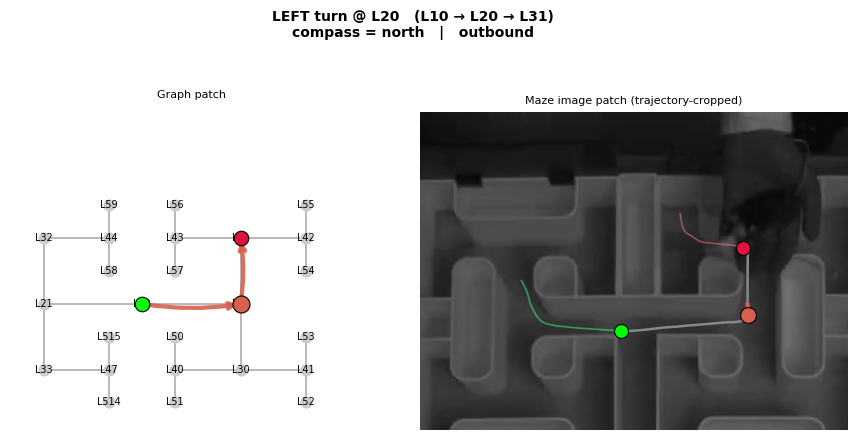

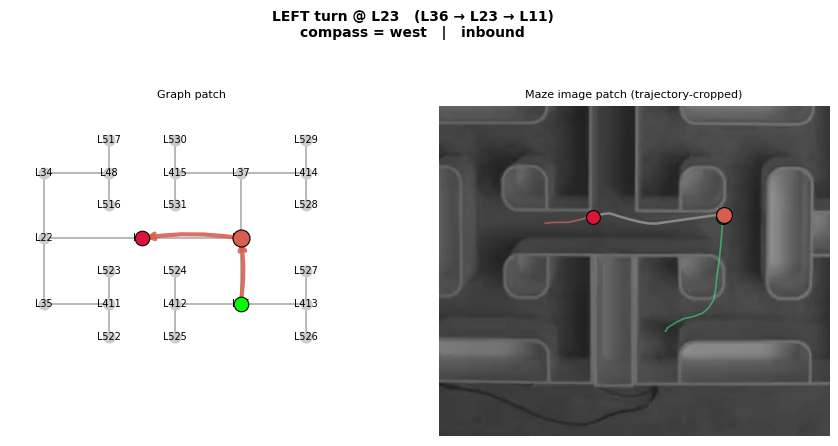

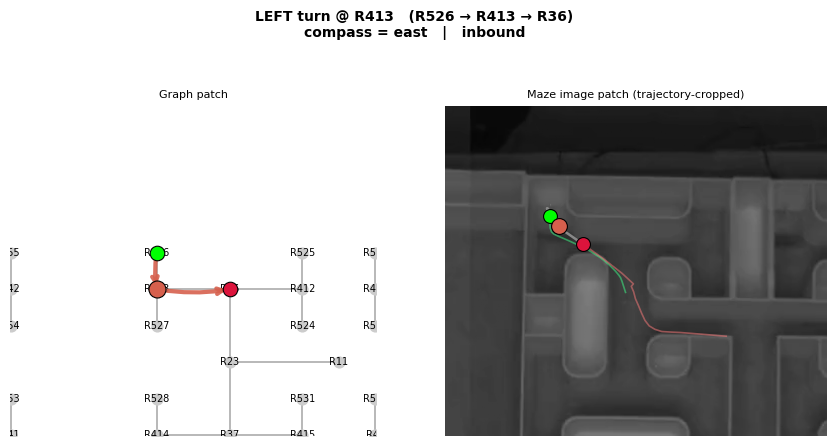

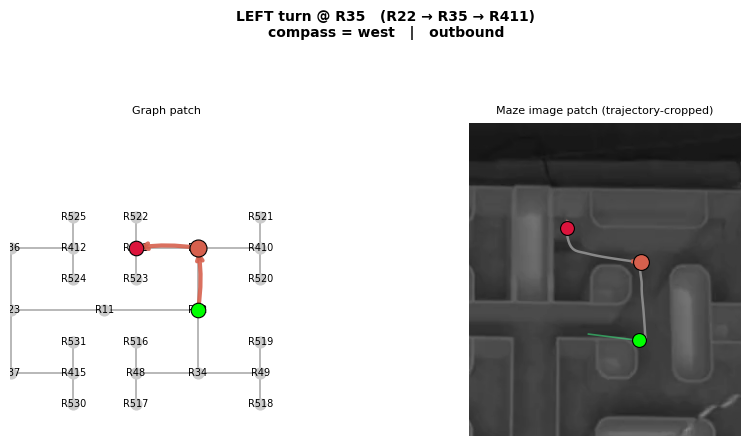

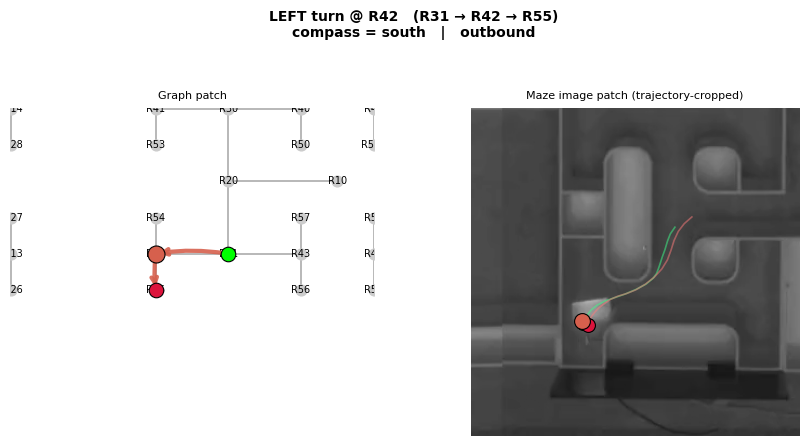

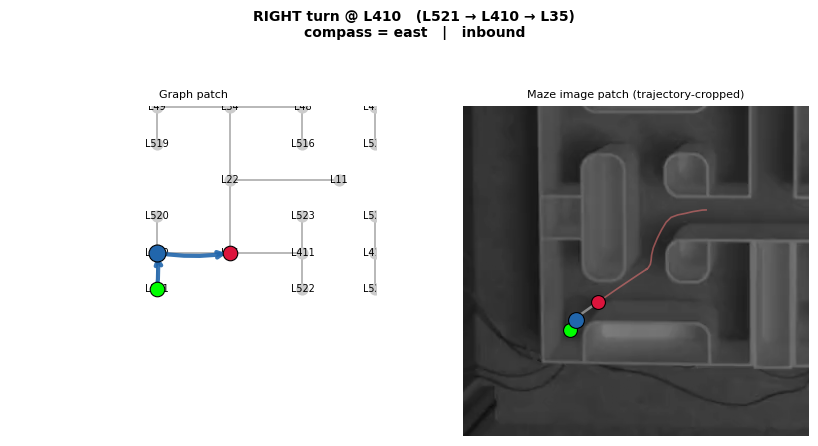

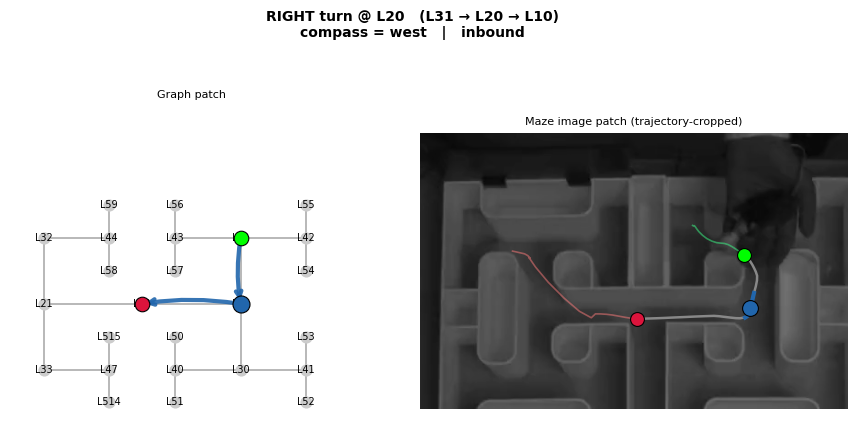

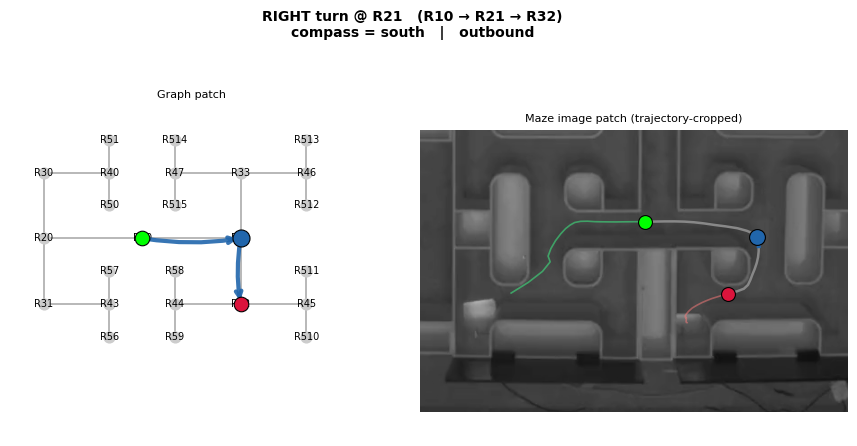

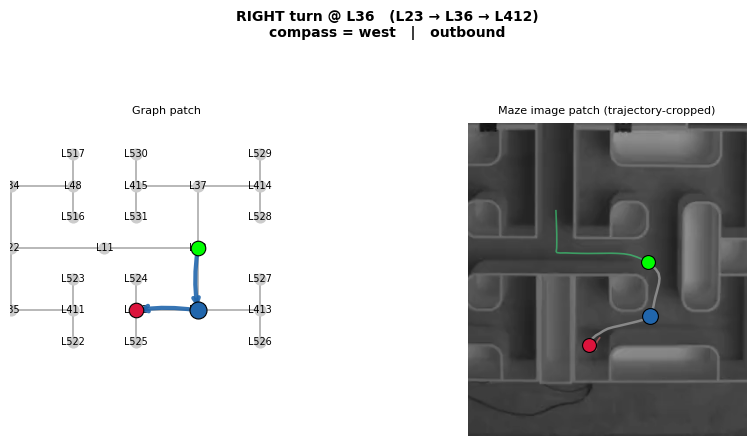

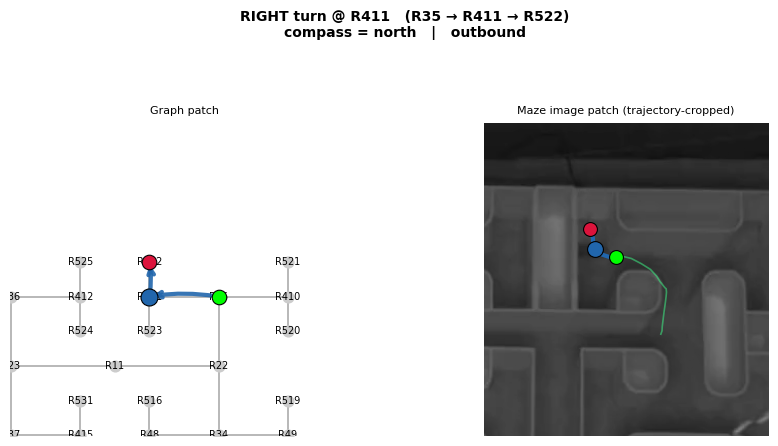

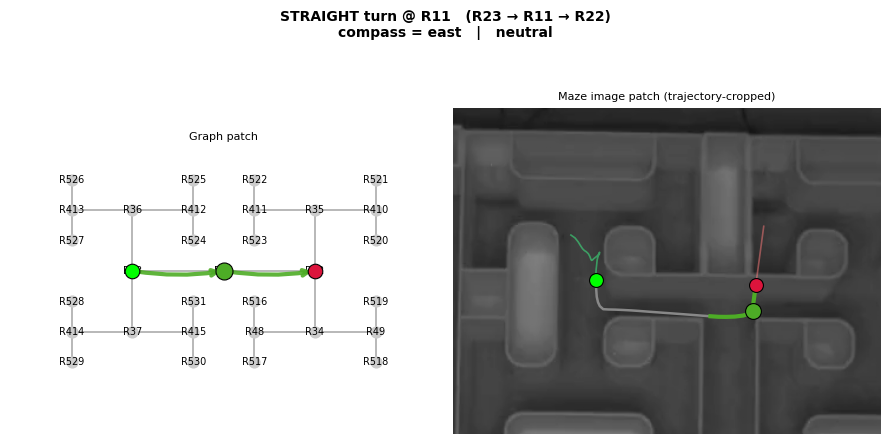

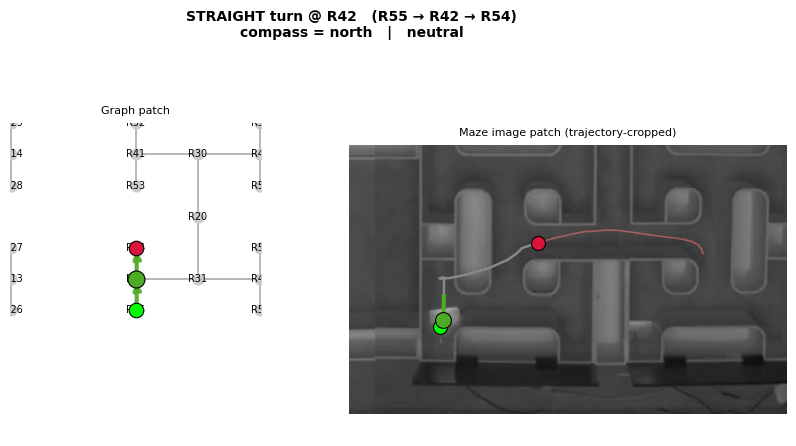

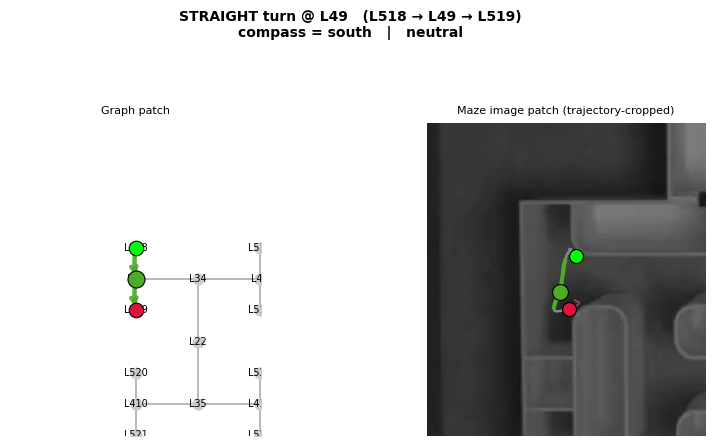

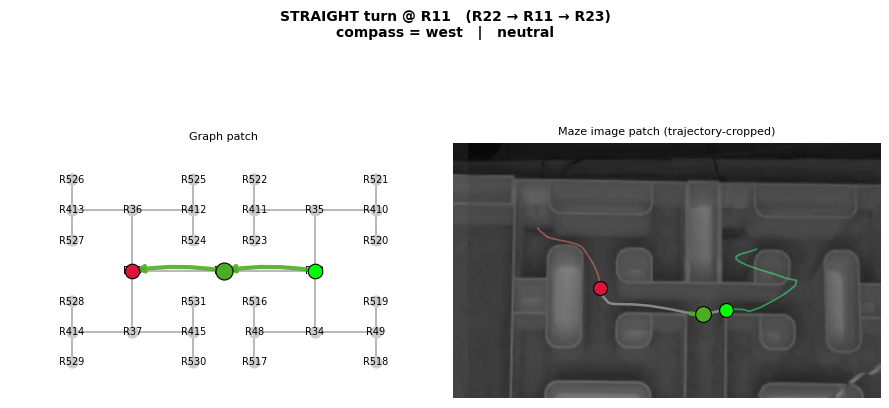

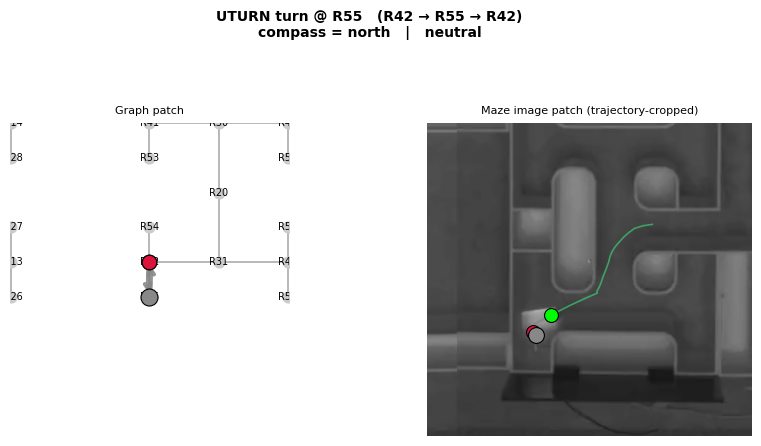

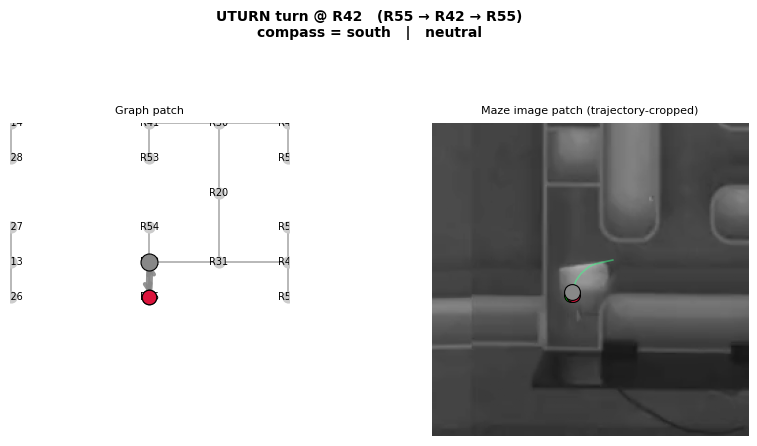

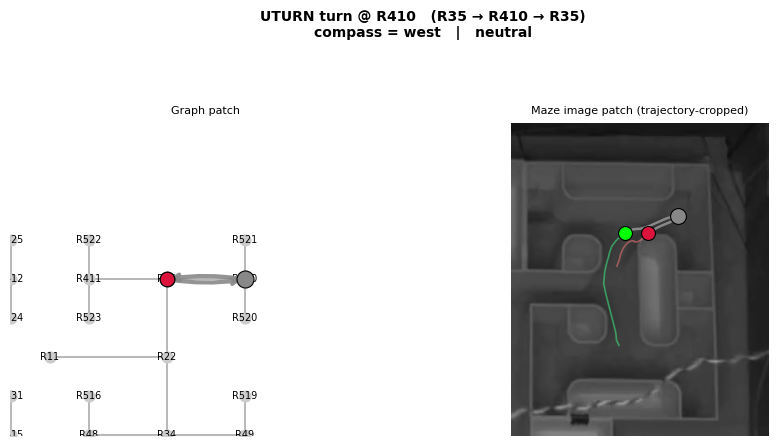

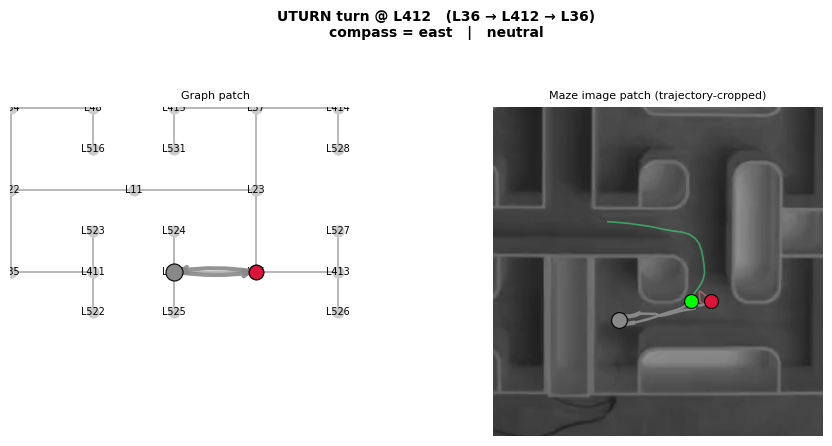

In [112]:
# ── Cell 24: Plot Examples – Graph Patch + Maze Patch Side by Side ───────────
for _, row in example_df.iterrows():
    fig, (ax_g, ax_m) = plt.subplots(1, 2, figsize=(9, 4.5))

    _plot_graph_patch(ax_g, row)

    sub = _summary_by_date.get(row["session_date"], pd.DataFrame())
    if sub.empty or not _plot_maze_patch(ax_m, row, sub):
        ax_m.axis("off")
        ax_m.set_title("(maze image / trajectory unavailable)", fontsize=8)

    fig.suptitle(
        f"{row['turn_type']} turn @ {row['curr_node']}   "
        f"({row['prev_node']} \u2192 {row['curr_node']} \u2192 {row['next_node']})\n"
        f"compass = {row['compass_direction']}   |   {row['inbound_outbound']}",
        fontsize=10, fontweight="bold",
    )
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()


## Inbound / Outbound / Neutral — Definition Schematic

How `inbound_outbound` (from `node_direction.csv`) is actually defined, derived
from graph `G` rather than assumed: each node's **depth** is its shortest-path
distance (in `G`) to its own root (`L0` for L-side nodes, `R0` for R-side
nodes). Comparing `depth(prev_node)` to `depth(next_node)` reproduces the
labels exactly (verified below).


In [115]:
# ── Cell 25: Compute & Verify Node Depth-from-Root ────────────────────────────
#
# inbound_outbound is defined purely from graph distance-to-root in G:
#   depth(node) = shortest-path length (in G) from node to its own-side root
#                 (L0 for L-nodes, R0 for R-nodes)
#   depth(next_node) <  depth(prev_node)  →  INBOUND   (net move toward root)
#   depth(next_node) >  depth(prev_node)  →  OUTBOUND  (net move away from
#                                             root, toward the reward-port leaves)
#   depth(next_node) == depth(prev_node)  →  NEUTRAL   (no net depth change —
#                                             straight-through or U-turn)
#
# Verified below: this rule reproduces node_direction.csv's inbound_outbound
# labels for 100% of matched turns.

import re


def _own_root(node_id):
    return node_id[0] + "0"


_roots = sorted(n for n in G.nodes if re.match(r"^[LR]0$", str(n)))

node_depth = {}
for root in _roots:
    for n, d in nx.single_source_shortest_path_length(G, root).items():
        if _own_root(n) == root:
            node_depth[n] = d

print(f"Roots: {_roots}  |  depth computed for {len(node_depth)}/{len(G.nodes)} nodes")

_verify = turn_df.dropna(subset=["inbound_outbound"]).copy()
_verify["prev_depth"] = _verify["prev_node"].map(node_depth)
_verify["next_depth"] = _verify["next_node"].map(node_depth)
_verify["delta"] = _verify["next_depth"] - _verify["prev_depth"]

_predicted = np.select(
    [_verify["delta"] < 0, _verify["delta"] > 0],
    ["inbound", "outbound"],
    default="neutral",
)
_match_rate = (_predicted == _verify["inbound_outbound"]).mean()
print(f"Rule reproduces node_direction.csv labels for {_match_rate:.1%} of {len(_verify)} turns")
pd.crosstab(_verify["inbound_outbound"], _predicted, rownames=["labeled"], colnames=["rule-predicted"])


Roots: ['L0', 'R0']  |  depth computed for 126/126 nodes
Rule reproduces node_direction.csv labels for 100.0% of 4329 turns


rule-predicted,inbound,neutral,outbound
labeled,,,
inbound,1296,0,0
neutral,0,1484,0
outbound,0,0,1549


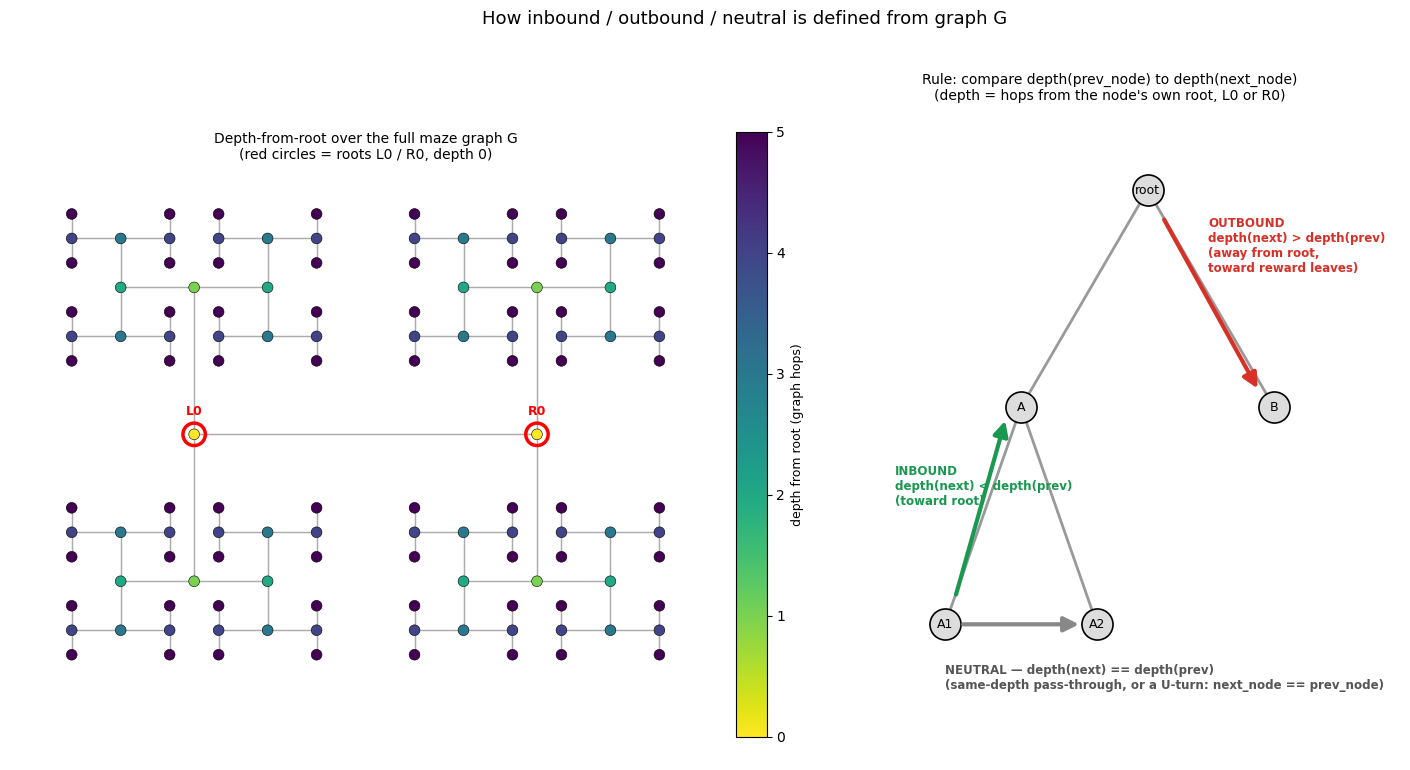

In [116]:
# ── Cell 26: Inbound / Outbound / Neutral Schematic ───────────────────────────
#
# Left panel  — the real graph G, nodes coloured by depth-from-root (the
#               quantity that actually drives the classification).
# Right panel — an idealised mini binary-tree spelling out the three cases
#               with labelled arrows.

fig = plt.figure(figsize=(15, 7.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1])
ax_g = fig.add_subplot(gs[0])
ax_s = fig.add_subplot(gs[1])

# ── Left: real graph, coloured by depth-from-root ─────────────────────────────
depths = [node_depth.get(n, np.nan) for n in G.nodes]
max_depth = int(np.nanmax(depths))

nx.draw_networkx_edges(G, node_positions, ax=ax_g, alpha=0.25,
                       edge_color="#444444", arrows=False, width=1.0)
sc = ax_g.scatter(
    [node_positions[n][0] for n in G.nodes],
    [node_positions[n][1] for n in G.nodes],
    c=depths, cmap="viridis_r", s=60, zorder=5,
    edgecolors="black", linewidths=0.4,
)
for root in _roots:
    rx, ry = node_positions[root]
    ax_g.scatter([rx], [ry], s=260, facecolors="none",
                edgecolors="red", linewidths=2.5, zorder=6)
    ax_g.annotate(root, (rx, ry), textcoords="offset points", xytext=(0, 14),
                 fontsize=9, fontweight="bold", color="red", ha="center")

cbar = fig.colorbar(sc, ax=ax_g, fraction=0.04, pad=0.02)
cbar.set_label("depth from root (graph hops)", fontsize=9)

ax_g.set_aspect("equal")
ax_g.axis("off")
ax_g.set_title("Depth-from-root over the full maze graph G\n"
               "(red circles = roots L0 / R0, depth 0)", fontsize=10)

# ── Right: idealised schematic ────────────────────────────────────────────────
# A small 3-level binary tree: root -> A/B -> A has children A1/A2
pos = {
    "root": (0.5, 1.0),
    "A": (0.25, 0.6), "B": (0.75, 0.6),
    "A1": (0.1, 0.2), "A2": (0.4, 0.2),
}
edges = [("root", "A"), ("root", "B"), ("A", "A1"), ("A", "A2")]

for a, b in edges:
    ax_s.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]],
              color="#999999", lw=2, zorder=1)
for label, (x, y) in pos.items():
    ax_s.scatter([x], [y], s=500, color="#dddddd", edgecolors="black",
                zorder=2, linewidths=1.2)
    ax_s.annotate(label, (x, y), ha="center", va="center", fontsize=9, zorder=3)

arrow_kw = dict(arrowprops=dict(arrowstyle="-|>", lw=3, mutation_scale=22), zorder=4)

# INBOUND: A2 -> root-ward move, e.g. A1 -> A (child to parent, depth decreases)
ax_s.annotate("", xy=(pos["A"][0] - 0.03, pos["A"][1] - 0.02),
             xytext=(pos["A1"][0] + 0.02, pos["A1"][1] + 0.05),
             arrowprops=dict(arrowstyle="-|>", lw=3, mutation_scale=22, color="#1a9850"),
             zorder=4)
ax_s.text(0.0, 0.42, "INBOUND\ndepth(next) < depth(prev)\n(toward root)",
          fontsize=8.5, color="#1a9850", fontweight="bold", ha="left")

# OUTBOUND: root -> B (parent to child, depth increases)
ax_s.annotate("", xy=(pos["B"][0] - 0.03, pos["B"][1] + 0.03),
             xytext=(pos["root"][0] + 0.03, pos["root"][1] - 0.05),
             arrowprops=dict(arrowstyle="-|>", lw=3, mutation_scale=22, color="#d73027"),
             zorder=4)
ax_s.text(0.62, 0.85, "OUTBOUND\ndepth(next) > depth(prev)\n(away from root,\ntoward reward leaves)",
          fontsize=8.5, color="#d73027", fontweight="bold", ha="left")

# NEUTRAL: A1 <-> A2 (siblings, same depth) — straight-through
ax_s.annotate("", xy=(pos["A2"][0] - 0.03, pos["A2"][1]),
             xytext=(pos["A1"][0] + 0.03, pos["A1"][1]),
             arrowprops=dict(arrowstyle="-|>", lw=3, mutation_scale=22, color="#888888"),
             zorder=4)
ax_s.text(0.1, 0.08, "NEUTRAL — depth(next) == depth(prev)\n"
                     "(same-depth pass-through, or a U-turn: next_node == prev_node)",
          fontsize=8.5, color="#555555", fontweight="bold", ha="left")

ax_s.set_xlim(-0.15, 1.0)
ax_s.set_ylim(-0.05, 1.15)
ax_s.axis("off")
ax_s.set_title("Rule: compare depth(prev_node) to depth(next_node)\n"
               "(depth = hops from the node's own root, L0 or R0)", fontsize=10)

fig.suptitle("How inbound / outbound / neutral is defined from graph G", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
